<a href="https://colab.research.google.com/github/ilfpns/PhoSem/blob/main/Phosem_ver4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title 폰트 설정 및 라이브러리 추가
import os
import re
import glob
import shutil
import random

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

import torchvision.transforms.functional as TF

from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

!apt-get -qq install fonts-nanum > /dev/null

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료:", plt.rcParams['font.family'])

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4
폰트 설정 완료: ['NanumGothic']


In [2]:
# @title 파일 불러오기 (사용자 환경에 따라 수정이 필요합니다.)
if not any('Nanum' in f.name for f in fm.fontManager.ttflist):
    os.system("apt-get -qq install fonts-nanum > /dev/null 2>&1")
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

SRC = "/content/drive/MyDrive/every_define/crop"
DATA_DIR = "/content/dataset"
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

if not os.path.isdir(SRC):
    found = glob.glob("/content/drive/MyDrive/**/every_define/crop", recursive=True)
    assert found, "MyDrive 안에서 'every_define/crop' 폴더를 찾지 못함 — 폴더명/위치 확인"
    SRC = found[0]
print("데이터 폴더:", SRC)

marker_path = os.path.join(DATA_DIR, ".src_marker")
need_copy = True
if os.path.exists(DATA_DIR) and os.path.exists(marker_path):
    with open(marker_path) as f:
        prev_src = f.read().strip()
    if prev_src == SRC and len(os.listdir(DATA_DIR)) > 1:
        need_copy = False

if need_copy:
    if os.path.exists(DATA_DIR):
        shutil.rmtree(DATA_DIR)
    os.makedirs(DATA_DIR, exist_ok=True)
    copied = 0
    for root, dirs, files in os.walk(SRC, followlinks=False):
        dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
        rel = os.path.relpath(root, SRC)
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                dst_dir = DATA_DIR if rel == "." else os.path.join(DATA_DIR, rel)
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(os.path.join(root, f), os.path.join(dst_dir, f))
                copied += 1
    with open(marker_path, "w") as f:
        f.write(SRC)
    print(f"복사 완료: {copied}장  (source: {SRC})")
else:
    n = sum(1 for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
            if p.lower().endswith(IMG_EXTS))
    print(f"이미 준비됨({SRC} 기준): {n}장")

Mounted at /content/drive
데이터 폴더: /content/drive/MyDrive/every_define/crop
복사 완료: 4122장  (source: /content/drive/MyDrive/every_define/crop)


In [3]:
# @title 5um 입자 픽셀 처리
ORIG_W = 800
FOV_UM = None
VER2_RESIZE = 256

def defect_px(fov_um, orig_w=ORIG_W, defect_um=5):
    um_per_px = fov_um / orig_w
    orig_px = defect_um / um_per_px
    resized_px = orig_px * VER2_RESIZE / orig_w
    return um_per_px, orig_px, resized_px

if FOV_UM is not None:
    u, o, r = defect_px(FOV_UM)
    print(f"um/pixel               : {u:.3f}")
    print(f"5um 결함 (원본 해상도) : {o:.1f} px")
    print(f"5um 결함 (256 resize)  : {r:.2f} px   <- ver2 방식")
else:
    print("FOV_UM 미확인 — 촬영 배율/시야 확인 후 값을 넣을 것. 후보 시나리오:")
    print(f"{'FOV(um)':>8} {'um/px':>7} {'5um(원본 px)':>12} {'5um(256 resize px)':>18}")
    for fov in [200, 400, 800, 1600, 3200]:
        u, o, r = defect_px(fov)
        print(f"{fov:>8} {u:>7.2f} {o:>12.1f} {r:>18.2f}")

print()
print(f" - 원본 {ORIG_W}x{ORIG_W} -> 256 resize 시 {ORIG_W / VER2_RESIZE:.2f}배 축소")
print(" - 256 resize에서 5um가 1~2px 이하면 resize 방식으로는 검출 불가 -> patch 방식 근거")
print(" - patch 방식에서는 5um 결함의 원본 픽셀 수가 그대로 보존됨")

FOV_UM 미확인 — 촬영 배율/시야 확인 후 값을 넣을 것. 후보 시나리오:
 FOV(um)   um/px   5um(원본 px) 5um(256 resize px)
     200    0.25         20.0               6.40
     400    0.50         10.0               3.20
     800    1.00          5.0               1.60
    1600    2.00          2.5               0.80
    3200    4.00          1.2               0.40

 - 원본 800x800 -> 256 resize 시 3.12배 축소
 - 256 resize에서 5um가 1~2px 이하면 resize 방식으로는 검출 불가 -> patch 방식 근거
 - patch 방식에서는 5um 결함의 원본 픽셀 수가 그대로 보존됨


In [4]:
# @title 학습/검증 데이터 분리
import unicodedata
from collections import Counter

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
DIE_ONLY = True
MIN_PER_CLASS = 2
ORDER = "PSBC"
DROP_LETTERS = "BC"
BG_TAG = "p"
EXCLUDE_TAGS = set("UFXD")
REQUIRE_CLEAN_BG = False
UNKNOWN_CAUSE = "원인미상"
SKIP_NAMES = {"미지정", "미분류", "U", "F", "X", "D"}

USE = "".join(c for c in ORDER if c not in DROP_LETTERS)

def nfc(s):
    return unicodedata.normalize("NFC", s)

def suffix_of(path):
    parts = nfc(os.path.splitext(os.path.basename(path))[0]).split("-")
    return parts[3] if len(parts) >= 4 else ""

def canon(s):
    up = "".join(ch for ch in s if ch.isupper())
    return "".join(c for c in USE if c in up)

def token_of(path):
    suf = suffix_of(path)
    if set(suf) & EXCLUDE_TAGS:
        return None
    rel_dir = nfc(os.path.relpath(os.path.dirname(path), DATA_DIR))
    for part in reversed(rel_dir.split(os.sep)):
        if part in (".", ""):
            continue
        name = part.strip()
        if name in SKIP_NAMES or name.upper() in SKIP_NAMES:
            return None
        if name == "양품" or name.upper() == "G":
            return "양품"
        if set(name.upper()) <= set(ORDER) and canon(name):
            return canon(name)
    parts = nfc(os.path.splitext(os.path.basename(path))[0]).split("-")
    if "양" in parts:
        return "양품"
    if "불" in parts:
        return canon(suf) or UNKNOWN_CAUSE
    return None

all_files = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMG_EXTS)
)

def is_die(path):
    return "die" in re.split(r"[^0-9a-z가-힣]+", os.path.basename(path).lower())

target = [p for p in all_files if (not DIE_ONLY or is_die(p))]
BG_OK = {p: (BG_TAG in suffix_of(p)) for p in target}
dropped_tag = [p for p in target if set(suffix_of(p)) & EXCLUDE_TAGS]

drop_cnt = Counter()
for p in dropped_tag:
    for ch in sorted(set(suffix_of(p)) & EXCLUDE_TAGS):
        drop_cnt[ch] += 1

pool = target if not REQUIRE_CLEAN_BG else [p for p in target if BG_OK[p]]
toks = {p: token_of(p) for p in pool}
labeled = [p for p in pool if toks[p] and toks[p] != UNKNOWN_CAUSE]
unknown_cause = [p for p in pool if toks[p] == UNKNOWN_CAUSE]
unlabeled = [p for p in pool if not toks[p] and p not in dropped_tag]

cnt = Counter(toks[p] for p in labeled)
defect_tokens = sorted((t for t in cnt if t != "양품"), key=lambda t: (len(t), t))
ALL_CLASSES = (["양품"] if cnt.get("양품") else []) + defect_tokens

print(f"사용 지표 {USE}" + (f"  (라벨 제외: {DROP_LETTERS})" if DROP_LETTERS else ""))
print(f"전체 {len(all_files)}장 / 대상 {len(target)}장 (DIE_ONLY={DIE_ONLY})")
print(f"배경 에러(p 없음) {sum(1 for p in target if not BG_OK[p])}장 — "
      f"현재 {'제외' if REQUIRE_CLEAN_BG else '포함'}")
print(f"태그 제외 {len(dropped_tag)}장 "
      f"{ {k: drop_cnt[k] for k in sorted(drop_cnt)} }  (D=X: 다이오드 사진 아님)\n")
print(f"{'클래스':12s} {'장수':>6s}")
for name in ALL_CLASSES:
    n = cnt[name]
    if n < MIN_PER_CLASS:
        note = f"  <- {MIN_PER_CLASS}장 미만: 학습 제외"
    elif n < 10:
        note = "  <- 표본 적음 주의"
    else:
        note = ""
    print(f"{name:12s} {n:>6d}{note}")
print(f"{'제외지표만':12s} {len(unknown_cause):>6d}   <- 볼 근거가 없어 학습 제외")
print(f"{'미지정/불명':12s} {len(unlabeled):>6d}   <- 학습 제외")

CLASS_NAMES = [t for t in ALL_CLASSES if cnt[t] >= MIN_PER_CLASS]
cls_paths = [sorted(p for p in labeled if toks[p] == t) for t in CLASS_NAMES]
labels = {p: (CLASS_NAMES.index(toks[p]) if toks[p] in CLASS_NAMES else None)
          for p in pool}

n_good = cnt.get("양품", 0)
n_bad_all = sum(v for k, v in cnt.items() if k != "양품")
print(f"\n학습 클래스 {len(CLASS_NAMES)}개: {CLASS_NAMES}")
print(f"양품 {n_good}장 / 불량 {n_bad_all}장 "
      f"(불량 비율 {n_bad_all / max(n_good + n_bad_all, 1):.1%})")
print(f"\n{'지표':6s} {'전체':>8s} {'배경정상':>9s}")
for L in USE:
    tot = sum(v for k, v in cnt.items() if k != "양품" and L in k)
    clean = sum(1 for p in labeled
                if toks[p] != "양품" and L in toks[p] and BG_OK[p])
    print(f"{L:6s} {tot:>8d} {clean:>9d}")

assert len(CLASS_NAMES) >= 2, "학습 가능한 클래스가 2개 미만 — 라벨/경로 확인"
for name, p in zip(CLASS_NAMES, cls_paths):
    assert len(p) >= 2, f"'{name}' 클래스가 {len(p)}장 — train/val 분리 불가"

사용 지표 PS  (라벨 제외: BC)
전체 4122장 / 대상 4122장 (DIE_ONLY=True)
배경 에러(p 없음) 1644장 — 현재 포함
태그 제외 413장 {'D': 187, 'F': 193, 'X': 33}  (D=X: 다이오드 사진 아님)

클래스              장수
양품             2130
P               327
S                20
PS               34
제외지표만          1198   <- 볼 근거가 없어 학습 제외
미지정/불명            0   <- 학습 제외

학습 클래스 4개: ['양품', 'P', 'S', 'PS']
양품 2130장 / 불량 381장 (불량 비율 15.2%)

지표           전체      배경정상
P           361       176
S            54         4


In [5]:
# @title 260731 이미지와 학습 데이터 실제 파일 겹침 확인 (해시 비교)
import hashlib

EXT_DIR_CHECK = "/content/drive/MyDrive/260731"

def file_md5(path, chunk=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

train_hashes = {}
for p in all_files:
    train_hashes[file_md5(p)] = p

ext_paths_check = sorted(p for p in glob.glob(os.path.join(EXT_DIR_CHECK, "**", "*"), recursive=True)
                         if p.lower().endswith(IMG_EXTS))

dup = [(p, train_hashes[file_md5(p)]) for p in ext_paths_check if file_md5(p) in train_hashes]
print(f"260731 이미지 {len(ext_paths_check)}장 중 학습 데이터 풀과 완전히 동일한 파일(MD5 일치) {len(dup)}장")
for p, tp in dup[:20]:
    print(f"  {os.path.basename(p):20s} == {os.path.basename(tp)}")

260731 이미지 788장 중 학습 데이터 풀과 완전히 동일한 파일(MD5 일치) 761장
  1.jpg                == 2-die-양-po.jpg
  1001.jpg             == 1005-die-양-po.jpg
  1004.jpg             == 1008-die-양-po.jpg
  1007.jpg             == 1017-die-양-po.jpg
  1015.jpg             == 1015-die-불-F.jpg
  1016.jpg             == 1016-die-불-F.jpg
  1017.jpg             == 1017-die-불-F.jpg
  1019.jpg             == 1035-die-양-po.jpg
  102.jpg              == 102-die-불-pP.jpg
  1027.jpg             == 1027-die-불-pB.jpg
  1028.jpg             == 1028-die-불-pB.jpg
  1031.jpg             == 1031-die-불-F.jpg
  1032.jpg             == 1032-die-불-pB.jpg
  1038.jpg             == 1038-die-불-F.jpg
  1043.jpg             == 1043-die-불-F.jpg
  1050.jpg             == 1050-die-양-po.jpg
  1053.jpg             == 1053-die-양-po.jpg
  1058.jpg             == 1058-die-불-S.jpg
  1061.jpg             == 1061-die-양-po.jpg
  1066.jpg             == 1066-die-불-F.jpg


In [6]:
# @title 260731 · 260721 공식 채점 대상 홀드아웃 분리 (학습 풀에서 제외)
import hashlib, csv

def file_md5(path, chunk=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

def official_hashes(ext_dir, answer_csv):
    answers = read_answer_csv(answer_csv)
    hashes = set()
    for p in glob.glob(os.path.join(ext_dir, "**", "*"), recursive=True):
        if not p.lower().endswith(IMG_EXTS):
            continue
        name = os.path.basename(p)
        row = answers.get(name)
        if not row:
            continue
        target_flag = (row.get("채점대상") or "").strip()
        if target_flag.startswith("예"):
            hashes.add(file_md5(p))
    return hashes

HOLDOUT_260731 = official_hashes("/content/drive/MyDrive/260731", "/content/drive/MyDrive/정답지_260731.csv")
HOLDOUT_260721 = official_hashes("/content/drive/MyDrive/260721", "/content/drive/MyDrive/정답지_260721.csv")
HOLDOUT_HASHES = HOLDOUT_260731 | HOLDOUT_260721

pool_hash = {p: file_md5(p) for p in all_files}
held_out_set = {p for p in all_files if pool_hash[p] in HOLDOUT_HASHES}

before_counts = [len(paths) for paths in cls_paths]
cls_paths = [[p for p in paths if p not in held_out_set] for paths in cls_paths]
after_counts = [len(paths) for paths in cls_paths]

print(f"260731 채점대상 {len(HOLDOUT_260731)}종 + 260721 채점대상 {len(HOLDOUT_260721)}종 (해시 기준)")
print(f"학습 데이터 풀과 겹쳐서 제외한 이미지 {len(held_out_set)}장")
print(f"{'클래스':12s} {'기존':>6s} {'제외 후':>8s}")
for name, b, a in zip(CLASS_NAMES, before_counts, after_counts):
    print(f"{name:12s} {b:>6d} {a:>8d}")
print("\n이 셀 이후 cls_paths가 갱신되었으니, 뒤의 MIL 데이터셋 셀의 train/val/test 분할은 이 갱신된 cls_paths를 씁니다")

260731 채점대상 788종 + 260721 채점대상 347종 (해시 기준)
학습 데이터 풀과 겹쳐서 제외한 이미지 1108장
클래스              기존     제외 후
양품             2130     1828
P               327      168
S                20       13
PS               34       34

이 셀 이후 cls_paths가 갱신되었으니, 뒤의 MIL 데이터셋 셀의 train/val/test 분할은 이 갱신된 cls_paths를 씁니다


In [7]:
# @title 260721 정답지 라벨 학습 반영
import csv

EXT_DIR2 = "/content/drive/MyDrive/260721"
ANSWER_CSV2 = "/content/drive/MyDrive/정답지_260721.csv"
OFFICIAL_BAD_CLASS = "공식불량"

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

answers_721 = read_answer_csv(ANSWER_CSV2)
ext_paths_721 = sorted(p for p in glob.glob(os.path.join(EXT_DIR2, "**", "*"), recursive=True)
                       if p.lower().endswith(IMG_EXTS))

if answers_721:
    sample_row = next(iter(answers_721.values()))
    print(f"정답지 컬럼: {list(sample_row.keys())}")

add_good, add_bad, skipped = [], [], 0
for p in ext_paths_721:
    row = answers_721.get(os.path.basename(p))
    if not row:
        skipped += 1
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if not target_flag.startswith("예"):
        skipped += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "양품" in label:
        add_good.append(p)
    elif "불량" in label:
        add_bad.append(p)
    else:
        skipped += 1

good_idx = CLASS_NAMES.index("양품")
cls_paths[good_idx] = sorted(set(cls_paths[good_idx]) | set(add_good))

if OFFICIAL_BAD_CLASS not in CLASS_NAMES:
    CLASS_NAMES.append(OFFICIAL_BAD_CLASS)
    cls_paths.append([])
bad_idx = CLASS_NAMES.index(OFFICIAL_BAD_CLASS)
cls_paths[bad_idx] = sorted(set(cls_paths[bad_idx]) | set(add_bad))

print(f"260721 채점대상 이미지 {len(ext_paths_721)}장 중 반영 {len(add_good) + len(add_bad)}장 "
      f"(양품 {len(add_good)} / {OFFICIAL_BAD_CLASS} {len(add_bad)}) · 제외 {skipped}장")
print(f"학습 클래스 {len(CLASS_NAMES)}개: {CLASS_NAMES}")
for name, paths in zip(CLASS_NAMES, cls_paths):
    print(f"  {name:12s} {len(paths):>6d}")
print("\n주의: 260721은 이제 학습에 쓰였으니, 이후 '정답지 채점 (260721 배치)' 결과는 "
      "held-out 시험지가 아니라 참고용입니다. 260731만 순수 held-out으로 유지됩니다.")

정답지 컬럼: ['파일', '라벨', '채점대상', '라벨출처', '비고']
260721 채점대상 이미지 347장 중 반영 347장 (양품 241 / 공식불량 106) · 제외 0장
학습 클래스 5개: ['양품', 'P', 'S', 'PS', '공식불량']
  양품             2069
  P               168
  S                13
  PS               34
  공식불량            106

주의: 260721은 이제 학습에 쓰였으니, 이후 '정답지 채점 (260721 배치)' 결과는 held-out 시험지가 아니라 참고용입니다. 260731만 순수 held-out으로 유지됩니다.


In [8]:
# @title 자체 라벨 vs 정답지 라벨 태그별 일치도 분석
from collections import Counter, defaultdict

def official_rows(ext_dir, answer_csv):
    answers = read_answer_csv(answer_csv)
    out = {}
    for p in glob.glob(os.path.join(ext_dir, "**", "*"), recursive=True):
        if not p.lower().endswith(IMG_EXTS):
            continue
        name = os.path.basename(p)
        row = answers.get(name)
        if not row:
            continue
        if not (row.get("채점대상") or "").strip().startswith("예"):
            continue
        out[p] = (row.get("라벨") or "").strip()
    return out

hash_to_pool = {h: p for p, h in pool_hash.items()}

pairs = {}
for ext_dir, answer_csv in [("/content/drive/MyDrive/260731", "/content/drive/MyDrive/정답지_260731.csv"),
                            ("/content/drive/MyDrive/260721", "/content/drive/MyDrive/정답지_260721.csv")]:
    for p, official in official_rows(ext_dir, answer_csv).items():
        h = file_md5(p)
        tp = hash_to_pool.get(h)
        if tp is None:
            continue
        pairs[tp] = official

table = defaultdict(Counter)
for tp, official in pairs.items():
    raw = toks.get(tp)
    self_tag = raw if raw and raw != UNKNOWN_CAUSE else "미지정"
    table[self_tag]["불량" if "불량" in official else "양품"] += 1

print(f"정답지 라벨 확인 가능한 겹침 이미지 {len(pairs)}장 (260731+260721 채점대상=예 기준)\n")
print(f"{'자체 태그':10s} {'전체':>6s} {'정답지=불량':>10s} {'정답지=양품':>10s} {'기대와 일치율':>12s}")
order = ["양품"] + sorted((t for t in table if t not in ("양품", "미지정")), key=lambda t: (len(t), t))
if "미지정" in table:
    order.append("미지정")
agree_total = n_total = 0
for tag in order:
    c = table[tag]
    n = c["불량"] + c["양품"]
    n_total += n
    agree = c["양품"] if tag == "양품" else c["불량"]
    agree_total += agree
    rate = agree / n if n else 0.0
    print(f"{tag:10s} {n:>6d} {c['불량']:>10d} {c['양품']:>10d} {rate:>11.1%}")
print(f"\n전체 일치율 {agree_total}/{n_total} ({agree_total / max(n_total, 1):.1%})")

miss = table["양품"]["불량"]
over = sum(c["양품"] for t, c in table.items() if t != "양품")
print(f"자체=양품인데 정답지=불량 (놓친 불량) {miss}장")
print(f"자체=불량인데 정답지=양품 (과다 판정) {over}장")

print(f"\n지표별 (해당 지표가 포함된 자체 태그 기준) 정답지 불량 일치율")
print(f"{'지표':6s} {'전체':>6s} {'정답지=불량':>10s} {'정답지=양품':>10s} {'일치율':>8s}")
for L in USE:
    n = b = g = 0
    for tp, official in pairs.items():
        raw = toks.get(tp)
        tag = raw if raw and raw != UNKNOWN_CAUSE else None
        if tag and tag != "양품" and L in tag:
            n += 1
            if "불량" in official:
                b += 1
            else:
                g += 1
    if n:
        print(f"{L:6s} {n:>6d} {b:>10d} {g:>10d} {b / n:>7.1%}")

정답지 라벨 확인 가능한 겹침 이미지 1108장 (260731+260721 채점대상=예 기준)

자체 태그          전체     정답지=불량     정답지=양품      기대와 일치율
양품            302         21        281       93.0%
P             159         57        102       35.8%
S               7          1          6       14.3%
미지정           640        142        498       22.2%

전체 일치율 481/1108 (43.4%)
자체=양품인데 정답지=불량 (놓친 불량) 21장
자체=불량인데 정답지=양품 (과다 판정) 606장

지표별 (해당 지표가 포함된 자체 태그 기준) 정답지 불량 일치율
지표         전체     정답지=불량     정답지=양품      일치율
P         159         57        102   35.8%
S           7          1          6   14.3%


In [9]:
# @title 제외 소자 목록 내보내기
import csv

EXCL_OUT = "phosem_v3_excluded.csv"

def excl_reason(p):
    tags = set(suffix_of(p)) & EXCLUDE_TAGS
    if tags:
        return "태그 제외 (" + "/".join(sorted(tags)) + ")"
    if toks.get(p) == UNKNOWN_CAUSE:
        return "원인미상 (볼 근거 없음)"
    return "라벨 미확정"

non_die = [p for p in all_files if p not in target]
excl_rows = ([(p, "die 파일 아님") for p in non_die]
             + [(p, excl_reason(p)) for p in dropped_tag]
             + [(p, excl_reason(p)) for p in unknown_cause]
             + [(p, excl_reason(p)) for p in unlabeled])

with open(EXCL_OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "제외사유"])
    for p, reason in excl_rows:
        wr.writerow([os.path.basename(p), reason])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(EXCL_OUT, "/content/drive/MyDrive/" + EXCL_OUT)

print(f"저장 완료: {EXCL_OUT}  ({len(excl_rows)}건)")
print(f"  die 파일 아님 {len(non_die)} | 태그 제외 {len(dropped_tag)} | "
      f"원인미상 {len(unknown_cause)} | 라벨 미확정 {len(unlabeled)}")

저장 완료: phosem_v3_excluded.csv  (1611건)
  die 파일 아님 0 | 태그 제외 413 | 원인미상 1198 | 라벨 미확정 0


  1-die-불-P.jpg                          (800, 800)
  1-die-양-O.jpg                          (800, 800)
  1-die-양-po.jpg                         (800, 800)
  1.jpg                                    (800, 800)
  1001.jpg                                 (800, 800)
  1004.jpg                                 (800, 800)

ROI (384, 236, 564, 416)  크기 180 x 180
기준 배치 메사 중심 (522, 277) r 116 — 새 배치가 여기서 크게 벗어나면 ROI 재산정 필요


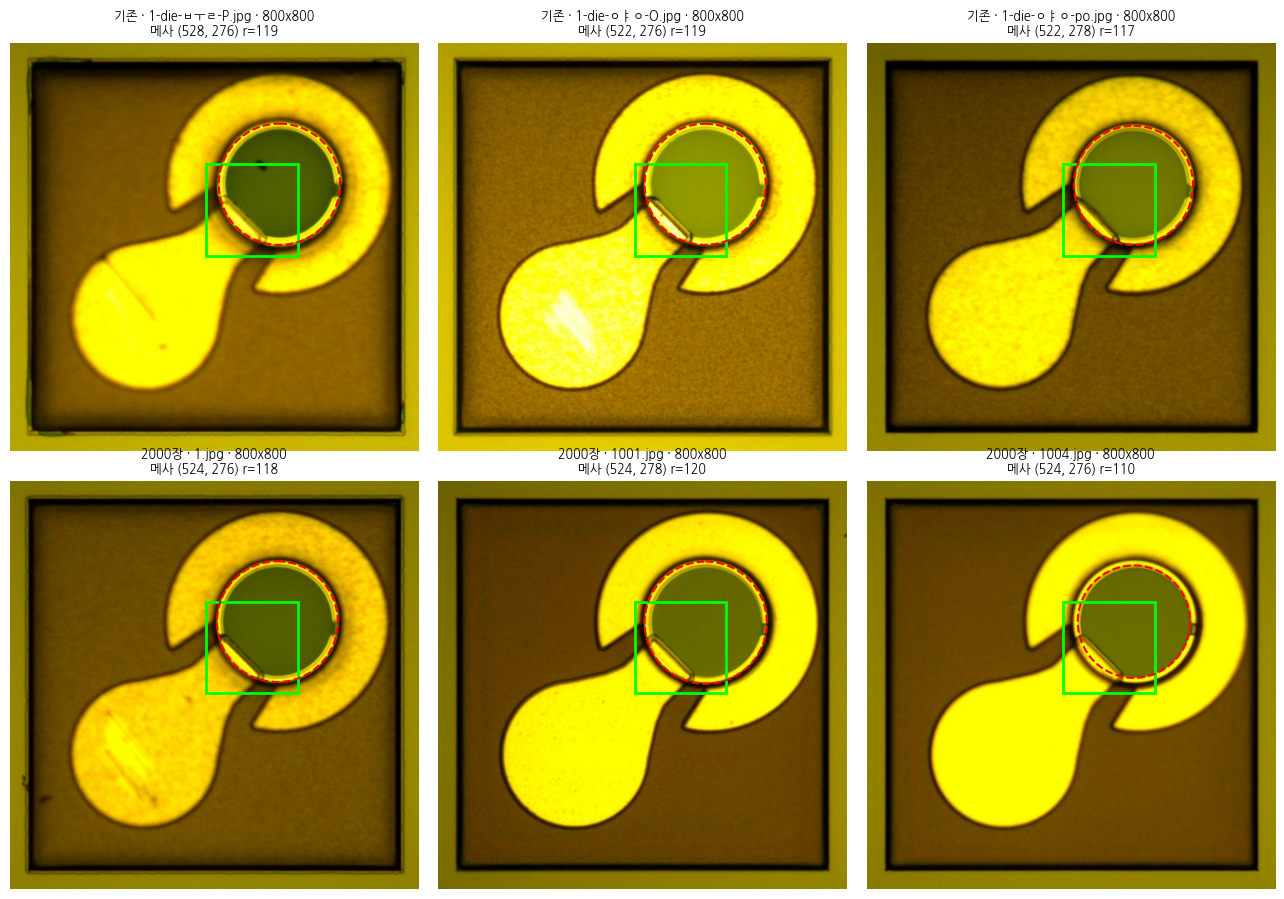

In [10]:
# @title ROI 정렬 확인
import matplotlib.patches as mpatches
import numpy as np
import cv2

ROI_BOX = (384, 236, 564, 416)
EXT_DIR = "/content/drive/MyDrive/260731"
ANSWER_CSV = "/content/drive/MyDrive/정답지_260731.csv"

def find_mesa(path):
    g = cv2.medianBlur(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY), 5)
    c = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, dp=1, minDist=120,
                         param1=120, param2=40, minRadius=95, maxRadius=155)
    if c is None:
        return None
    Y, X = np.ogrid[:g.shape[0], :g.shape[1]]
    best = None
    for x, y, r in c[0][:8]:
        m = (X - x) ** 2 + (Y - y) ** 2 < (0.7 * r) ** 2
        v = g[m].mean()
        if best is None or v < best[0]:
            best = (v, x, y, r)
    return best[1], best[2], best[3]

def show_roi(paths, tag, axrow):
    x0, y0, x1, y1 = ROI_BOX
    for ax, p in zip(axrow, paths):
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, lw=2, color="lime"))
        m = find_mesa(p)
        sub = ""
        if m:
            cx, cy, r = m
            ax.add_patch(mpatches.Circle((cx, cy), r, fill=False, lw=1.5,
                                         ls="--", color="red"))
            sub = f"\n메사 ({cx:.0f}, {cy:.0f}) r={r:.0f}"
        ax.set_title(f"{tag} · {os.path.basename(p)} · {img.size[0]}x{img.size[1]}{sub}",
                     fontsize=9)
        ax.axis("off")
    for ax in axrow[len(paths):]:
        ax.axis("off")

def pick(root, n=3):
    if not os.path.isdir(root):
        print(f"폴더 없음: {root}")
        return []
    return sorted(p for p in glob.glob(os.path.join(root, "**", "*"), recursive=True)
                  if p.lower().endswith(IMG_EXTS))[:n]

inner, outer = pick(DATA_DIR), pick(EXT_DIR)
for p in inner + outer:
    print(f"  {os.path.basename(p):40s} {Image.open(p).size}")

print(f"\nROI {ROI_BOX}  크기 {ROI_BOX[2]-ROI_BOX[0]} x {ROI_BOX[3]-ROI_BOX[1]}")
print("기준 배치 메사 중심 (522, 277) r 116 — 새 배치가 여기서 크게 벗어나면 ROI 재산정 필요")

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
show_roi(inner, "기존", axes[0])
show_roi(outer, "2000장", axes[1])
plt.tight_layout()
plt.show()

학습 풀       표본 300장
260731     표본 300장
260721     표본 300장
[학습 풀]  밝기 중앙값 99.1 (5~95% 78.9~113.0) | 대비 중앙값 58.1 (5~95% 47.9~65.1)
[260731]  밝기 중앙값 102.5 (5~95% 88.1~111.1) | 대비 중앙값 59.8 (5~95% 53.5~66.5)
[260721]  밝기 중앙값 95.6 (5~95% 77.1~111.7) | 대비 중앙값 55.9 (5~95% 48.5~63.7)

학습 풀 vs 260731  밝기  KS=0.257  p=0.0000  -> 분포 다름
학습 풀 vs 260731  대비  KS=0.197  p=0.0000  -> 분포 다름
학습 풀 vs 260721  밝기  KS=0.147  p=0.0031  -> 분포 다름
학습 풀 vs 260721  대비  KS=0.167  p=0.0005  -> 분포 다름


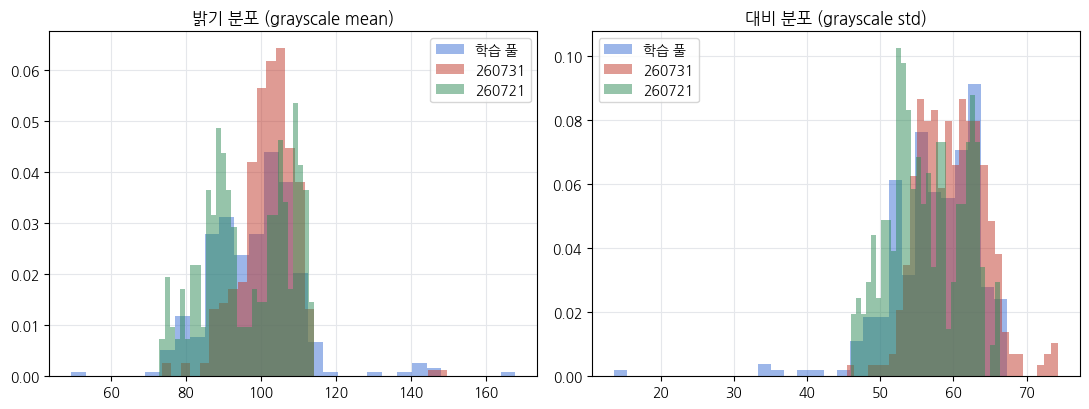


p < 0.01 로 '분포 다름'이 나오면, 학습 시 밝기/대비 augmentation 범위(JIT_BRIGHT, JIT_CONTRAST)를 해당 배치 분포를 덮도록 넓히는 걸 고려하세요 (지금은 ±0.25). '유사'면 도메인 차이는 원인이 아닙니다.


In [11]:
# @title 도메인 차이 진단 (밝기·대비 분포 비교)
import numpy as np
import cv2
from scipy import stats

DOMAIN_SAMPLE_N = 300
DOMAIN_SEED = 0

def sample_paths(paths, n, seed):
    rng = random.Random(seed)
    return rng.sample(paths, min(n, len(paths))) if paths else []

def image_stats(path):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        return None
    return float(g.mean()), float(g.std())

def collect_stats(paths, tag):
    vals = []
    for p in paths:
        s = image_stats(p)
        if s is not None:
            vals.append(s)
    arr = np.array(vals)
    print(f"{tag:10s} 표본 {len(arr)}장")
    return arr

official_files1 = [p for p in glob.glob(os.path.join(EXT_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS)]
official_files2 = [p for p in glob.glob(os.path.join(EXT_DIR2, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS)]

pool_train = sample_paths(target, DOMAIN_SAMPLE_N, DOMAIN_SEED)
pool_731 = sample_paths(official_files1, DOMAIN_SAMPLE_N, DOMAIN_SEED)
pool_721 = sample_paths(official_files2, DOMAIN_SAMPLE_N, DOMAIN_SEED)

A_train = collect_stats(pool_train, "학습 풀")
A_731 = collect_stats(pool_731, "260731")
A_721 = collect_stats(pool_721, "260721")

def report(name, arr):
    if len(arr) == 0:
        print(f"{name}: 자료 없음")
        return
    b, c = arr[:, 0], arr[:, 1]
    print(f"[{name}]  밝기 중앙값 {np.median(b):.1f} (5~95% {np.percentile(b,5):.1f}~{np.percentile(b,95):.1f})"
          f" | 대비 중앙값 {np.median(c):.1f} (5~95% {np.percentile(c,5):.1f}~{np.percentile(c,95):.1f})")

report("학습 풀", A_train)
report("260731", A_731)
report("260721", A_721)

def ks_report(name_a, a, name_b, b, col, col_name):
    if len(a) == 0 or len(b) == 0:
        return
    stat, p = stats.ks_2samp(a[:, col], b[:, col])
    flag = "분포 다름" if p < 0.01 else "유사"
    print(f"{name_a} vs {name_b}  {col_name}  KS={stat:.3f}  p={p:.4f}  -> {flag}")

print()
ks_report("학습 풀", A_train, "260731", A_731, 0, "밝기")
ks_report("학습 풀", A_train, "260731", A_731, 1, "대비")
ks_report("학습 풀", A_train, "260721", A_721, 0, "밝기")
ks_report("학습 풀", A_train, "260721", A_721, 1, "대비")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for arr, tag, color in [(A_train, "학습 풀", "#3b6fd4"), (A_731, "260731", "#c0392b"),
                        (A_721, "260721", "#2e8b57")]:
    if len(arr):
        axes[0].hist(arr[:, 0], bins=30, alpha=0.5, label=tag, color=color, density=True)
        axes[1].hist(arr[:, 1], bins=30, alpha=0.5, label=tag, color=color, density=True)
axes[0].set_title("밝기 분포 (grayscale mean)")
axes[1].set_title("대비 분포 (grayscale std)")
for ax in axes:
    ax.legend()
    ax.grid(color="#e5e7eb")
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\np < 0.01 로 '분포 다름'이 나오면, 학습 시 밝기/대비 augmentation 범위(JIT_BRIGHT, JIT_CONTRAST)를"
      " 해당 배치 분포를 덮도록 넓히는 걸 고려하세요 (지금은 ±0.25). '유사'면 도메인 차이는 원인이 아닙니다.")

In [12]:
# @title 메사 위치 검출
import json
import numpy as np
import cv2

MESA_JSON = "/content/drive/MyDrive/mesa_centers.json"
MESA_FALLBACK = (522.0, 277.0, 116.0)
OFFICIAL_DIRS = ["/content/drive/MyDrive/260731", "/content/drive/MyDrive/260721"]

def detect_mesa(path):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        return None
    c = cv2.HoughCircles(cv2.medianBlur(g, 5), cv2.HOUGH_GRADIENT, dp=1,
                         minDist=120, param1=120, param2=40,
                         minRadius=95, maxRadius=155)
    if c is None:
        return None
    Y, X = np.ogrid[:g.shape[0], :g.shape[1]]
    best = None
    for x, y, r in c[0][:8]:
        m = (X - x) ** 2 + (Y - y) ** 2 < (0.7 * r) ** 2
        v = float(g[m].mean())
        if best is None or v < best[0]:
            best = (v, float(x), float(y), float(r))
    return best[1], best[2], best[3]

official_files = []
for d in OFFICIAL_DIRS:
    if os.path.isdir(d):
        official_files += [p for p in glob.glob(os.path.join(d, "**", "*"), recursive=True)
                           if p.lower().endswith(IMG_EXTS)]

MESA = {}
if os.path.exists(MESA_JSON):
    MESA = {k: tuple(v) for k, v in json.load(open(MESA_JSON)).items()}
    print(f"캐시 로드 {len(MESA)}장  ({MESA_JSON})")

todo = [p for p in target + official_files if os.path.basename(p) not in MESA]
if todo:
    print(f"검출 시작 {len(todo)}장 (학습 풀 {len(target)} + 정답지 배치 {len(official_files)})")
    fail = 0
    for i, p in enumerate(todo):
        v = detect_mesa(p)
        if v is None:
            fail += 1
            v = MESA_FALLBACK
        MESA[os.path.basename(p)] = v
        if (i + 1) % 300 == 0:
            print(f"  {i + 1}/{len(todo)}")
    json.dump({k: list(v) for k, v in MESA.items()}, open(MESA_JSON, "w"))
    print(f"검출 완료 | 실패 {fail}장은 기본값 사용 | 저장 {MESA_JSON}")

def mesa_of(path):
    return MESA.get(os.path.basename(path), MESA_FALLBACK)

def report_spread(paths, label):
    A = np.array([MESA[os.path.basename(p)] for p in paths if os.path.basename(p) in MESA])
    if len(A) == 0:
        print(f"{label}: 자료 없음")
        return
    print(f"\n[{label}]  {'항목':6s} {'중앙값':>8s} {'5%':>8s} {'95%':>8s} {'폭':>7s}")
    for i, nm in enumerate(["중심 x", "중심 y", "반지름"]):
        q = np.percentile(A[:, i], [5, 50, 95])
        print(f"{nm:6s} {q[1]:>8.1f} {q[0]:>8.1f} {q[2]:>8.1f} {q[2]-q[0]:>7.1f}")
    spread = max(np.percentile(A[:, 0], 95) - np.percentile(A[:, 0], 5),
                 np.percentile(A[:, 1], 95) - np.percentile(A[:, 1], 5))
    print("정렬 " + ("양호 — 고정 ROI도 안전" if spread < 20
                    else f"주의 — 중심이 {spread:.0f}px 흔들립니다. 배치가 섞였는지 확인하세요"))
    fb = sum(1 for p in paths if MESA.get(os.path.basename(p)) == MESA_FALLBACK)
    print(f"기본값(검출 실패) 사용 {fb}/{len(paths)}장")

report_spread(target, "학습 풀")
report_spread(official_files, "정답지 배치 (260731+260721)")

캐시 로드 5498장  (/content/drive/MyDrive/mesa_centers.json)

[학습 풀]  항목          중앙값       5%      95%       폭
중심 x      522.5    520.5    524.5     4.0
중심 y      277.5    275.5    279.5     4.0
반지름       116.6    105.1    128.5    23.4
정렬 양호 — 고정 ROI도 안전
기본값(검출 실패) 사용 23/4122장

[정답지 배치 (260731+260721)]  항목          중앙값       5%      95%       폭
중심 x      522.5    519.5    524.5     5.0
중심 y      277.5    275.5    279.5     4.0
반지름       116.0    104.8    128.6    23.8
정렬 양호 — 고정 ROI도 안전
기본값(검출 실패) 사용 0/1135장


In [13]:
# @title [개선 A] 정답지 라벨로 학습 데이터 구성 (260714 · 260721)
import csv
import zlib
import json
import hashlib
import datetime
import unicodedata
from collections import Counter

LABEL_MODE = "자동"
ANSWER_CSV_714 = "/content/drive/MyDrive/정답지_260714.csv"
DIR_714 = None
LOCAL_714 = "/content/official_260714"
MIN_714 = 100
FIX_MATCH_RATE = 0.8
MYDRIVE = "/content/drive/MyDrive"
BACKUP_NAMES = ["best_mil.pth", "ens0.pth", "ens1.pth", "ens2.pth", "phosem_v3.pt",
                "mil_fp.txt", "ens0_fp.txt", "ens1_fp.txt", "ens2_fp.txt"]
OFFICIAL_BAD = globals().get("OFFICIAL_BAD_CLASS", "공식불량")

def nfc_s(s):
    return unicodedata.normalize("NFC", str(s or "")).strip()

def resolve_nfc(path):
    if os.path.exists(path):
        return path
    parent, name = os.path.split(path)
    if not os.path.isdir(parent):
        return path
    for entry in os.listdir(parent):
        if nfc_s(entry) == nfc_s(name):
            return os.path.join(parent, entry)
    return path

def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

def crc_of(path, chunk=1 << 20):
    c = 0
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            c = zlib.crc32(b, c)
    return c & 0xFFFFFFFF

def crc_keys(text):
    t = nfc_s(text).replace("0x", "").replace("0X", "")
    keys = set()
    if t and all(ch in "0123456789abcdefABCDEF" for ch in t):
        keys.add(int(t, 16))
    if t.isdigit():
        keys.add(int(t))
    return keys

def label_of_text(text):
    t = nfc_s(text)
    if "불량" in t:
        return 1
    if "양품" in t:
        return 0
    return None

def find_answer_714():
    cands = [resolve_nfc(ANSWER_CSV_714)]
    for pat in ("*260714*.csv", "*/*260714*.csv"):
        cands += sorted(glob.glob(os.path.join(MYDRIVE, pat)))
    for c in cands:
        if os.path.isfile(c) and "정답" in nfc_s(os.path.basename(c)):
            return c
    return None

def find_dirs_714():
    if DIR_714:
        d = resolve_nfc(DIR_714)
        return [d] if os.path.isdir(d) else []
    found = []
    for root, dirs, _ in os.walk(MYDRIVE):
        depth = root[len(MYDRIVE):].count(os.sep)
        for d in dirs:
            if "260714" in nfc_s(d):
                found.append(os.path.join(root, d))
        if depth >= 1:
            dirs[:] = []
    found = sorted(set(found))
    return [d for d in found if not any(d != o and d.startswith(o + os.sep) for o in found)]

def read_answer_714(path):
    rows = []
    with open(path, encoding="utf-8-sig") as f:
        for r in csv.DictReader(f):
            r = {nfc_s(k): nfc_s(v) for k, v in r.items() if k is not None and not isinstance(v, list)}
            key = r.get("고유키", "")
            folder = r.get("폴더", "")
            fname = r.get("파일", "") or r.get("파일명", "")
            if key and "/" in key:
                kf, kn = key.rsplit("/", 1)
                folder = folder or kf.split("/")[-1]
                fname = fname or kn
            crc_text = next((v for k, v in r.items() if "CRC" in k.upper() or "검증" in k), "")
            rows.append({"folder": nfc_s(folder), "file": nfc_s(os.path.basename(fname)),
                         "y": label_of_text(r.get("라벨", "")), "crc": crc_keys(crc_text)})
    return rows

def backup_weights():
    anchor = next((os.path.join(MYDRIVE, n) for n in ("ens0.pth", "best_mil.pth")
                   if os.path.exists(os.path.join(MYDRIVE, n))), None)
    if anchor is None:
        print("백업할 기존 가중치 없음")
        return None
    sig = md5_of(anchor)
    for old in glob.glob(os.path.join(MYDRIVE, "backup_v3_weights_*", "sig.txt")):
        if open(old, encoding="utf-8").read().strip() == sig:
            print(f"기존 가중치는 이미 백업되어 있음 → {os.path.dirname(old)}")
            return os.path.dirname(old)
    dst = os.path.join(MYDRIVE, "backup_v3_weights_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
    os.makedirs(dst, exist_ok=True)
    n = 0
    for nm in BACKUP_NAMES:
        s = os.path.join(MYDRIVE, nm)
        if os.path.exists(s):
            shutil.copy2(s, os.path.join(dst, nm))
            n += 1
    open(os.path.join(dst, "sig.txt"), "w", encoding="utf-8").write(sig)
    print(f"기존 가중치 {n}개 백업 → {dst}")
    return dst

before_counts = {name: len(ps) for name, ps in zip(CLASS_NAMES, cls_paths)}
add_good_721 = list(globals().get("add_good", []))
add_bad_721 = list(globals().get("add_bad", []))
hold_731 = globals().get("HOLDOUT_260731", set())
md5_to_pool = {}
for _p, _h in pool_hash.items():
    md5_to_pool.setdefault(_h, []).append(_p)

csv_714 = find_answer_714()
dirs_714 = find_dirs_714()
rows_714 = read_answer_714(csv_714) if csv_714 else []
print(f"정답지 260714 CSV : {csv_714 or '없음'}" + (f"  ({len(rows_714)}행)" if csv_714 else ""))
print(f"260714 이미지 폴더 : {dirs_714 if dirs_714 else '없음'}")

by_key, by_crc = {}, {}
for r in rows_714:
    if r["y"] is None:
        continue
    by_key.setdefault((r["folder"], r["file"]), set()).add(r["y"])
    for c in r["crc"]:
        by_crc.setdefault(c, set()).add(r["y"])
use_crc = bool(by_crc)

files_714 = []
for d in dirs_714:
    files_714 += [(d, p) for p in sorted(glob.glob(os.path.join(d, "**", "*"), recursive=True))
                  if p.lower().endswith(IMG_EXTS)]

recs, dropped = [], Counter()
seen_md5 = {}
for d, p in files_714:
    parts = [nfc_s(x) for x in os.path.relpath(p, d).split(os.sep)]
    parent = parts[-2] if len(parts) >= 2 else nfc_s(os.path.basename(d))
    name = parts[-1]
    y, how = None, None
    if use_crc:
        ys = by_crc.get(crc_of(p))
        if ys and len(ys) == 1:
            y, how = next(iter(ys)), "CRC"
    if y is None:
        ys = by_key.get((parent, name))
        if ys and len(ys) == 1:
            y, how = next(iter(ys)), "고유키"
    if y is None:
        for part in reversed([nfc_s(os.path.basename(d))] + parts[:-1]):
            yy = label_of_text(part)
            if yy is not None:
                y, how = yy, "폴더명"
                break
    if y is None:
        dropped["라벨 없음"] += 1
        continue
    h = md5_of(p)
    if h in hold_731:
        dropped["260731 시험지와 동일 파일"] += 1
        continue
    if h in seen_md5:
        if recs[seen_md5[h]]["y"] != y:
            recs[seen_md5[h]]["y"] = None
            dropped["같은 파일에 서로 다른 라벨"] += 1
        else:
            dropped["중복 파일"] += 1
        continue
    seen_md5[h] = len(recs)
    recs.append({"path": p, "y": y, "how": how, "md5": h, "pool": md5_to_pool.get(h, [])})
recs = [r for r in recs if r["y"] is not None]
how_cnt = Counter(r["how"] for r in recs)

n_lab = len(recs)
n_match = sum(1 for r in recs if r["pool"])
rate = n_match / max(n_lab, 1)
print(f"\n260714 라벨 확보 {n_lab}장 (불량 {sum(r['y'] for r in recs)} / 양품 {n_lab - sum(r['y'] for r in recs)})"
      f" · 라벨 근거 {dict(how_cnt)}")
if dropped:
    print(f"제외 {dict(dropped)}")
print(f"학습 풀과 바이트 단위로 같은 파일 {n_match}/{n_lab}장 ({rate:.0%})")

if LABEL_MODE == "자동":
    if n_lab < MIN_714:
        eff = "기존"
        reason = f"260714 라벨 {n_lab}장 < {MIN_714}장"
    elif rate >= FIX_MATCH_RATE:
        eff = "교정"
        reason = f"학습 풀과 {rate:.0%} 일치 → 풀 안의 같은 파일 라벨을 정답지로 교정"
    else:
        eff = "기존"
        reason = (f"학습 풀과 일치율 {rate:.0%} < {FIX_MATCH_RATE:.0%} — 같은 소자가 다른 파일로 두 번 들어갈 수 있어 "
                  f"자동으로는 적용하지 않음. 교수님 권장 분할(학습 260714+260721)로 가려면 LABEL_MODE = \"정답지만\"")
elif LABEL_MODE in ("교정", "정답지만", "기존"):
    eff = LABEL_MODE
    reason = "직접 지정"
else:
    raise ValueError("LABEL_MODE 는 자동 / 교정 / 정답지만 / 기존 중 하나")
if eff != "기존" and n_lab == 0:
    eff, reason = "기존", "260714 라벨이 없어 적용할 것이 없음"
print(f"\n적용 모드: {eff}  ({reason})")
if n_lab == 0:
    print("  → 교수님 공통자료(9/2)와 함께 받은 정답지_260714.csv 를 MyDrive 에 올리고, 이름에 260714 가 들어간 "
          "이미지 폴더(불량/양품 하위 폴더 포함)를 MyDrive 에 두면 자동으로 찾습니다")

moves = Counter()
backup_dir = None
if eff == "교정":
    good_idx = CLASS_NAMES.index("양품")
    if OFFICIAL_BAD not in CLASS_NAMES:
        CLASS_NAMES.append(OFFICIAL_BAD)
        cls_paths.append([])
    bad_idx = CLASS_NAMES.index(OFFICIAL_BAD)
    sets = [set(ps) for ps in cls_paths]
    member = {p: i for i, ps in enumerate(cls_paths) for p in ps}
    for r in recs:
        for p in r["pool"]:
            if pool_hash.get(p) in HOLDOUT_HASHES:
                continue
            new = bad_idx if r["y"] else good_idx
            cur = member.get(p)
            if cur == new:
                moves[("그대로", CLASS_NAMES[new])] += 1
                continue
            if cur is not None:
                sets[cur].discard(p)
            sets[new].add(p)
            member[p] = new
            moves[(CLASS_NAMES[cur] if cur is not None else "학습제외", CLASS_NAMES[new])] += 1
    if any(k[0] != "그대로" for k in moves):
        backup_dir = backup_weights()
    cls_paths = [sorted(s) for s in sets]
    OFFICIAL_PATHS = {p for r in recs for p in r["pool"]} | set(add_good_721) | set(add_bad_721)

elif eff == "정답지만":
    os.makedirs(LOCAL_714, exist_ok=True)
    goods, bads, resized = [], [], 0
    for r in recs:
        tag = "불량" if r["y"] else "양품"
        sub = re.sub(r"[^0-9A-Za-z가-힣]+", "_", nfc_s(os.path.basename(os.path.dirname(r["path"]))))[:40]
        stem = re.sub(r"[^0-9A-Za-z가-힣]+", "_", nfc_s(os.path.splitext(os.path.basename(r["path"]))[0]))
        base = f"714_{tag}_{sub}_{stem}_{r['md5'][:6]}"
        with Image.open(r["path"]) as im:
            size = im.size
            if size == (800, 800):
                dst = os.path.join(LOCAL_714, base + os.path.splitext(r["path"])[1].lower())
                if not os.path.exists(dst):
                    shutil.copy2(r["path"], dst)
            else:
                dst = os.path.join(LOCAL_714, base + ".png")
                if not os.path.exists(dst):
                    im.convert("RGB").resize((800, 800), Image.LANCZOS).save(dst)
                resized += 1
        (bads if r["y"] else goods).append(dst)
    new_mesa = 0
    for p in goods + bads:
        b = os.path.basename(p)
        if b not in MESA:
            v = detect_mesa(p)
            MESA[b] = v if v is not None else MESA_FALLBACK
            new_mesa += 1
    if new_mesa:
        json.dump({k: list(v) for k, v in MESA.items()}, open(MESA_JSON, "w"))
    print(f"260714 로컬 복사 {len(goods) + len(bads)}장 → {LOCAL_714}"
          + (f" (800×800 아닌 {resized}장은 800×800 으로 변환)" if resized else ""))
    print(f"메사 신규 검출 {new_mesa}장")
    report_spread(goods + bads, "260714 (정답지 라벨)")
    backup_dir = backup_weights()
    CLASS_NAMES = ["양품", OFFICIAL_BAD]
    cls_paths = [sorted(set(goods) | set(add_good_721)), sorted(set(bads) | set(add_bad_721))]
    OFFICIAL_PATHS = set(cls_paths[0]) | set(cls_paths[1])
    moves[("260714 추가", "양품")] = len(goods)
    moves[("260714 추가", OFFICIAL_BAD)] = len(bads)

else:
    OFFICIAL_PATHS = set(add_good_721) | set(add_bad_721)

LABEL_SOURCE = eff
after_counts = {name: len(ps) for name, ps in zip(CLASS_NAMES, cls_paths)}

print("\n" + "=" * 64)
print(f"{'클래스':10s} {'적용 전':>8s} {'적용 후':>8s}")
for name in list(dict.fromkeys(list(before_counts) + list(after_counts))):
    print(f"{name:10s} {before_counts.get(name, 0):>8d} {after_counts.get(name, 0):>8d}")
if moves:
    print("-" * 64)
    for (a, b), n in sorted(moves.items(), key=lambda kv: -kv[1]):
        print(f"  {a:>8s} → {b:<8s} {n:>5d}장")
print(f"정답지 라벨이 붙은 학습 후보 {len(OFFICIAL_PATHS)}장 (260721 {len(add_good_721) + len(add_bad_721)}장 포함)")
print("=" * 64)
if eff != "기존" and any(k[0] != "그대로" for k in moves):
    print("학습 데이터가 바뀌었습니다 → 'MIL 학습' · '앙상블 학습' 셀이 처음부터 다시 학습합니다 (수 시간).")
    if backup_dir:
        print(f"이전 가중치 백업: {backup_dir}  — 되돌리려면 LABEL_MODE = \"기존\" 으로 두고 백업 파일을 MyDrive 로 복사")
else:
    print("학습 데이터 변화 없음 — 이후 셀은 기존 가중치를 그대로 씁니다.")

정답지 260714 CSV : 없음
260714 이미지 폴더 : ['/content/drive/MyDrive/260714_crop_추가분_1179장']

260714 라벨 확보 0장 (불량 0 / 양품 0) · 라벨 근거 {}
제외 {'라벨 없음': 1182}
학습 풀과 바이트 단위로 같은 파일 0/0장 (0%)

적용 모드: 기존  (260714 라벨 0장 < 100장)
  → 교수님 공통자료(9/2)와 함께 받은 정답지_260714.csv 를 MyDrive 에 올리고, 이름에 260714 가 들어간 이미지 폴더(불량/양품 하위 폴더 포함)를 MyDrive 에 두면 자동으로 찾습니다

클래스            적용 전     적용 후
양품             2069     2069
P               168      168
S                13       13
PS               34       34
공식불량            106      106
정답지 라벨이 붙은 학습 후보 347장 (260721 347장 포함)
학습 데이터 변화 없음 — 이후 셀은 기존 가중치를 그대로 씁니다.


In [14]:
# @title 패치 크기 및 이미지 로딩 유틸
import torchvision.transforms as T

PATCH = 128
STRIDE = PATCH // 2
eval_tf = T.ToTensor()

def load_padded(path, size=PATCH):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if w < size or h < size:
        canvas = Image.new("RGB", (max(w, size), max(h, size)))
        canvas.paste(img, (0, 0))
        img = canvas
    return img

In [15]:
# @title MIL 데이터셋 (다중라벨 + ROI 샘플링)
import math
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter

LETTERS = USE
BIN_IDX = len(LETTERS)
ROI_C = (384, 236, 564, 416)
DIE_PAD = 48
K_RING, K_BOX, K_RAND = 3, 2, 7
RING_JITTER = 12
JIT_BRIGHT, JIT_CONTRAST = 0.25, 0.25
VAL_GOOD = 500
MIN_SPLIT = 5
MIN_REPORT = 5
SELF_TAG_RELIABILITY = {"P": 0.358, "S": 0.143}

rng = random.Random(42)
tr_items, va_items, te_items = [], [], []
for idx, paths in enumerate(cls_paths):
    ps = paths[:]
    rng.shuffle(ps)
    n = len(ps)
    if n < MIN_SPLIT:
        tr_items += [(p, idx) for p in ps]
        continue
    n_te = max(1, int(n * 0.2))
    n_va = max(1, int(n * 0.2))
    te_items += [(p, idx) for p in ps[:n_te]]
    va_items += [(p, idx) for p in ps[n_te:n_te + n_va]]
    tr_items += [(p, idx) for p in ps[n_te + n_va:]]
rng.shuffle(tr_items)

assert not ({p for p, _ in tr_items} & {p for p, _ in va_items + te_items}), "분할 누수"

def letter_vec(cls_idx):
    name = CLASS_NAMES[cls_idx]
    if name == "공식불량":
        return torch.tensor([0.0] * len(LETTERS) + [1.0])
    v = [1.0 if L in name else 0.0 for L in LETTERS]
    bin_v = SELF_TAG_RELIABILITY.get(name, 1.0 if sum(v) > 0 else 0.0)
    return torch.tensor(v + [bin_v])

def letter_mask(cls_idx):
    name = CLASS_NAMES[cls_idx]
    if name == "공식불량":
        return torch.tensor([0.0] * len(LETTERS) + [1.0])
    return torch.tensor([1.0] * (len(LETTERS) + 1))

def die_bounds(w, h, pad=DIE_PAD):
    lo_x, lo_y = pad, pad
    hi_x, hi_y = w - pad - PATCH, h - pad - PATCH
    if hi_x < lo_x:
        lo_x, hi_x = 0, max(w - PATCH, 0)
    if hi_y < lo_y:
        lo_y, hi_y = 0, max(h - PATCH, 0)
    return lo_x, lo_y, hi_x, hi_y

def clamp_pos(x, y, w, h):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return (int(min(max(x, lo_x), hi_x)), int(min(max(y, lo_y), hi_y)))

def pos_box(w, h, rng):
    x0, y0, x1, y1 = ROI_C
    return clamp_pos(rng.randint(x0, max(x0, x1 - PATCH)),
                     rng.randint(y0, max(y0, y1 - PATCH)), w, h)

def pos_ring(path, w, h, rng):
    cx, cy, r = mesa_of(path)
    t = rng.uniform(0, 2 * math.pi)
    rad = r + rng.uniform(-RING_JITTER, RING_JITTER)
    return clamp_pos(cx + rad * math.cos(t) - PATCH / 2,
                     cy + rad * math.sin(t) - PATCH / 2, w, h)

def pos_rand(w, h, rng):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return rng.randint(lo_x, hi_x), rng.randint(lo_y, hi_y)

def jitter_tone(x, rng):
    c = 1.0 + rng.uniform(-JIT_CONTRAST, JIT_CONTRAST)
    b = rng.uniform(-JIT_BRIGHT, JIT_BRIGHT)
    return torch.clamp((x - 0.5) * c + 0.5 + b, 0.0, 1.0)

class MILDataset(Dataset):
    def __init__(self, items, augment=True):
        self.items = items
        self.augment = augment
        self.epoch = 0
    def set_epoch(self, ep):
        self.epoch = ep
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        path, cls = self.items[i]
        rng = random.Random((self.epoch * 100003 + i) & 0xffffffff)
        img = load_padded(path)
        w, h = img.size
        full = eval_tf(img)
        if self.augment:
            full = jitter_tone(full, rng)
        pos = [pos_ring(path, w, h, rng) for _ in range(K_RING)] + \
              [pos_box(w, h, rng) for _ in range(K_BOX)] + \
              [pos_rand(w, h, rng) for _ in range(K_RAND)]
        xs = []
        for x, y in pos:
            p = full[:, y:y + PATCH, x:x + PATCH]
            if rng.random() < 0.5:
                p = torch.flip(p, [2])
            if rng.random() < 0.5:
                p = torch.flip(p, [1])
            xs.append(p)
        return torch.stack(xs), letter_vec(cls), letter_mask(cls)

def make_eval_subset(items, n_good=VAL_GOOD, seed=0):
    good = [it for it in items if CLASS_NAMES[it[1]] == "양품"]
    bad = [it for it in items if CLASS_NAMES[it[1]] != "양품"]
    g = random.Random(seed)
    picked = g.sample(good, min(n_good, len(good)))
    return bad + picked, len(good) / max(len(picked), 1)

tr_ml = MILDataset(tr_items)
va_fast, GOOD_SCALE = make_eval_subset(va_items)

train_letter = torch.stack([letter_vec(y) for _, y in tr_items])
n_bad = int(train_letter[:, BIN_IDX].sum())
n_good = len(tr_items) - n_bad
w_die = [1.0 / n_good if train_letter[i, BIN_IDX] == 0 else 1.0 / n_bad
         for i in range(len(tr_items))]
cnt = train_letter.sum(0)
pos_weight = (n_bad / cnt.clamp(min=1)).clamp(max=5.0)
pos_weight[BIN_IDX] = 1.0

va_bad = sum(1 for _, y in va_items if CLASS_NAMES[y] != "양품")
te_bad = sum(1 for _, y in te_items if CLASS_NAMES[y] != "양품")
_lo_x, _lo_y, _hi_x, _hi_y = die_bounds(800, 800)
print(f"지표 {LETTERS} | bag {K_RING + K_BOX + K_RAND}장 = "
      f"링 {K_RING} + 박스 {K_BOX} + 무작위 {K_RAND}")
print(f"다이 영역 제한 pad {DIE_PAD}px | patch 좌상단 범위 "
      f"x {_lo_x}~{_hi_x} · y {_lo_y}~{_hi_y}")
print(f"증강: 좌우/상하 반전 + 밝기 ±{JIT_BRIGHT} · 대비 ±{JIT_CONTRAST}")
print(f"자체 태그 신뢰도 보정 {SELF_TAG_RELIABILITY} — 정답지와 겹치는 표본으로 측정한 "
      f"실제 불량 비율만큼만 BIN 목표값을 낮춰서 학습합니다 (나머지 태그는 보정 없음)")
print(f"train {len(tr_items):>4d}  (양품 {n_good} / 불량(보정후 기대값) {n_bad})")
print(f"val   {len(va_items):>4d}  (불량 {va_bad})   test {len(te_items):>4d}  (불량 {te_bad})")
print(f"빠른 검증 {len(va_fast)}장 | FP 보정계수 {GOOD_SCALE:.2f}")
print(f"train 지표별 양성 {dict(zip(list(LETTERS) + ['불량'], cnt.int().tolist()))}")
print(f"pos_weight        {dict(zip(list(LETTERS) + ['불량'], [round(v, 1) for v in pos_weight.tolist()]))}")
print(f"val 구성  {dict(Counter(CLASS_NAMES[y] for _, y in va_items))}")
print(f"test 구성 {dict(Counter(CLASS_NAMES[y] for _, y in te_items))}")

지표 PS | bag 12장 = 링 3 + 박스 2 + 무작위 7
다이 영역 제한 pad 48px | patch 좌상단 범위 x 48~624 · y 48~624
증강: 좌우/상하 반전 + 밝기 ±0.25 · 대비 ±0.25
자체 태그 신뢰도 보정 {'P': 0.358, 'S': 0.143} — 정답지와 겹치는 표본으로 측정한 실제 불량 비율만큼만 BIN 목표값을 낮춰서 학습합니다 (나머지 태그는 보정 없음)
train 1440  (양품 1317 / 불량(보정후 기대값) 123)
val    475  (불량 62)   test  475  (불량 62)
빠른 검증 475장 | FP 보정계수 1.00
train 지표별 양성 {'P': 124, 'S': 31, '불량': 123}
pos_weight        {'P': 1.0, 'S': 4.0, '불량': 1.0}
val 구성  {'양품': 413, 'P': 33, 'S': 2, 'PS': 6, '공식불량': 21}
test 구성 {'양품': 413, 'P': 33, 'S': 2, 'PS': 6, '공식불량': 21}


In [16]:
# @title MIL 모델
def build_mil_cnn(channels=(16, 32, 64), n_out=len(LETTERS) + 1, pool=4):
    layers, c_in = [], 3
    for c in channels:
        layers += [nn.Conv2d(c_in, c, 3, padding=1, bias=False),
                   nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
        c_in = c
    layers += [nn.AdaptiveAvgPool2d(pool), nn.Flatten(),
               nn.Linear(c_in * pool * pool, n_out)]
    return nn.Sequential(*layers)

print(f"{'구성':32s} {'FC 입력':>8s} {'params':>10s}")
for ch, pl in (((8, 16, 16), 16), ((8, 16, 16), 4), ((16, 32, 64), 4)):
    m = build_mil_cnn(ch, pool=pl)
    print(f"channels={str(ch):16s} pool={pl:<3d} {m[-1].in_features:>8d} "
          f"{sum(p.numel() for p in m.parameters()):>10,}")

model_ml = build_mil_cnn().to(DEVICE)
print()
print(model_ml)
print(f"\nFC 입력 {model_ml[-1].in_features} | 출력 {model_ml[-1].out_features}개 "
      f"({'/'.join(LETTERS)} + 불량) | params {sum(p.numel() for p in model_ml.parameters()):,}")

구성                                  FC 입력     params
channels=(8, 16, 16)      pool=16      4096     16,043
channels=(8, 16, 16)      pool=4        256      4,523
channels=(16, 32, 64)     pool=4       1024     26,771

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Max

In [17]:
# @title 사전학습 백본 MIL 모델
import torchvision.models as tvm

FREEZE_UNTIL = 5

class ImageNetNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("m", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("s", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.m) / self.s

class FrozenBNSequential(nn.Sequential):
    def train(self, mode=True):
        super().train(mode)
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d) and \
                    not any(p.requires_grad for p in m.parameters()):
                m.eval()
        return self

def build_mil_resnet(n_out=len(LETTERS) + 1, freeze_until=FREEZE_UNTIL):
    net = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = nn.Linear(net.fc.in_features, n_out)
    for i, (_, mod) in enumerate(net.named_children()):
        if i < freeze_until:
            for prm in mod.parameters():
                prm.requires_grad = False
    return FrozenBNSequential(ImageNetNorm(), net)

model_ml = build_mil_resnet().to(DEVICE)
tot = sum(p.numel() for p in model_ml.parameters())
trn = sum(p.numel() for p in model_ml.parameters() if p.requires_grad)
frozen_bn = sum(1 for m in model_ml.modules()
                if isinstance(m, nn.BatchNorm2d)
                and not any(p.requires_grad for p in m.parameters()))
print(f"ResNet18 (ImageNet 사전학습) | 전체 {tot:,} | 학습 {trn:,} | 동결 {tot - trn:,}")
print(f"동결 BatchNorm {frozen_bn}개 — 학습 중에도 running stats 갱신 안 함")
print(f"입력 {PATCH}x{PATCH} · 출력 {len(LETTERS) + 1}개 ({'/'.join(LETTERS)} + 불량)")
if not torch.cuda.is_available():
    print("경고 — CPU에서는 사실상 학습 불가입니다")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


ResNet18 (ImageNet 사전학습) | 전체 11,178,051 | 학습 11,020,547 | 동결 157,504
동결 BatchNorm 5개 — 학습 중에도 running stats 갱신 안 함
입력 128x128 · 출력 3개 (P/S + 불량)


In [18]:
# @title MIL 추론 / 지표
import math

KMAX = 16
N_RING_EVAL = 16
TTA_EVAL = True
FLIPS = ((), (3,), (2,), (2, 3))

def clamp_eval(x, y, w, h):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    return (int(min(max(x, lo_x), hi_x)), int(min(max(y, lo_y), hi_y)))

def die_grid(w, h, stride=STRIDE):
    lo_x, lo_y, hi_x, hi_y = die_bounds(w, h)
    xs = list(range(lo_x, hi_x + 1, stride))
    ys = list(range(lo_y, hi_y + 1, stride))
    if xs[-1] != hi_x:
        xs.append(hi_x)
    if ys[-1] != hi_y:
        ys.append(hi_y)
    return [(x, y) for y in ys for x in xs]

def box_positions(w, h):
    x0, y0, x1, y1 = ROI_C
    return [clamp_eval(x0, y0, w, h), clamp_eval(x1 - PATCH, y0, w, h),
            clamp_eval(x0, y1 - PATCH, w, h), clamp_eval(x1 - PATCH, y1 - PATCH, w, h)]

def ring_positions(path, w, h, n=N_RING_EVAL):
    cx, cy, r = mesa_of(path)
    return [clamp_eval(cx + r * math.cos(2 * math.pi * i / n) - PATCH / 2,
                       cy + r * math.sin(2 * math.pi * i / n) - PATCH / 2, w, h)
            for i in range(n)]

def all_positions(path, w, h, coarse=False):
    grid = die_grid(w, h, stride=PATCH if coarse else STRIDE)
    return grid + box_positions(w, h) + ring_positions(path, w, h)

def patch_stack(path, coarse=False):
    img = load_padded(path)
    w, h = img.size
    full = eval_tf(img)
    return torch.stack([full[:, y:y + PATCH, x:x + PATCH]
                        for x, y in all_positions(path, w, h, coarse)])

@torch.no_grad()
def _forward(model, xs, device, batch):
    outs = []
    for i in range(0, len(xs), batch):
        outs.append(torch.sigmoid(model(xs[i:i + batch].to(device))).cpu())
    return torch.cat(outs)

@torch.no_grad()
def patch_probs(model, path, device, batch=256, coarse=False, tta=False):
    xs = patch_stack(path, coarse)
    variants = FLIPS if tta else ((),)
    acc = None
    for fl in variants:
        z = torch.flip(xs, list(fl)) if fl else xs
        o = _forward(model, z, device, batch)
        acc = o if acc is None else acc + o
    return acc / len(variants)

@torch.no_grad()
def die_letter_scores(model, path, device, batch=256, coarse=False, tta=False):
    return patch_probs(model, path, device, batch, coarse, tta).max(0).values

@torch.no_grad()
def die_topvals(model, path, device, kmax=KMAX, batch=256, tta=None):
    use = TTA_EVAL if tta is None else tta
    o = patch_probs(model, path, device, batch, coarse=False, tta=use)
    return o.topk(min(kmax, len(o)), 0).values

@torch.no_grad()
def collect_val(model, items, device):
    model.eval()
    S = torch.stack([die_letter_scores(model, p, device, coarse=True, tta=True) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return S, Y

def binary_metrics(S, Y, thr, good_scale=1.0):
    score, is_bad = S[:, BIN_IDX], Y[:, BIN_IDX] > 0
    pred = score >= thr
    tp = int((pred & is_bad).sum())
    fn = int((~pred & is_bad).sum())
    fp = int((pred & ~is_bad).sum()) * good_scale
    tn = int((~pred & ~is_bad).sum()) * good_scale
    r = tp / max(tp + fn, 1)
    p = tp / max(tp + fp, 1e-9)
    return r, p, 2 * r * p / max(r + p, 1e-9), (tp, fp, fn, tn)

def plateau_mid(cand, scores):
    best = max(scores)
    runs, cur = [], []
    for i, v in enumerate(scores):
        if v >= best - 1e-12:
            cur.append(i)
        elif cur:
            runs.append(cur)
            cur = []
    if cur:
        runs.append(cur)
    r = max(runs, key=len)
    return (cand[r[0]] + cand[r[-1]]) / 2

def best_thr(S, Y, good_scale=1.0):
    cand = sorted(set(S[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [binary_metrics(S, Y, t, good_scale)[2] for t in cand])

def thr_at_recall(S, Y, target, good_scale=1.0):
    cand = sorted(set(S[:, BIN_IDX].tolist()))
    ok = [t for t in cand if binary_metrics(S, Y, t, good_scale)[0] >= target]
    return max(ok) if ok else cand[0]

def average_precision(S, Y, good_scale=1.0):
    is_bad = Y[:, BIN_IDX] > 0
    tp = fp = ap = 0.0
    for i in torch.argsort(S[:, BIN_IDX], descending=True).tolist():
        if is_bad[i]:
            tp += 1
            ap += tp / (tp + fp)
        else:
            fp += good_scale
    return ap / max(int(is_bad.sum()), 1)

def best_letter_thr(S, Y, min_pos=MIN_REPORT):
    is_bad = Y[:, BIN_IDX] > 0
    Sb, Yb = S[is_bad], Y[is_bad]
    thrs = {}
    for j, L in enumerate(LETTERS):
        gt = Yb[:, j] > 0
        if int(gt.sum()) < min_pos:
            thrs[L] = None
            continue
        cand = sorted(set(Sb[:, j].tolist()))
        f1s = []
        for t in cand:
            pr = Sb[:, j] >= t
            f1s.append(2 * int((gt & pr).sum()) / max(int(pr.sum()) + int(gt.sum()), 1))
        thrs[L] = plateau_mid(cand, f1s)
    return thrs

def _pct(vals, lo=0.025, hi=0.975):
    v = sorted(vals)
    return v[int(lo * len(v))], v[min(int(hi * len(v)), len(v) - 1)]

def bootstrap_ci(S, Y, thr, good_scale=1.0, n=1000, seed=0):
    g = torch.Generator().manual_seed(seed)
    rs, ps = [], []
    for _ in range(n):
        idx = torch.randint(0, len(S), (len(S),), generator=g)
        r, p, _, _ = binary_metrics(S[idx], Y[idx], thr, good_scale)
        rs.append(r)
        ps.append(p)
    return _pct(rs), _pct(ps)

_ng = len(die_grid(800, 800))
print("추론 격자 %d칸 + 박스 4 + 링 %d = %d칸 (배경 제외)"
      % (_ng, N_RING_EVAL, _ng + 4 + N_RING_EVAL))
print("TTA %s | 학습 중 검증은 coarse 격자 + TTA 사용 (정확도와 속도 절충)"
      % ("사용 (반전 4방향 평균)" if TTA_EVAL else "미사용"))

추론 격자 100칸 + 박스 4 + 링 16 = 120칸 (배경 제외)
TTA 사용 (반전 4방향 평균) | 학습 중 검증은 coarse 격자 + TTA 사용 (정확도와 속도 절충)


In [19]:
# @title MIL 학습
import math, json, datetime, hashlib

DRIVE_DIR = "/content/drive/MyDrive"
DRIVE_CKPT = os.path.join(DRIVE_DIR, "best_mil.pth")
DRIVE_LAST = os.path.join(DRIVE_DIR, "last_mil.pt")
DRIVE_PROG = os.path.join(DRIVE_DIR, "mil_progress.json")
LOCAL_CKPT = "best_mil.pth"
LOCAL_LAST = "last_mil.pt"
LOCAL_PROG = "mil_progress.json"
LR = 3e-4
BATCH = 8
EPOCHS = 120
RESUME = "auto"
LAST_EVERY = 1
MIL_FP_LOCAL = "mil_fp.txt"
MIL_FP_DRIVE = os.path.join(DRIVE_DIR, "mil_fp.txt")

def drive_alive():
    try:
        return os.path.isdir(DRIVE_DIR) and os.access(DRIVE_DIR, os.W_OK)
    except OSError:
        return False

def safe_copy(src, dst):
    if not drive_alive():
        return False
    try:
        shutil.copy(src, dst)
        return True
    except Exception as e:
        print("  드라이브 복사 실패 %s: %s" % (os.path.basename(dst), e), flush=True)
        return False

def read_progress():
    for p in (LOCAL_PROG, DRIVE_PROG):
        if os.path.exists(p):
            try:
                return json.load(open(p, encoding="utf-8"))
            except Exception:
                pass
    return None

def mil_fingerprint():
    key = "|".join(sorted(p for p, _ in tr_items)) + "::%d::%d::%d" % (
        len(va_items), len(te_items), len(LETTERS))
    return hashlib.md5(key.encode()).hexdigest()

def mil_saved_fp():
    for p in (MIL_FP_LOCAL, MIL_FP_DRIVE):
        if os.path.exists(p):
            return open(p, encoding="utf-8").read().strip()
    return None

def show_progress():
    pg = read_progress()
    if not pg:
        print("이전 학습 기록 없음 — 처음부터 시작합니다", flush=True)
        return
    print("이전 학습 기록: %d epoch 완료 | best AP3 %.3f (epoch %s) | 저장 %s"
          % (pg["epoch"], pg["best"], pg.get("best_epoch", "?"), pg.get("saved_at", "?")),
          flush=True)
    full = os.path.exists(LOCAL_LAST) or os.path.exists(DRIVE_LAST)
    has_w = os.path.exists(LOCAL_CKPT) or os.path.exists(DRIVE_CKPT)
    print("  재개 파일 %s | best 가중치 %s"
          % ("있음 (옵티마이저 포함)" if full else "없음", "있음" if has_w else "없음"),
          flush=True)

def train_mil(model, ds, items_val, device, epochs=EPOCHS, lr=LR, batch_size=BATCH,
              patience=25, topk=1, good_scale=1.0, bags_per_bad=6,
              warmup_ep=3, clip=5.0, save=LOCAL_CKPT):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device), reduction="none")

    def lr_at(ep):
        if ep < warmup_ep:
            return (ep + 1) / warmup_ep
        t = (ep - warmup_ep) / max(epochs - warmup_ep, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_at)
    history, aps = [], []
    best, best_epoch, no_imp, start_ep, drive_fail = -1.0, 0, 0, 1, 0

    want = (RESUME is True) or (RESUME == "auto" and read_progress() is not None)
    if want:
        full = next((p for p in (LOCAL_LAST, DRIVE_LAST) if os.path.exists(p)), None)
        if full:
            ck = torch.load(full, map_location=device)
            model.load_state_dict(ck["model"])
            opt.load_state_dict(ck["opt"])
            sch.load_state_dict(ck["sch"])
            history, aps = ck["history"], ck["aps"]
            best, best_epoch = ck["best"], ck.get("best_epoch", 0)
            no_imp, start_ep = ck["no_imp"], ck["epoch"] + 1
            print("재개 (옵티마이저 포함) — %d epoch 부터" % start_ep, flush=True)
        else:
            pg = read_progress()
            wpath = next((p for p in (LOCAL_CKPT, DRIVE_CKPT) if os.path.exists(p)), None)
            if pg and wpath:
                model.load_state_dict(torch.load(wpath, map_location=device))
                history, aps = pg["history"], pg["aps"]
                best, best_epoch = pg["best"], pg.get("best_epoch", 0)
                no_imp, start_ep = pg["no_imp"], pg["epoch"] + 1
                print("재개 (best 가중치만, 옵티마이저 초기화) — %d epoch 부터" % start_ep,
                      flush=True)
            else:
                print("재개 자료 불충분 — 처음부터 학습합니다", flush=True)
    else:
        print("처음부터 학습합니다", flush=True)

    if start_ep > epochs:
        print("이미 %d epoch 까지 끝났습니다. 더 돌리려면 EPOCHS 를 늘리세요"
              % (start_ep - 1), flush=True)
        return history

    def dump_progress(ep):
        pg = {"epoch": ep, "best": best, "best_epoch": best_epoch, "no_imp": no_imp,
              "history": history, "aps": aps, "epochs_target": epochs,
              "lr": lr, "batch": batch_size,
              "saved_at": datetime.datetime.now().isoformat(timespec="seconds")}
        json.dump(pg, open(LOCAL_PROG, "w", encoding="utf-8"), ensure_ascii=False)
        safe_copy(LOCAL_PROG, DRIVE_PROG)

    def dump_full(ep, to_drive):
        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sch": sch.state_dict(), "history": history, "aps": aps,
                    "best": best, "best_epoch": best_epoch,
                    "no_imp": no_imp, "epoch": ep}, LOCAL_LAST)
        if to_drive:
            safe_copy(LOCAL_LAST, DRIVE_LAST)

    ep = start_ep - 1
    try:
        for ep in range(start_ep, epochs + 1):
            ds.set_epoch(ep)
            sampler = WeightedRandomSampler(w_die, num_samples=bags_per_bad * n_bad,
                                            replacement=True,
                                            generator=torch.Generator().manual_seed(ep))
            dl = DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2)
            model.train()
            tot = seen = 0
            for x, y, msk in dl:
                B, K, C, H, W = x.shape
                x, y, msk = x.to(device), y.to(device), msk.to(device)
                out = model(x.view(B * K, C, H, W)).view(B, K, -1)
                logit = out.topk(min(topk, K), dim=1).values.mean(1)
                loss_raw = crit(logit, y)
                loss = (loss_raw * msk).sum() / msk.sum().clamp(min=1)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                opt.step()
                tot += loss.item() * B
                seen += B
            sch.step()
            Sv, Yv = collect_val(model, items_val, device)
            thr = best_thr(Sv, Yv, good_scale)
            rc, pc, f1, _ = binary_metrics(Sv, Yv, thr, good_scale)
            apv = average_precision(Sv, Yv, good_scale)
            aps.append(apv)
            sm = sum(aps[-3:]) / len(aps[-3:])
            history.append((tot / seen, rc, pc, f1, thr, apv))
            mark = ""
            if sm > best:
                best, best_epoch, no_imp, mark = sm, ep, 0, " *"
                torch.save(model.state_dict(), save)
                if not safe_copy(save, DRIVE_CKPT):
                    drive_fail += 1
                    mark = " * (로컬만)"
            else:
                no_imp += 1
            print("epoch %3d/%d | loss %.4f | thr %.3f | recall %.3f | precision %.3f "
                  "| F1 %.3f | AP %.3f | AP3 %.3f%s"
                  % (ep, epochs, tot / seen, thr, rc, pc, f1, apv, sm, mark), flush=True)
            dump_progress(ep)
            dump_full(ep, to_drive=(ep % LAST_EVERY == 0))
            if no_imp >= patience:
                print("조기 종료 (%d epoch 동안 개선 없음)" % patience, flush=True)
                break
    except KeyboardInterrupt:
        print("\n중단됨 — %d epoch 까지 저장되어 있습니다" % ep, flush=True)
    except Exception as e:
        print("\n학습 중 오류: %s" % e, flush=True)
        print("%d epoch 까지의 기록과 가중치는 저장되어 있습니다" % ep, flush=True)

    dump_progress(ep)
    dump_full(ep, to_drive=True)
    safe_copy(save, DRIVE_CKPT)
    if drive_fail:
        print("드라이브 저장이 %d번 실패했습니다 — 마운트 확인 필요" % drive_fail, flush=True)
    return history

MIL_FP_NOW = mil_fingerprint()
if mil_saved_fp() != MIL_FP_NOW:
    for p in (LOCAL_LAST, DRIVE_LAST, LOCAL_PROG, DRIVE_PROG):
        if os.path.exists(p):
            os.remove(p)
    RESUME = False
    print("데이터가 이전 저장 시점과 달라서 처음부터 학습합니다", flush=True)
else:
    RESUME = "auto"
open(MIL_FP_LOCAL, "w", encoding="utf-8").write(MIL_FP_NOW)
safe_copy(MIL_FP_LOCAL, MIL_FP_DRIVE)

print("드라이브 쓰기 가능: %s" % drive_alive())
show_progress()
print("학습 시작 | lr %s | batch %d | 최대 %d epoch | 파라미터 %s"
      % (LR, BATCH, EPOCHS, format(sum(p.numel() for p in model_ml.parameters()), ",")))
history_ml = train_mil(model_ml, tr_ml, va_fast, DEVICE, good_scale=GOOD_SCALE)
print("학습 종료 | %d epoch 기록" % len(history_ml))
print("  best 가중치 %s" % DRIVE_CKPT)
print("  재개 파일   %s" % DRIVE_LAST)
print("  진행 기록   %s" % DRIVE_PROG)

드라이브 쓰기 가능: True
이전 학습 기록: 47 epoch 완료 | best AP3 0.627 (epoch 15) | 저장 2026-09-26T19:55:22
  재개 파일 있음 (옵티마이저 포함) | best 가중치 있음
학습 시작 | lr 0.0003 | batch 8 | 최대 120 epoch | 파라미터 11,178,051
재개 (옵티마이저 포함) — 48 epoch 부터
epoch  48/120 | loss 0.4886 | thr 0.476 | recall 0.694 | precision 0.683 | F1 0.688 | AP 0.664 | AP3 0.655 *
epoch  49/120 | loss 0.4992 | thr 0.384 | recall 0.694 | precision 0.672 | F1 0.683 | AP 0.691 | AP3 0.683 *
epoch  50/120 | loss 0.4867 | thr 0.378 | recall 0.677 | precision 0.592 | F1 0.632 | AP 0.579 | AP3 0.645
epoch  51/120 | loss 0.5341 | thr 0.345 | recall 0.710 | precision 0.688 | F1 0.698 | AP 0.648 | AP3 0.639
epoch  52/120 | loss 0.5198 | thr 0.381 | recall 0.694 | precision 0.741 | F1 0.717 | AP 0.657 | AP3 0.628
epoch  53/120 | loss 0.5350 | thr 0.457 | recall 0.661 | precision 0.745 | F1 0.701 | AP 0.640 | AP3 0.648
epoch  54/120 | loss 0.4905 | thr 0.457 | recall 0.677 | precision 0.689 | F1 0.683 | AP 0.595 | AP3 0.631
epoch  55/120 | loss 0.4861 | 

In [20]:
# @title 앙상블 학습 (seed 3개)
import random, time, hashlib
import numpy as np

SEEDS = [0, 1, 2]
ENS_EPOCHS = 60
ENS_PATIENCE = 15
TRAIN_SCHEME = "softlabel_v1"

def data_fingerprint():
    key = "|".join(sorted(p for p, _ in tr_items)) + "::%d::%d::%d::%s" % (
        len(va_items), len(te_items), len(LETTERS), TRAIN_SCHEME)
    return hashlib.md5(key.encode()).hexdigest()

def read_fp(path):
    return open(path, encoding="utf-8").read().strip() if os.path.exists(path) else None

def sync_from_drive(pairs):
    for lp, dp in pairs:
        if not os.path.exists(lp) and os.path.exists(dp):
            shutil.copy(dp, lp)

def remove_if_exists(path):
    if os.path.exists(path):
        os.remove(path)

FP_NOW = data_fingerprint()

_bk = (RESUME, DRIVE_CKPT, LOCAL_LAST, DRIVE_LAST, LOCAL_PROG, DRIVE_PROG)
ENS_PATHS = []
for s in SEEDS:
    tag = "ens%d" % s
    lp = "%s.pth" % tag
    dp = "/content/drive/MyDrive/%s.pth" % tag
    lp_fp = "%s_fp.txt" % tag
    dp_fp = "/content/drive/MyDrive/%s_fp.txt" % tag
    lp_last = "%s_last.pt" % tag
    dp_last = "/content/drive/MyDrive/%s_last.pt" % tag
    lp_prog = "%s_prog.json" % tag
    dp_prog = "/content/drive/MyDrive/%s_prog.json" % tag
    lp_pfp = "%s_pfp.txt" % tag
    dp_pfp = "/content/drive/MyDrive/%s_pfp.txt" % tag

    sync_from_drive([(lp, dp), (lp_fp, dp_fp), (lp_last, dp_last),
                      (lp_prog, dp_prog), (lp_pfp, dp_pfp)])

    cached_fp = read_fp(lp_fp)
    ok_shape = False
    if os.path.exists(lp) and cached_fp == FP_NOW:
        try:
            ck = torch.load(lp, map_location="cpu")
            w = ck.get("1.fc.weight", ck.get("fc.weight"))
            ok_shape = w is None or w.shape[0] == len(LETTERS) + 1
        except Exception:
            ok_shape = False
    if os.path.exists(lp) and cached_fp == FP_NOW and ok_shape:
        print("seed %d 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (%s)" % (s, lp), flush=True)
        ENS_PATHS.append(lp)
        continue

    if os.path.exists(lp):
        print("seed %d 기존 완료 가중치가 다르거나 모양이 안 맞음 — 재학습" % s, flush=True)

    partial_fp = read_fp(lp_pfp)
    has_partial = os.path.exists(lp_last) or os.path.exists(lp_prog)
    can_resume = has_partial and partial_fp == FP_NOW
    if has_partial and not can_resume:
        print("seed %d 중간 저장이 현재 데이터와 다름 — 중간 기록 삭제 후 처음부터" % s, flush=True)
        remove_if_exists(lp_last); remove_if_exists(dp_last)
        remove_if_exists(lp_prog); remove_if_exists(dp_prog)

    RESUME = "auto" if can_resume else False
    DRIVE_CKPT = dp
    LOCAL_LAST = lp_last
    DRIVE_LAST = dp_last
    LOCAL_PROG = lp_prog
    DRIVE_PROG = dp_prog

    open(lp_pfp, "w", encoding="utf-8").write(FP_NOW)
    safe_copy(lp_pfp, dp_pfp)

    torch.manual_seed(s)
    random.seed(s)
    np.random.seed(s)
    m = build_mil_resnet().to(DEVICE)
    ds = MILDataset(tr_items)
    _base = ds.set_epoch
    ds.set_epoch = lambda ep, _b=_base, _o=s * 977: _b(ep + _o)
    print("=" * 62, flush=True)
    print("seed %d 학습 시작 (%s, 최대 %d epoch)"
          % (s, "재개" if can_resume else "새로 시작", ENS_EPOCHS), flush=True)
    t0 = time.time()
    train_mil(m, ds, va_fast, DEVICE, epochs=ENS_EPOCHS, patience=ENS_PATIENCE,
              good_scale=GOOD_SCALE, save=lp)
    print("seed %d 완료 — %.0f분" % (s, (time.time() - t0) / 60), flush=True)
    open(lp_fp, "w", encoding="utf-8").write(FP_NOW)
    safe_copy(lp_fp, dp_fp)
    ENS_PATHS.append(lp)

RESUME, DRIVE_CKPT, LOCAL_LAST, DRIVE_LAST, LOCAL_PROG, DRIVE_PROG = _bk
print("=" * 62)
print("앙상블 가중치 %d개: %s" % (len(ENS_PATHS), ENS_PATHS))

seed 0 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (ens0.pth)
seed 1 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (ens1.pth)
seed 2 이미 학습됨 (현재 데이터와 일치) — 건너뜀 (ens2.pth)
앙상블 가중치 3개: ['ens0.pth', 'ens1.pth', 'ens2.pth']


In [21]:
# @title 앙상블 평가
import numpy as np

K_LIST_E = [1, 2, 4, 8, 16]
FORCE_RECALC = False

def acc_at2(sc, lab, t):
    pr = sc >= t
    return float(((pr & lab) | (~pr & ~lab)).float().mean())

def pick_t(sc, lab):
    cand = sorted(set(sc.tolist()))
    return plateau_mid(cand, [acc_at2(sc, lab, t) for t in cand])

def ap_at(sc, lab):
    s = sc.detach().cpu().numpy()
    y = lab.detach().cpu().numpy()
    tp = fp = ap = 0.0
    for i in np.argsort(-s):
        if y[i]:
            tp += 1
            ap += tp / (tp + fp)
        else:
            fp += 1
    return ap / max(int(y.sum()), 1)

def auroc_at(sc, lab):
    s = sc.detach().cpu().numpy()
    y = lab.detach().cpu().numpy().astype(bool)
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 0.5
    order = np.argsort(s)
    ranks = np.empty(len(s))
    ranks[order] = np.arange(1, len(s) + 1)
    return float((ranks[y].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

Yv = torch.stack([letter_vec(g) for _, g in va_items])
Yt = torch.stack([letter_vec(g) for _, g in te_items])
lab_v = Yv[:, BIN_IDX] > 0
lab_t = Yt[:, BIN_IDX] > 0

_ens_key_now = tuple((w, os.path.getmtime(w)) for w in ENS_PATHS)
_have = ("Tt_all" in globals() and "Tv_all" in globals() and "_ens_score_key" in globals()
         and _ens_score_key == _ens_key_now
         and len(Tt_all) == len(ENS_PATHS) and len(Tv_all) == len(ENS_PATHS)
         and all(len(t) == len(va_items) for t in Tv_all)
         and all(len(t) == len(te_items) for t in Tt_all))
if _have and not FORCE_RECALC:
    print("이미 계산된 점수 재사용 (%d개 모델) — 다시 계산하려면 FORCE_RECALC = True"
          % len(ENS_PATHS))
else:
    Tv_all, Tt_all = [], []
    for w in ENS_PATHS:
        m = build_mil_resnet().to(DEVICE)
        m.load_state_dict(torch.load(w, map_location=DEVICE))
        m.eval()
        print("평가 중 %s" % w, flush=True)
        Tv_all.append(torch.stack([die_topvals(m, p, DEVICE) for p, _ in va_items]))
        Tt_all.append(torch.stack([die_topvals(m, p, DEVICE) for p, _ in te_items]))
        del m
        torch.cuda.empty_cache()
    _ens_score_key = _ens_key_now

def report(tag, Sv, St):
    t = pick_t(Sv, lab_v)
    pr = St >= t
    tp_ = int((pr & lab_t).sum())
    fn_ = int((~pr & lab_t).sum())
    fp_ = int((pr & ~lab_t).sum())
    return (tag, acc_at2(Sv, lab_v, t), float(t), acc_at2(St, lab_t, t),
            ap_at(St, lab_t), tp_ / max(tp_ + fn_, 1), tp_ / max(tp_ + fp_, 1),
            fn_, fp_, auroc_at(Sv, lab_v))

rows = []
for k in K_LIST_E:
    for j in range(len(ENS_PATHS)):
        rows.append(report("seed%d k=%d" % (SEEDS[j], k),
                           Tv_all[j][:, :k].mean(1)[:, BIN_IDX],
                           Tt_all[j][:, :k].mean(1)[:, BIN_IDX]))
    sv = torch.stack([T[:, :k].mean(1)[:, BIN_IDX] for T in Tv_all]).mean(0)
    st = torch.stack([T[:, :k].mean(1)[:, BIN_IDX] for T in Tt_all]).mean(0)
    rows.append(report("앙상블 k=%d" % k, sv, st))

print("")
print("=" * 106)
print(" %-14s %9s %8s %10s %9s %8s %10s %6s %6s %9s"
      % ("", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검", "val AUROC"))
ens_rows = [v for v in rows if v[0].startswith("앙상블")]
best = max(ens_rows, key=lambda v: v[-1])
for v in rows:
    mark = "  <- val AUROC 기준 선택" if v is best else ""
    sep = ">" if v[0].startswith("앙상블") else " "
    print("%s%-14s %9.3f %8.3f %10.3f %9.3f %8.3f %10.3f %6d %6d %9.3f%s"
          % (sep, v[0], v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], v[9], mark))
print("-" * 106)
solo = [v for v in rows if not v[0].startswith("앙상블")]
best_solo = max(solo, key=lambda v: v[-1])
print("단독 최고 (val AUROC 기준)  %s -> test %.3f / AP %.3f / 미검출 %d"
      % (best_solo[0], best_solo[3], best_solo[4], best_solo[7]))
print("앙상블 선택               %s -> test %.3f / AP %.3f / 미검출 %d  (%+.3f)"
      % (best[0], best[3], best[4], best[7], best[3] - best_solo[3]))
need = int(np.ceil(0.9 * len(te_items))) - int(round(best[3] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 106)

BEST_ENS_K = int(best[0].split("k=")[1])
print("공식 채점에 쓸 K: %d (여기서 val AUROC 기준으로 선택된 값을 그대로 씁니다)" % BEST_ENS_K)

평가 중 ens0.pth
평가 중 ens1.pth
평가 중 ens2.pth

                   val정확도      thr    test정확도   test AP   recall  precision    미검출     과검 val AUROC
 seed0 k=1          0.903    0.406      0.903     0.579    0.371      0.767     39      7     0.831
 seed1 k=1          0.920    0.637      0.922     0.671    0.468      0.879     33      4     0.860
 seed2 k=1          0.920    0.423      0.914     0.651    0.403      0.862     37      4     0.851
>앙상블 k=1            0.928    0.454      0.924     0.717    0.500      0.861     31      5     0.886
 seed0 k=2          0.909    0.413      0.907     0.582    0.355      0.846     40      4     0.835
 seed1 k=2          0.922    0.609      0.922     0.661    0.500      0.838     31      6     0.861
 seed2 k=2          0.926    0.407      0.912     0.668    0.387      0.857     38      4     0.856
>앙상블 k=2            0.931    0.445      0.922     0.721    0.468      0.879     33      4     0.888
 seed0 k=4          0.912    0.397      0.901     0.583  

In [22]:
# @title 앙상블 조합 탐색
import itertools
import numpy as np

K_LIST_C = [1, 2, 4, 8, 16]
MIN_MEMBERS = 1

combos = []
for n in range(MIN_MEMBERS, len(ENS_PATHS) + 1):
    combos += list(itertools.combinations(range(len(ENS_PATHS)), n))

rows = []
for cb in combos:
    for k in K_LIST_C:
        sv = torch.stack([Tv_all[j][:, :k].mean(1)[:, BIN_IDX] for j in cb]).mean(0)
        st = torch.stack([Tt_all[j][:, :k].mean(1)[:, BIN_IDX] for j in cb]).mean(0)
        tag = "+".join("s%d" % SEEDS[j] for j in cb)
        rows.append(report("%s k=%d" % (tag, k), sv, st))

best_acc = max(rows, key=lambda v: v[1])
by_miss = sorted(rows, key=lambda v: (v[7], -v[1]))
best_miss = by_miss[0]

print("=" * 96)
print(" %-16s %9s %8s %10s %9s %8s %10s %6s %6s"
      % ("조합", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검"))
for v in sorted(rows, key=lambda v: -v[1]):
    mark = ""
    if v is best_acc:
        mark = "  <- val 정확도 최고"
    elif v is best_miss:
        mark = "  <- 미검출 최소"
    print(" %-16s %9.3f %8.3f %10.3f %9.3f %8.3f %10.3f %6d %6d%s"
          % (v[0], v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], mark))
print("-" * 96)
print("val 정확도 최고  %s -> test %.3f / AP %.3f / 미검출 %d / 과검 %d"
      % (best_acc[0], best_acc[3], best_acc[4], best_acc[7], best_acc[8]))
print("미검출 최소      %s -> test %.3f / AP %.3f / 미검출 %d / 과검 %d"
      % (best_miss[0], best_miss[3], best_miss[4], best_miss[7], best_miss[8]))
gap = best_acc[1] - best_acc[3]
print("val-test 격차 %+.3f — 0.02를 넘으면 val에 과적합된 선택입니다" % gap)
need = int(np.ceil(0.9 * len(te_items))) - int(round(best_acc[3] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 96)

 조합                  val정확도      thr    test정확도   test AP   recall  precision    미검출     과검
 s2 k=16              0.935    0.272      0.912     0.702    0.339      0.955     41      1  <- val 정확도 최고
 s2 k=8               0.933    0.337      0.912     0.706    0.355      0.917     40      2
 s1+s2 k=8            0.933    0.372      0.933     0.728    0.581      0.857     26      6
 s1+s2 k=16           0.933    0.320      0.928     0.708    0.516      0.889     30      4
 s1 k=16              0.931    0.411      0.918     0.681    0.516      0.780     30      9
 s0+s1 k=2            0.931    0.491      0.912     0.718    0.371      0.885     39      3
 s0+s1 k=4            0.931    0.422      0.935     0.716    0.565      0.897     27      4
 s0+s1+s2 k=2         0.931    0.445      0.922     0.721    0.468      0.879     33      4
 s0+s1+s2 k=4         0.931    0.406      0.926     0.729    0.500      0.886     31      4
 s0+s1+s2 k=8         0.931    0.380      0.916     0.734    0.40

기준 조합 s1+s2 | k=8 | val 475장 / test 475장
전수 강제 판정 (단일 threshold 0.3716)
  val 정확도 0.933 -> test 정확도 0.933 | 미검출 26 / 과검 6
유효 경계 조합 9581개 (양쪽 각 20장 이상)

      목표 | val (기준 선택)                    | test (실제 성능)                                
     정확도 |      커버리지       정확도      보류 |      커버리지       정확도      보류     미검출     과검
    0.90 |    100.0%     0.903       0 |    100.0%     0.920       0      23     15
    0.93 |    100.0%     0.931       0 |    100.0%     0.933       0      26      6
    0.95 |     94.5%     0.951      26 |     95.2%     0.945      23      25      0
    0.98 |     24.4%     0.983     359 |     22.7%     0.972     367       3      0
--------------------------------------------------------------------------------------------------------
    미검출0 |     25.5%     0.909     354 |     23.6%     0.929     363       2      6
[정확도 0.90] 경계 [0.3456, 0.3456]
  자동 양품 421장 / 자동 불량 54장 = 475장(100.0%) 자동 판정
  자동 구간 정확도 0.920 | 미검출 23 / 과검 15
  육안 확인 0장 (0.0%)

[정확도 0.93] 경계 [0.37

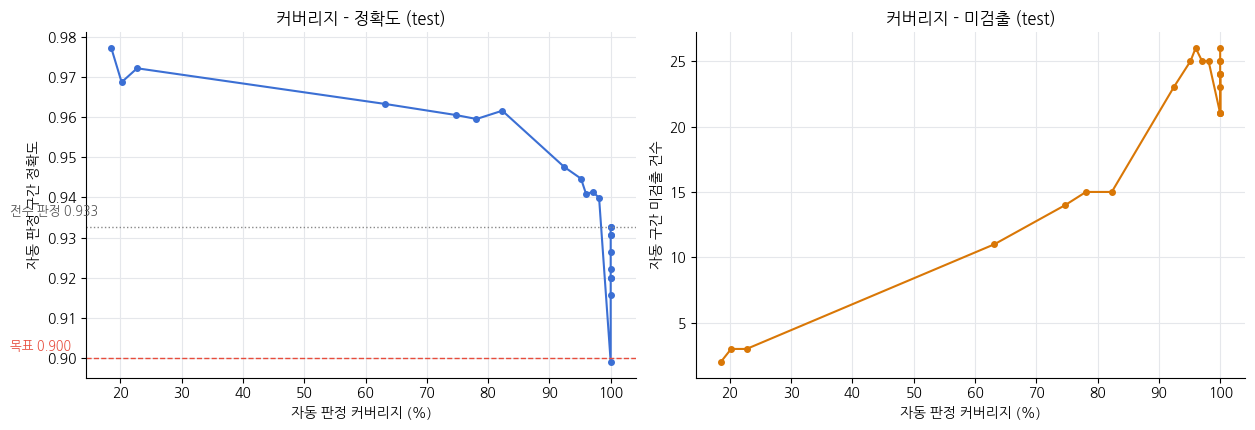

그래프 저장 coverage_curve.png


In [23]:
# @title 선택적 판정 (커버리지-정확도)
import numpy as np

ENS_SEL = [1, 2]
K_SEL = 8
TARGETS = [0.90, 0.93, 0.95, 0.98]
NQ = 150
MIN_N = 50
MIN_SIDE = 20

sv = torch.stack([Tv_all[j][:, :K_SEL].mean(1)[:, BIN_IDX]
                  for j in ENS_SEL]).mean(0).numpy()
st = torch.stack([Tt_all[j][:, :K_SEL].mean(1)[:, BIN_IDX]
                  for j in ENS_SEL]).mean(0).numpy()
yv = (Yv[:, BIN_IDX] > 0).numpy()
yt = (Yt[:, BIN_IDX] > 0).numpy()

def measure(s, y, lo, hi):
    low, high = s <= lo, s >= hi
    cov = low | high
    n = int(cov.sum())
    if n == 0:
        return (0.0, 0.0, 0, len(s), 0, 0, 0, 0)
    pb = s[cov] >= hi
    yy = y[cov]
    return (n / len(s), float((pb == yy).mean()), n, len(s) - n,
            int((~pb & yy).sum()), int((pb & ~yy).sum()),
            int(low.sum()), int(high.sum()))

def single_thr(s, y):
    cand = np.unique(s)
    accs = [float((((s >= t) & y) | ((s < t) & ~y)).mean()) for t in cand]
    return plateau_mid(list(cand), accs)

thr1 = single_thr(sv, yv)
v1, t1 = measure(sv, yv, thr1, thr1), measure(st, yt, thr1, thr1)
print("기준 조합 %s | k=%d | val %d장 / test %d장"
      % ("+".join("s%d" % SEEDS[j] for j in ENS_SEL), K_SEL, len(sv), len(st)))
print("전수 강제 판정 (단일 threshold %.4f)" % thr1)
print("  val 정확도 %.3f -> test 정확도 %.3f | 미검출 %d / 과검 %d"
      % (v1[1], t1[1], t1[4], t1[5]))

qs = np.unique(np.quantile(sv, np.linspace(0.0, 1.0, NQ)))
pairs = []
for lo in qs:
    for hi in qs[qs >= lo]:
        m = measure(sv, yv, lo, hi)
        if m[2] >= MIN_N and m[6] >= MIN_SIDE and m[7] >= MIN_SIDE:
            pairs.append((m[0], m[1], m[4], float(lo), float(hi), m[6], m[7]))
print("유효 경계 조합 %d개 (양쪽 각 %d장 이상)" % (len(pairs), MIN_SIDE))

print("")
print("=" * 104)
print("%8s | %-30s | %-44s" % ("목표", "val (기준 선택)", "test (실제 성능)"))
print("%8s | %9s %9s %7s | %9s %9s %7s %7s %6s"
      % ("정확도", "커버리지", "정확도", "보류", "커버리지", "정확도", "보류", "미검출", "과검"))
picks = []
for tg in TARGETS:
    ok = [q for q in pairs if q[1] >= tg]
    if not ok:
        print("%8.2f | 조건을 만족하는 구간 없음" % tg)
        continue
    b = max(ok, key=lambda q: q[0])
    tc = measure(st, yt, b[3], b[4])
    picks.append(("정확도 %.2f" % tg, b, tc))
    print("%8.2f | %8.1f%% %9.3f %7d | %8.1f%% %9.3f %7d %7d %6d"
          % (tg, 100 * b[0], b[1], len(sv) - b[5] - b[6],
             100 * tc[0], tc[1], tc[3], tc[4], tc[5]))

zero = [q for q in pairs if q[2] == 0 and q[1] >= 0.90]
if zero:
    bz = max(zero, key=lambda q: q[0])
    tz = measure(st, yt, bz[3], bz[4])
    picks.append(("미검출 0", bz, tz))
    print("-" * 104)
    print("%8s | %8.1f%% %9.3f %7d | %8.1f%% %9.3f %7d %7d %6d"
          % ("미검출0", 100 * bz[0], bz[1], len(sv) - bz[5] - bz[6],
             100 * tz[0], tz[1], tz[3], tz[4], tz[5]))
else:
    print("-" * 104)
    print("미검출0 | val에서 불량을 하나도 놓치지 않는 유효 구간 없음")
print("=" * 104)

for tag, b, tc in picks:
    if tc[1] >= 0.9:
        print("[%s] 경계 [%.4f, %.4f]" % (tag, b[3], b[4]))
        print("  자동 양품 %d장 / 자동 불량 %d장 = %d장(%.1f%%) 자동 판정"
              % (tc[6], tc[7], tc[2], 100 * tc[0]))
        print("  자동 구간 정확도 %.3f | 미검출 %d / 과검 %d"
              % (tc[1], tc[4], tc[5]))
        print("  육안 확인 %d장 (%.1f%%)" % (tc[3], 100 * (1 - tc[0])))
        print("")

curve = []
for tg in np.arange(0.88, 0.996, 0.005):
    ok = [q for q in pairs if q[1] >= tg]
    if not ok:
        continue
    b = max(ok, key=lambda q: q[0])
    tc = measure(st, yt, b[3], b[4])
    curve.append((tc[0], tc[1], tc[4]))
curve = sorted(set(curve))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.plot([c[0] * 100 for c in curve], [c[1] for c in curve], "o-",
        color="#3b6fd4", ms=4)
ax.axhline(0.9, color="#e74c3c", ls="--", lw=1)
ax.axhline(t1[1], color="#888", ls=":", lw=1)
ax.text(2, 0.902, "목표 0.900", color="#e74c3c", fontsize=9)
ax.text(2, t1[1] + 0.003, "전수 판정 %.3f" % t1[1], color="#555", fontsize=9)
ax.set_xlabel("자동 판정 커버리지 (%)")
ax.set_ylabel("자동 판정 구간 정확도")
ax.set_title("커버리지 - 정확도 (test)")
ax.grid(color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.plot([c[0] * 100 for c in curve], [c[2] for c in curve], "o-",
        color="#d97706", ms=4)
ax.set_xlabel("자동 판정 커버리지 (%)")
ax.set_ylabel("자동 구간 미검출 건수")
ax.set_title("커버리지 - 미검출 (test)")
ax.grid(color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("coverage_curve.png", dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy("coverage_curve.png", "/content/drive/MyDrive/coverage_curve.png")
print("그래프 저장 coverage_curve.png")

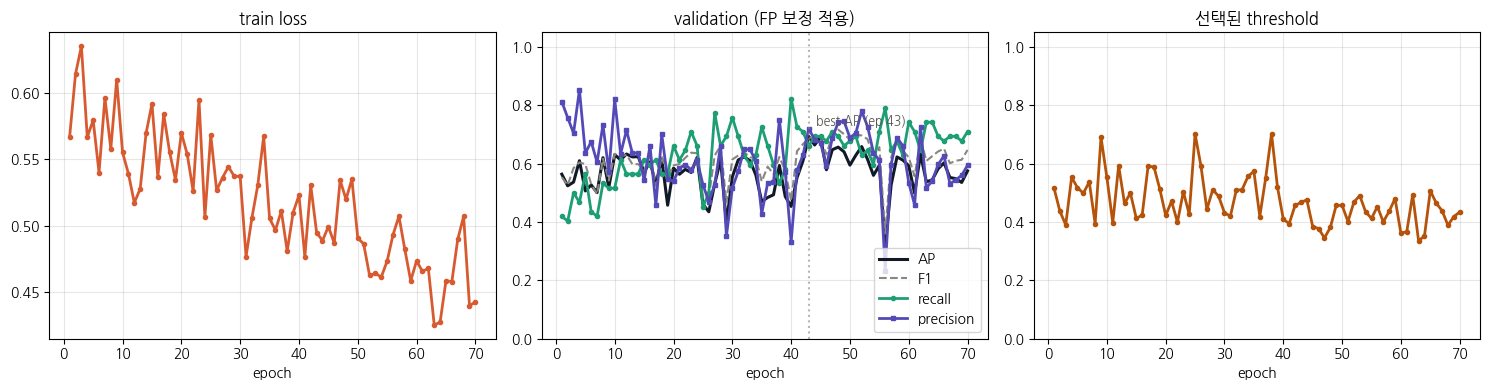

In [24]:
# @title 그래프로 나타내기 (MIL)
import matplotlib.pyplot as plt

losses, recs, precs, f1s, thrs, aps = zip(*history_ml)
ex = range(1, len(losses) + 1)
best_ep = max(range(len(aps)), key=lambda i: aps[i])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ex, losses, color="#D85A30", lw=2, marker="o", ms=3)
ax[0].set_title("train loss")
ax[0].set_xlabel("epoch")
ax[0].grid(alpha=0.3)

ax[1].plot(ex, aps, color="#111827", lw=2.2, label="AP")
ax[1].plot(ex, f1s, color="#888880", lw=1.5, ls="--", label="F1")
ax[1].plot(ex, recs, color="#1D9E75", lw=2, marker="o", ms=3, label="recall")
ax[1].plot(ex, precs, color="#534AB7", lw=2, marker="s", ms=3, label="precision")
ax[1].axvline(best_ep + 1, color="#888880", ls=":", alpha=0.6)
ax[1].annotate(f"best AP (ep {best_ep + 1})", xy=(best_ep + 1, aps[best_ep]),
               xytext=(5, 8), textcoords="offset points", fontsize=9, color="#555550")
ax[1].set_title("validation (FP 보정 적용)")
ax[1].set_xlabel("epoch")
ax[1].set_ylim(0, 1.05)
ax[1].grid(alpha=0.3)
ax[1].legend(loc="lower right")

ax[2].plot(ex, thrs, color="#B45309", lw=2, marker="o", ms=3)
ax[2].set_title("선택된 threshold")
ax[2].set_xlabel("epoch")
ax[2].set_ylim(0, 1.05)
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

가중치 best_mil.pth
[양/불]  test 475 die (불량 62, 13.1%) | 집계 상위 4개 평균 | TTA on
  thr 0.394  <- val에서 정확도 최대 구간의 중앙값
  val 정확도 0.928 -> test 정확도 0.933
  acc 0.933  (기준선 0.869, 목표 0.900)
  recall 0.565 [0.439, 0.697] | precision 0.875 [0.762, 0.961] | F1 0.686
  AP 0.770  (기저 0.131, 5.90배)
  TP 35  FN 27  FP 5  TN 408
------------------------------------------------------------------------------
운영점                  thr     정확도  recall  precision     과검
정확도 최대             0.394   0.933   0.565      0.875      5
F1 최대              0.377   0.935   0.581      0.878      5
recall 0.95        0.193   0.436   0.935      0.180    264
미검출 0              0.164   0.194   1.000      0.139    383
[원인]  불량 62장 안에서만 계산 | threshold는 val에서 지표별 고정
원인      thr   GT   검출   놓침    오검출  recall   prec     F1
P     0.103   39   39    0     23   1.000  0.629  0.772
S     0.336    8    5    3      7   0.625  0.417  0.500

정확도 0.9까지 0장 — 달성


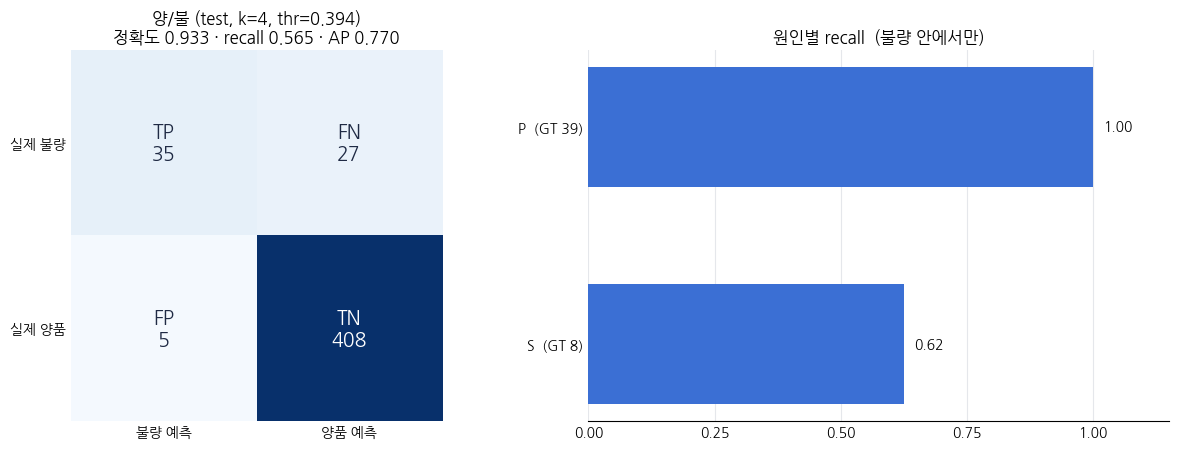

In [25]:
# @title 최종 평가 (val threshold 고정)
import numpy as np

K_AGG = 4
THR_MODE = "acc"
CKPT_CANDIDATES = ("best_mil.pth", "/content/drive/MyDrive/best_mil.pth")

wpath = next((q for q in CKPT_CANDIDATES if os.path.exists(q)), None)
assert wpath, "가중치를 찾지 못함 — MIL 학습 셀을 돌리거나 드라이브 마운트를 확인하세요"
model_ml.load_state_dict(torch.load(wpath, map_location=DEVICE))
if wpath != "best_mil.pth":
    shutil.copy(wpath, "best_mil.pth")
print("가중치 %s" % wpath)

def collect_agg(model, items, device, k=K_AGG):
    model.eval()
    T = torch.stack([die_topvals(model, p, device) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T[:, :k].mean(1), Y

def acc_of(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def best_acc_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [acc_of(Sx, Yx, t) for t in cand])

S_va, Y_va = collect_agg(model_ml, va_items, DEVICE)
THR_F1 = best_thr(S_va, Y_va)
THR_ACC = best_acc_thr(S_va, Y_va)
THR_BIN = THR_ACC if THR_MODE == "acc" else THR_F1
THR_R95 = thr_at_recall(S_va, Y_va, 0.95)
THR_R100 = thr_at_recall(S_va, Y_va, 1.0)
THR_LET = best_letter_thr(S_va, Y_va)

S, Y = collect_agg(model_ml, te_items, DEVICE)
r, p, f1, (tp, fp, fn, tn) = binary_metrics(S, Y, THR_BIN)
acc = (tp + tn) / len(S)
ap = average_precision(S, Y)
(r_lo, r_hi), (p_lo, p_hi) = bootstrap_ci(S, Y, THR_BIN)

is_bad = Y[:, BIN_IDX] > 0
n_bad_te = int(is_bad.sum())
prev = n_bad_te / len(S)

rows, skipped = [], []
for j, L in enumerate(LETTERS):
    gt = Y[is_bad, j] > 0
    if THR_LET[L] is None or int(gt.sum()) < MIN_REPORT:
        skipped.append(f"{L}(GT {int(gt.sum())})")
        continue
    pr = S[is_bad, j] >= THR_LET[L]
    det = int((gt & pr).sum())
    miss = int((gt & ~pr).sum())
    fa = int((~gt & pr).sum())
    rec = det / max(det + miss, 1)
    prec = det / max(det + fa, 1)
    rows.append((L, THR_LET[L], det + miss, det, miss, fa, rec, prec,
                 2 * rec * prec / max(rec + prec, 1e-9)))

print("=" * 78)
print(f"[양/불]  test {len(S)} die (불량 {n_bad_te}, {prev:.1%}) | 집계 상위 {K_AGG}개 평균"
      f" | TTA {'on' if TTA_EVAL else 'off'}")
print(f"  thr {THR_BIN:.3f}  <- val에서 {'정확도' if THR_MODE == 'acc' else 'F1'} 최대 구간의 중앙값")
print(f"  val 정확도 {acc_of(S_va, Y_va, THR_BIN):.3f} -> test 정확도 {acc:.3f}")
print(f"  acc {acc:.3f}  (기준선 {1 - prev:.3f}, 목표 0.900)")
print(f"  recall {r:.3f} [{r_lo:.3f}, {r_hi:.3f}] | precision {p:.3f} "
      f"[{p_lo:.3f}, {p_hi:.3f}] | F1 {f1:.3f}")
print(f"  AP {ap:.3f}  (기저 {prev:.3f}, {ap / max(prev, 1e-9):.2f}배)")
print(f"  TP {tp}  FN {fn}  FP {fp:.0f}  TN {tn:.0f}")
print("-" * 78)
print(f"{'운영점':16s} {'thr':>7s} {'정확도':>7s} {'recall':>7s} {'precision':>10s} {'과검':>6s}")
for tag, t_ in (("정확도 최대", THR_ACC), ("F1 최대", THR_F1),
                ("recall 0.95", THR_R95), ("미검출 0", THR_R100)):
    rr, pp, _, (_, ff, _, dd) = binary_metrics(S, Y, t_)
    print(f"{tag:16s} {t_:>7.3f} {acc_of(S, Y, t_):>7.3f} {rr:>7.3f} "
          f"{pp:>10.3f} {ff:>6.0f}")
print("=" * 78)
print(f"[원인]  불량 {n_bad_te}장 안에서만 계산 | threshold는 val에서 지표별 고정")
print(f"{'원인':4s} {'thr':>6s} {'GT':>4s} {'검출':>4s} {'놓침':>4s} {'오검출':>6s} "
      f"{'recall':>7s} {'prec':>6s} {'F1':>6s}")
for L, t_, n_, det, miss, fa, rec, prec, f1l in rows:
    print(f"{L:4s} {t_:>6.3f} {n_:>4d} {det:>4d} {miss:>4d} {fa:>6d} "
          f"{rec:>7.3f} {prec:>6.3f} {f1l:>6.3f}")
if skipped:
    print(f"\n표본 부족으로 보고 제외 (GT < {MIN_REPORT}): {', '.join(skipped)}")
short = int(-(-0.9 * len(S) // 1)) - (tp + int(tn))
print(f"\n정확도 0.9까지 {max(short, 0)}장" + (" 부족" if short > 0 else " — 달성"))
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
cm = np.array([[tp, fn], [int(round(fp)), int(round(tn))]])
ax = axes[0]
ax.imshow(cm, cmap="Blues", vmin=0)
tags = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{tags[i][j]}\n{cm[i, j]}", ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.55 else "#1f2a44")
ax.set_xticks([0, 1])
ax.set_xticklabels(["불량 예측", "양품 예측"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["실제 불량", "실제 양품"])
ax.set_title(f"양/불 (test, k={K_AGG}, thr={THR_BIN:.3f})\n"
             f"정확도 {acc:.3f} · recall {r:.3f} · AP {ap:.3f}")
for s_ in ax.spines.values():
    s_.set_visible(False)
ax.tick_params(length=0)

ax = axes[1]
if rows:
    ys = np.arange(len(rows))[::-1]
    ax.barh(ys, [row[6] for row in rows], height=0.55, color="#3b6fd4")
    for y_, row in zip(ys, rows):
        ax.text(max(row[6], 0.02) + 0.02, y_, f"{row[6]:.2f}", va="center", fontsize=10)
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{row[0]}  (GT {row[2]})" for row in rows])
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_title("원인별 recall  (불량 안에서만)")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(length=0)
ax.xaxis.grid(True, color="#e5e7eb", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [26]:
# @title TTA A/B
import time
import numpy as np

K_LIST = [1, 2, 4, 8, 16]

model_ml.load_state_dict(torch.load("best_mil.pth"))
model_ml.eval()

def collect_top(items, tta):
    T = torch.stack([die_topvals(model_ml, p, DEVICE, tta=tta) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T, Y

def acc_of2(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def pick_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return plateau_mid(cand, [acc_of2(Sx, Yx, t) for t in cand])

cache = {}
for tta in (False, True):
    t0 = time.time()
    Tv, Yv = collect_top(va_items, tta)
    Tt, Yt = collect_top(te_items, tta)
    cache[tta] = (Tv, Yv, Tt, Yt, time.time() - t0)
    print("TTA %-5s 계산 완료 %.0f초" % (str(tta), cache[tta][4]), flush=True)

print("")
print("=" * 88)
print("%5s %4s %10s %9s %10s %9s %8s %10s %6s %6s"
      % ("TTA", "k", "val정확도", "thr", "test정확도", "test AP", "recall",
         "precision", "미검출", "과검"))
rows = []
for tta in (False, True):
    Tv, Yv, Tt, Yt, _ = cache[tta]
    for k in K_LIST:
        Sv, St = Tv[:, :k].mean(1), Tt[:, :k].mean(1)
        thr = pick_thr(Sv, Yv)
        r_, p_, _, (tp_, fp_, fn_, tn_) = binary_metrics(St, Yt, thr)
        rows.append((tta, k, acc_of2(Sv, Yv, thr), thr, acc_of2(St, Yt, thr),
                     average_precision(St, Yt), r_, p_, fn_, int(fp_)))
best = max(rows, key=lambda v: v[2])
for v in rows:
    mark = "  <- val 기준 선택" if v is best else ""
    print("%5s %4d %10.3f %9.3f %10.3f %9.3f %8.3f %10.3f %6d %6d%s"
          % (str(v[0]), v[1], v[2], v[3], v[4], v[5], v[6], v[7], v[8], v[9], mark))
print("-" * 88)
base = [v for v in rows if v[0] is False and v[1] == 4][0]
print("기준 (TTA off, k=4)  test 정확도 %.3f / AP %.3f" % (base[4], base[5]))
print("선택 (TTA %s, k=%d)   test 정확도 %.3f / AP %.3f  (%+.3f)"
      % (best[0], best[1], best[4], best[5], best[4] - base[4]))
need = int(np.ceil(0.9 * len(te_items))) - int(round(best[4] * len(te_items)))
print("정확도 0.9까지 %d장" % max(need, 0))
print("=" * 88)
print("좋은 쪽으로 나오면 최종 평가 셀의 K_AGG 를 %d 로 두고 다시 실행하세요" % best[1])

TTA False 계산 완료 46초
TTA True  계산 완료 180초

  TTA    k     val정확도       thr    test정확도   test AP   recall  precision    미검출     과검
False    1      0.897     0.606      0.888     0.586    0.242      0.714     47      6
False    2      0.903     0.585      0.891     0.620    0.242      0.750     47      5
False    4      0.916     0.412      0.924     0.662    0.597      0.771     25     11
False    8      0.918     0.333      0.922     0.683    0.581      0.766     26     11
False   16      0.924     0.370      0.905     0.675    0.323      0.870     42      3
 True    1      0.928     0.462      0.926     0.716    0.484      0.909     32      3  <- val 기준 선택
 True    2      0.928     0.423      0.933     0.749    0.565      0.875     27      5
 True    4      0.928     0.394      0.933     0.770    0.565      0.875     27      5
 True    8      0.928     0.352      0.924     0.769    0.484      0.882     32      4
 True   16      0.928     0.310      0.916     0.750    0.403      0.893  

In [27]:
# @title 체크포인트 저장 (가중치 + 설정 + threshold)
import json, hashlib, datetime, time

CKPT = "phosem_v3.pt"
META_JSON = "phosem_v3_meta.json"
DRIVE_DIR = "/content/drive/MyDrive"

is_resnet = any(m.__class__.__name__ == "ResNet" for m in model_ml.modules())
builder = ("사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)" if is_resnet
           else "MIL 모델 셀 (자체 build_mil_cnn)")
n_bad_ckpt = int((Y[:, BIN_IDX] > 0).sum())
prev_ckpt = n_bad_ckpt / len(S)

meta = {
    "builder_cell": builder,
    "arch": "resnet18_imagenet" if is_resnet else "build_mil_cnn",
    "n_params": sum(p.numel() for p in model_ml.parameters()),
    "input_norm": "imagenet" if is_resnet else "none",
    "letters": LETTERS, "bin_idx": BIN_IDX,
    "patch": PATCH, "stride": STRIDE,
    "roi_box": list(ROI_C),
    "k_ring": K_RING, "k_box": K_BOX, "k_rand": K_RAND,
    "ring_jitter": RING_JITTER, "n_ring_eval": N_RING_EVAL,
    "mesa_source": "hough_per_image", "mesa_fallback": list(MESA_FALLBACK),
    "agg": f"topk{K_AGG}_mean", "k_agg": K_AGG,
    "thr_mode": THR_MODE,
    "thr_bin": float(THR_BIN), "thr_acc": float(THR_ACC), "thr_f1": float(THR_F1),
    "thr_r95": float(THR_R95), "thr_r100": float(THR_R100),
    "thr_letter": {k: (None if v is None else float(v)) for k, v in THR_LET.items()},
    "class_names": CLASS_NAMES,
    "drop_letters": DROP_LETTERS,
    "excluded_tags": sorted(EXCLUDE_TAGS),
    "require_clean_bg": REQUIRE_CLEAN_BG,
    "split_seed": 42,
    "n_train": len(tr_items), "n_val": len(va_items), "n_test": len(te_items),
    "test_n_bad": n_bad_ckpt, "test_prevalence": round(prev_ckpt, 4),
    "baseline_acc": round(1 - prev_ckpt, 4), "baseline_ap": round(prev_ckpt, 4),
    "test_ap": float(ap), "ap_over_baseline": round(float(ap) / max(prev_ckpt, 1e-9), 2),
    "test_recall": float(r), "test_precision": float(p), "test_acc": float(acc),
    "torch": torch.__version__,
    "saved_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
torch.save({"state_dict": model_ml.state_dict(), "meta": meta}, CKPT)
h = hashlib.sha256(open(CKPT, "rb").read()).hexdigest()[:16]
json.dump({**meta, "sha256_16": h}, open(META_JSON, "w"),
          ensure_ascii=False, indent=2)

print(f"로컬 저장 완료 /content/{CKPT}  "
      f"({os.path.getsize(CKPT) / 1024 / 1024:.1f} MB)  sha256 {h}")
print(json.dumps(meta, ensure_ascii=False, indent=2))

def copy_to_drive(paths, retry=2):
    for attempt in range(retry + 1):
        try:
            os.makedirs(DRIVE_DIR, exist_ok=True)
            for p_ in paths:
                shutil.copy(p_, os.path.join(DRIVE_DIR, os.path.basename(p_)))
            return True
        except OSError as e:
            print(f"드라이브 복사 실패 {attempt + 1}/{retry + 1}: {e}")
            if attempt == retry:
                return False
            try:
                from google.colab import drive
                drive.flush_and_unmount()
                time.sleep(5)
                drive.mount("/content/drive", force_remount=True)
                print("재마운트 완료, 재시도합니다")
            except Exception as e2:
                print("재마운트 실패:", e2)
                return False
    return False

if copy_to_drive([CKPT, META_JSON]):
    print(f"\n드라이브 복사 완료 {DRIVE_DIR}/{CKPT}")
else:
    print("\n드라이브에 못 올렸습니다. 로컬 파일은 정상이니 직접 내려받으세요")
    try:
        from google.colab import files
        files.download(CKPT)
        files.download(META_JSON)
    except Exception as e:
        print("자동 다운로드 실패:", e)
        print(f"좌측 파일 탭에서 {CKPT} 우클릭 → 다운로드")

로컬 저장 완료 /content/phosem_v3.pt  (42.7 MB)  sha256 afe6d78b3e9179f1
{
  "builder_cell": "사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)",
  "arch": "resnet18_imagenet",
  "n_params": 11178051,
  "input_norm": "imagenet",
  "letters": "PS",
  "bin_idx": 2,
  "patch": 128,
  "stride": 64,
  "roi_box": [
    384,
    236,
    564,
    416
  ],
  "k_ring": 3,
  "k_box": 2,
  "k_rand": 7,
  "ring_jitter": 12,
  "n_ring_eval": 16,
  "mesa_source": "hough_per_image",
  "mesa_fallback": [
    522.0,
    277.0,
    116.0
  ],
  "agg": "topk4_mean",
  "k_agg": 4,
  "thr_mode": "acc",
  "thr_bin": 0.3937435448169708,
  "thr_acc": 0.3937435448169708,
  "thr_f1": 0.37719589471817017,
  "thr_r95": 0.19328832626342773,
  "thr_r100": 0.16363850235939026,
  "thr_letter": {
    "P": 0.10307133197784424,
    "S": 0.3364778161048889
  },
  "class_names": [
    "양품",
    "P",
    "S",
    "PS",
    "공식불량"
  ],
  "drop_letters": "BC",
  "excluded_tags": [
    "D",
    "F",
    "U",
    "X"
  ],
  "require_clean_

In [28]:
# @title 환경 기록 (requirements.txt)
ENV_OUT = "requirements.txt"

!pip freeze > {ENV_OUT}
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(ENV_OUT, "/content/drive/MyDrive/" + ENV_OUT)

print(f"torch {torch.__version__} | torchvision {__import__('torchvision').__version__} "
      f"| CUDA {torch.cuda.is_available()}")
print(f"저장 완료: {ENV_OUT}")

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | CUDA True
저장 완료: requirements.txt


In [29]:
# @title 데이터 목록 내보내기 (train/val/test)
import csv

SPLIT_OUT = "phosem_v3_split.csv"

overlap_tv = {p for p, _ in tr_items} & {p for p, _ in va_items}
overlap_tt = {p for p, _ in tr_items} & {p for p, _ in te_items}
overlap_vt = {p for p, _ in va_items} & {p for p, _ in te_items}

with open(SPLIT_OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "분할", "라벨"])
    for split_name, items in (("train", tr_items), ("val", va_items), ("test", te_items)):
        for p, c in items:
            wr.writerow([os.path.basename(p), split_name, CLASS_NAMES[c]])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(SPLIT_OUT, "/content/drive/MyDrive/" + SPLIT_OUT)

print(f"저장 완료: {SPLIT_OUT}  (train {len(tr_items)} / val {len(va_items)} / test {len(te_items)})")
print("분할 방법: 클래스별 shuffle(seed 42) 후 test 20% / val 20% / train 나머지")
print(f"train-val 겹침 {len(overlap_tv)}장 | train-test 겹침 {len(overlap_tt)}장 | val-test 겹침 {len(overlap_vt)}장")

저장 완료: phosem_v3_split.csv  (train 1440 / val 475 / test 475)
분할 방법: 클래스별 shuffle(seed 42) 후 test 20% / val 20% / train 나머지
train-val 겹침 0장 | train-test 겹침 0장 | val-test 겹침 0장


In [30]:
# @title FP / FN 목록
import os
from collections import Counter

score = S[:, BIN_IDX]
pred = score >= THR_BIN
is_bad = Y[:, BIN_IDX] > 0

fp_list = [(te_items[i][0], float(score[i]), LETTERS[int(S[i, :len(LETTERS)].argmax())])
           for i in range(len(S)) if pred[i] and not is_bad[i]]
fn_list = [(te_items[i][0], float(score[i]), CLASS_NAMES[te_items[i][1]])
           for i in range(len(S)) if not pred[i] and is_bad[i]]

print(f"[FP {len(fp_list)}건]  양품인데 불량 판정 — 라벨 오류 여부 확인 대상")
for path, s, L in sorted(fp_list, key=lambda v: -v[1]):
    print(f"  {os.path.basename(path):45s} 점수 {s:.3f}  최고지표 {L}")

print(f"\n[FN {len(fn_list)}건]  불량인데 놓침")
for path, s, cls in sorted(fn_list, key=lambda v: v[1]):
    print(f"  {os.path.basename(path):45s} 점수 {s:.3f}  정답 {cls}")

print(f"\nFP 최고지표 분포 {dict(Counter(L for _, _, L in fp_list))}")
print(f"FN 정답 분포     {dict(Counter(c for _, _, c in fn_list))}")

[FP 5건]  양품인데 불량 판정 — 라벨 오류 여부 확인 대상
  510-die-양-O.jpg                             점수 0.461  최고지표 P
  35.jpg                                        점수 0.424  최고지표 P
  486-die-양-O.jpg                             점수 0.419  최고지표 P
  524-die-양-O.jpg                             점수 0.398  최고지표 S
  518-die-양-O.jpg                             점수 0.394  최고지표 P

[FN 27건]  불량인데 놓침
  1010-die-불-pP.jpg                           점수 0.173  정답 P
  450.jpg                                       점수 0.178  정답 공식불량
  132-die-불-P.jpg                             점수 0.184  정답 P
  1004.jpg                                      점수 0.192  정답 공식불량
  139-die-불-pP.jpg                            점수 0.195  정답 P
  676-die-불-pPBC.jpg                          점수 0.197  정답 P
  557.jpg                                       점수 0.198  정답 공식불량
  211-die-불-pP.jpg                            점수 0.203  정답 P
  539-die-불-P.jpg                             점수 0.203  정답 P
  489-die-불-pPB.jpg                      

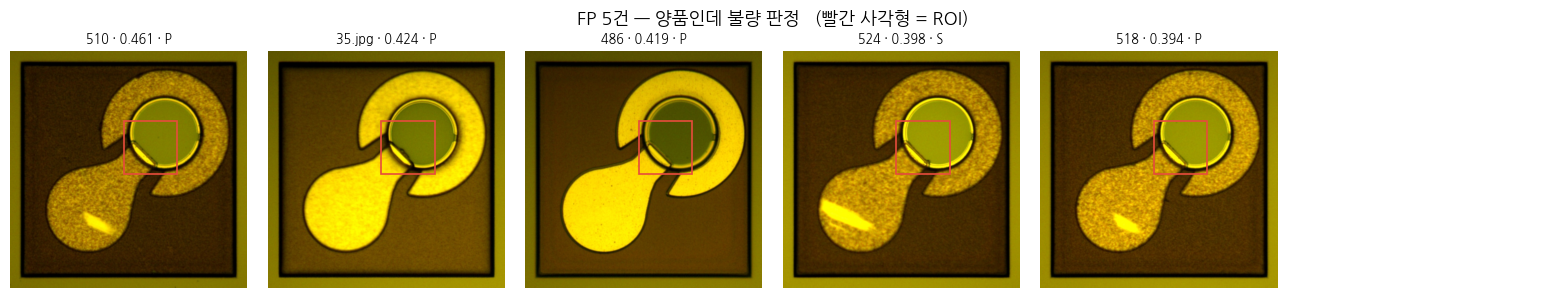

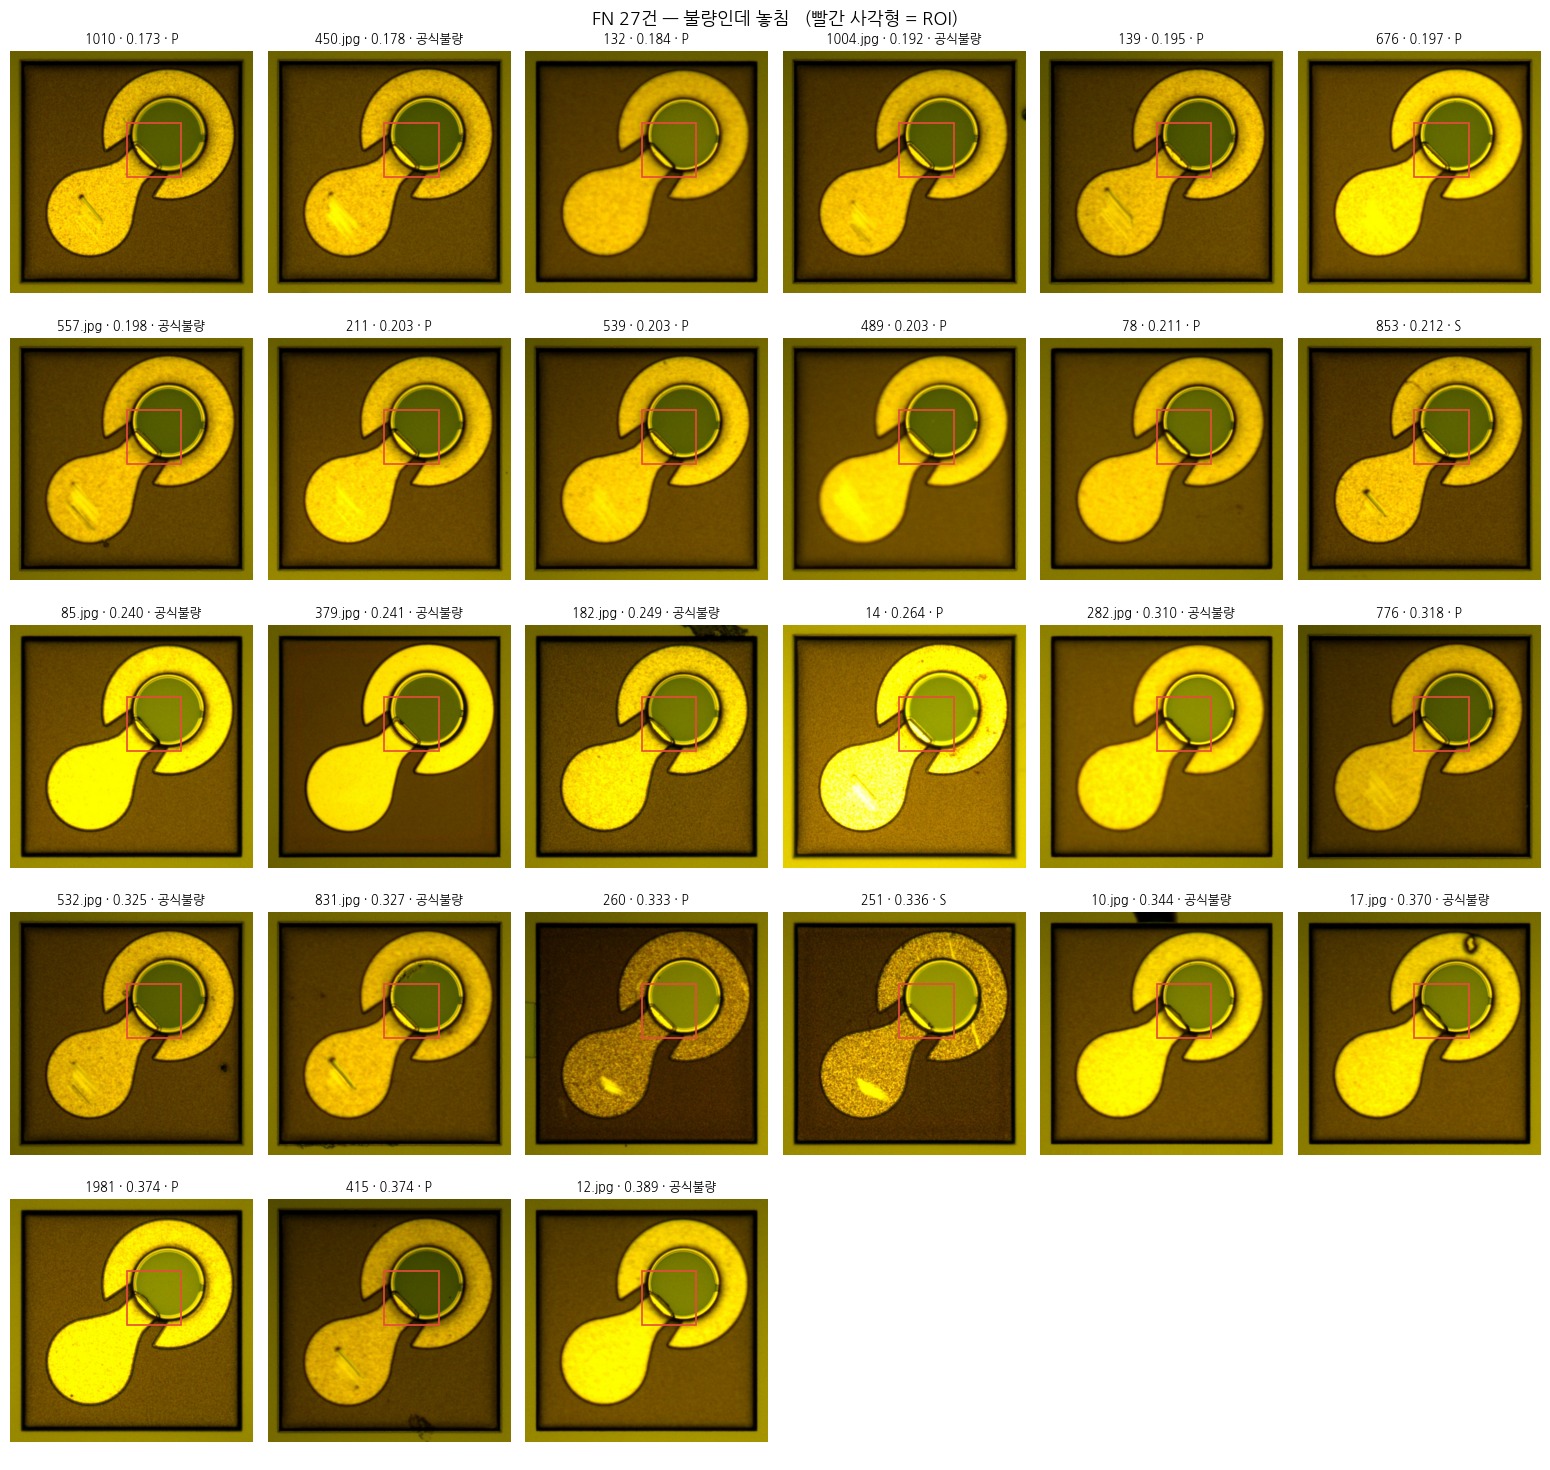


검토표 저장 /content/drive/MyDrive/label_review.csv  (32행)
판정 열에 '오류' 또는 '정상'을 채운 뒤 같은 경로에 덮어쓰세요
오답 32건 중 -15건이 '오류'로 판명되면 정확도 0.9입니다


In [31]:
# @title FP / FN 이미지 격자 보기
import csv
import numpy as np
import matplotlib.patches as mpatches
from PIL import Image

REVIEW_CSV = "label_review.csv"
COLS, THUMB = 6, 2.6

def show_grid(items, title):
    if not items:
        print(f"{title}: 없음")
        return
    n = len(items)
    rows_n = (n + COLS - 1) // COLS
    fig, axes = plt.subplots(rows_n, COLS,
                             figsize=(COLS * THUMB, rows_n * THUMB * 1.15))
    axes = np.atleast_1d(axes).ravel()
    for ax, (path, sc, lab) in zip(axes, items):
        ax.imshow(Image.open(path).convert("RGB"))
        x0, y0, x1, y1 = ROI_C
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, ec="#e74c3c", lw=1.2))
        ax.set_title(f"{os.path.basename(path).split('-')[0]} · {sc:.3f} · {lab}",
                     fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{title}   (빨간 사각형 = ROI)", fontsize=13)
    plt.tight_layout()
    plt.show()

fp_sorted = sorted(fp_list, key=lambda v: -v[1])
fn_sorted = sorted(fn_list, key=lambda v: v[1])
show_grid(fp_sorted, f"FP {len(fp_sorted)}건 — 양품인데 불량 판정")
show_grid(fn_sorted, f"FN {len(fn_sorted)}건 — 불량인데 놓침")

with open(REVIEW_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "구분", "점수", "현재라벨", "판정"])
    for path, sc, _ in fp_sorted:
        wr.writerow([os.path.basename(path), "FP", f"{sc:.3f}", "양품", ""])
    for path, sc, lab in fn_sorted:
        wr.writerow([os.path.basename(path), "FN", f"{sc:.3f}", lab, ""])

shutil.copy(REVIEW_CSV, "/content/drive/MyDrive/" + REVIEW_CSV)
n_total = len(fp_sorted) + len(fn_sorted)
need = int(np.ceil(0.9 * len(S))) - (tp + int(tn))
print(f"\n검토표 저장 /content/drive/MyDrive/{REVIEW_CSV}  ({n_total}행)")
print("판정 열에 '오류' 또는 '정상'을 채운 뒤 같은 경로에 덮어쓰세요")
print(f"오답 {n_total}건 중 {need}건이 '오류'로 판명되면 정확도 0.9입니다")

In [32]:
# @title 라벨 검토 반영 재계산
import csv
import unicodedata
import numpy as np

MARK_OK = """
366-die-양-O.jpg
315-die-양-O.jpg
520-die-양-O.jpg
1056-die-양-po.jpg
126-die-양-po.jpg
2047-die-양-po.jpg
"""

MARK_BAD = """
1035-die-불-pC.jpg
"""

REVIEW_IN = "/content/drive/MyDrive/label_review.csv"
OK_WORDS = {"양품", "정상", "ok", "o"}
BAD_WORDS = {"불량", "오류", "ng", "x"}

def nkey(name):
    return unicodedata.normalize("NFC", os.path.basename(str(name)).strip())

def _names(block):
    return {nkey(t) for t in block.split() if t.strip().endswith(".jpg")}

ok_set, bad_set = _names(MARK_OK), _names(MARK_BAD)
if os.path.exists(REVIEW_IN):
    n_csv = 0
    with open(REVIEW_IN, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            v = (row.get("판정") or "").strip().lower()
            nm = nkey(row.get("파일명") or "")
            if not nm or not v:
                continue
            n_csv += 1
            if v in OK_WORDS:
                ok_set.add(nm)
            elif v in BAD_WORDS:
                bad_set.add(nm)
    print("검토표에서 판정 %d건 추가로 읽음" % n_csv)
print("표기 합계: 라벨 정상 %d건 / 라벨 오류 %d건" % (len(ok_set), len(bad_set)))

score_b = S[:, BIN_IDX]
y0 = Y[:, BIN_IDX] > 0
pred_b = score_b >= THR_BIN
N_TE = len(te_items)

def metrics(y):
    a = int((pred_b & y).sum())
    b = int((~pred_b & y).sum())
    c = int((pred_b & ~y).sum())
    d = int((~pred_b & ~y).sum())
    return ((a + d) / N_TE, a / max(a + b, 1), a / max(a + c, 1), a, b, c, d)

confirmed, pending, settled = set(), set(), set()
seen = set()
for i, (path, _) in enumerate(te_items):
    if bool(pred_b[i]) == bool(y0[i]):
        continue
    nm = nkey(path)
    seen.add(nm)
    now_bad = bool(y0[i])
    if nm in bad_set or (now_bad and nm in ok_set):
        confirmed.add(i)
    elif nm in ok_set:
        settled.add(i)
    else:
        pending.add(i)

def flipped(idx):
    y = y0.clone()
    for i in idx:
        y[i] = ~y[i]
    return y

cur = metrics(y0)
lo = metrics(flipped(confirmed))
hi = metrics(flipped(confirmed | pending))
n_wrong = len(confirmed) + len(pending) + len(settled)
need = int(np.ceil(0.9 * N_TE)) - int(round(cur[0] * N_TE))
unmatched = (ok_set | bad_set) - seen

print("=" * 78)
print("오답 %d건 | 라벨오류 확정 %d | 판정 보류 %d | 라벨정상 확정 %d"
      % (n_wrong, len(confirmed), len(pending), len(settled)))
if unmatched:
    print("현재 오답 목록에 없어 무시된 표기 %d건: %s"
          % (len(unmatched), ", ".join(sorted(unmatched))))
print("-" * 78)
print("%-18s %8s %8s %10s %5s %5s %5s %5s"
      % ("", "정확도", "recall", "precision", "TP", "FN", "FP", "TN"))
for tag, m in (("검토 전", cur), ("하한 (확정만)", lo), ("상한 (보류 포함)", hi)):
    print("%-18s %8.3f %8.3f %10.3f %5d %5d %5d %5d"
          % (tag, m[0], m[1], m[2], m[3], m[4], m[5], m[6]))
print("-" * 78)
if pending:
    print("정확도 0.9 까지 %d장 — 보류 %d건 중 %d건(%.0f%%)이 라벨 오류면 달성"
          % (max(need, 0), len(pending), max(need, 0),
             100 * max(need, 0) / len(pending)))
else:
    print("정확도 0.9 까지 %d장" % max(need, 0))
print("상한은 보류를 전부 라벨 오류로 가정한 값이라 실제 상한이 아닙니다")
print("=" * 78)

OUT = "label_pending.csv"
with open(OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "구분", "점수", "현재라벨", "포셈판정"])
    for i in sorted(pending, key=lambda i: -float(score_b[i])):
        wr.writerow([os.path.basename(te_items[i][0]),
                     "FN" if y0[i] else "FP", "%.3f" % float(score_b[i]),
                     CLASS_NAMES[te_items[i][1]], ""])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT, "/content/drive/MyDrive/" + OUT)
print("판정 보류 %d건을 %s 로 저장 — 포셈 확인 요청용" % (len(pending), OUT))
print("학습에 반영하려면 같은 기준을 train/val 에도 적용하고 원본 파일명을 바꿔야 합니다")

검토표에서 판정 0건 추가로 읽음
표기 합계: 라벨 정상 6건 / 라벨 오류 1건
오답 32건 | 라벨오류 확정 0 | 판정 보류 32 | 라벨정상 확정 0
현재 오답 목록에 없어 무시된 표기 7건: 1035-die-불-pC.jpg, 1056-die-양-po.jpg, 126-die-양-po.jpg, 2047-die-양-po.jpg, 315-die-양-O.jpg, 366-die-양-O.jpg, 520-die-양-O.jpg
------------------------------------------------------------------------------
                        정확도   recall  precision    TP    FN    FP    TN
검토 전                  0.933    0.565      0.875    35    27     5   408
하한 (확정만)              0.933    0.565      0.875    35    27     5   408
상한 (보류 포함)            1.000    1.000      1.000    40     0     0   435
------------------------------------------------------------------------------
정확도 0.9 까지 0장 — 보류 32건 중 0건(0%)이 라벨 오류면 달성
상한은 보류를 전부 라벨 오류로 가정한 값이라 실제 상한이 아닙니다
판정 보류 32건을 label_pending.csv 로 저장 — 포셈 확인 요청용
학습에 반영하려면 같은 기준을 train/val 에도 적용하고 원본 파일명을 바꿔야 합니다


In [33]:
# @title 집계 방식 A/B
assert "KMAX" in globals(), "MIL 추론 / 지표 셀 맨 위에 KMAX = 16 이 있어야 합니다"

def collect_topvals(model, items, device):
    model.eval()
    T = torch.stack([die_topvals(model, p, device) for p, _ in items])
    Y = torch.stack([letter_vec(g) for _, g in items])
    return T, Y

def acc_of(Sx, Yx, thr):
    _, _, _, (a, b, c, d) = binary_metrics(Sx, Yx, thr)
    return (a + d) / len(Sx)

def best_acc_thr(Sx, Yx):
    cand = sorted(set(Sx[:, BIN_IDX].tolist()))
    return max(cand, key=lambda t: acc_of(Sx, Yx, t))

Tv, Yv = collect_topvals(model_ml, va_items, DEVICE)
Tt, Yt = collect_topvals(model_ml, te_items, DEVICE)

n_bad_ab = int((Yt[:, BIN_IDX] > 0).sum())
prev = n_bad_ab / len(Yt)
print(f"val {len(Yv)}장 | test {len(Yt)}장 | 불량 {n_bad_ab}장 ({prev:.1%}) "
      f"| 기준선 정확도 {1 - prev:.3f}\n")

res = []
for k in (1, 2, 4, 8, 16):
    Sv, St = Tv[:, :k].mean(1), Tt[:, :k].mean(1)
    apv, apt = average_precision(Sv, Yv), average_precision(St, Yt)
    t2 = best_acc_thr(Sv, Yv)
    va = acc_of(Sv, Yv, t2)
    ta = acc_of(St, Yt, t2)
    rc, pc, _, (_, ff, _, dd) = binary_metrics(St, Yt, t2)
    res.append((k, apv, va, t2, ta, apt, rc, pc, ff / max(ff + dd, 1)))

pick = max(res, key=lambda v: (v[2], v[1]))[0]
hdr = (f"{'k':>3s} {'val AP':>7s} {'val 정확도':>10s} | {'thr':>7s} "
       f"{'test 정확도':>11s} {'test AP':>8s} {'recall':>7s} {'prec':>6s} {'과검율':>7s}")
print(hdr)
print("-" * len(hdr))
for k, apv, va, t2, ta, apt, rc, pc, fpr in res:
    mark = "  <- val 기준 선택" if k == pick else ""
    print(f"{k:>3d} {apv:>7.3f} {va:>10.3f} | {t2:>7.3f} {ta:>11.3f} "
          f"{apt:>8.3f} {rc:>7.3f} {pc:>6.3f} {fpr:>7.3f}{mark}")

best = [v for v in res if v[0] == pick][0]
print(f"\nval 정확도 기준 k = {pick}  ->  test 정확도 {best[4]:.3f}")
print(f"최종 평가 셀의 K_AGG 를 {pick} 로 바꾸고 다시 실행하세요")
short = int(-(-0.9 * len(Yt) // 1)) - int(round(best[4] * len(Yt)))
if short > 0:
    print(f"정확도 0.9까지 {short}장 부족")

val 475장 | test 475장 | 불량 62장 (13.1%) | 기준선 정확도 0.869

  k  val AP    val 정확도 |     thr    test 정확도  test AP  recall   prec     과검율
----------------------------------------------------------------------------
  1   0.703      0.928 |   0.462       0.926    0.716   0.484  0.909   0.007
  2   0.697      0.928 |   0.423       0.933    0.749   0.565  0.875   0.012
  4   0.696      0.928 |   0.394       0.933    0.770   0.565  0.875   0.012
  8   0.727      0.928 |   0.352       0.924    0.769   0.484  0.882   0.010
 16   0.741      0.928 |   0.310       0.916    0.750   0.403  0.893   0.007  <- val 기준 선택

val 정확도 기준 k = 16  ->  test 정확도 0.916
최종 평가 셀의 K_AGG 를 16 로 바꾸고 다시 실행하세요


In [34]:
# @title 체크포인트 불러오기
import json, hashlib
import torchvision.models as tvm

CKPT_IN = "/content/drive/MyDrive/phosem_v3.pt"

assert os.path.exists(CKPT_IN), f"체크포인트 없음: {CKPT_IN}"
print("sha256", hashlib.sha256(open(CKPT_IN, "rb").read()).hexdigest()[:16])

blob = torch.load(CKPT_IN, map_location=DEVICE, weights_only=False)
m = blob["meta"]
print(json.dumps(m, ensure_ascii=False, indent=2))

if m["arch"] == "resnet18_imagenet":
    class ImageNetNorm(nn.Module):
        def __init__(self):
            super().__init__()
            self.register_buffer("m", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
            self.register_buffer("s", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

        def forward(self, x):
            return (x - self.m) / self.s

    net = tvm.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, len(m["letters"]) + 1)
    model_load = nn.Sequential(ImageNetNorm(), net)
else:
    model_load = build_mil_cnn(tuple(m.get("channels", (16, 32, 64))),
                               len(m["letters"]) + 1, m.get("pool", 4))

model_load.load_state_dict(blob["state_dict"])
model_load = model_load.to(DEVICE).eval()
print(f"\n로드 완료 | {m['builder_cell']}")
print(f"파라미터 {sum(p.numel() for p in model_load.parameters()):,}")
print(f"판정 규칙: patch {m['patch']} / stride {m['stride']} / "
      f"상위 {m['k_agg']}개 평균 / threshold {m['thr_bin']:.3f}")

if "te_items" in globals() and te_items:
    probe = te_items[0][0]
    v = die_topvals(model_load, probe, DEVICE)[:m["k_agg"]].mean(0)
    sc = float(v[m["bin_idx"]])
    print(f"\n확인용 1장  {os.path.basename(probe)}  불량점수 {sc:.3f} → "
          f"{'불량' if sc >= m['thr_bin'] else '양품'}")

sha256 afe6d78b3e9179f1
{
  "builder_cell": "사전학습 백본 MIL 모델 셀 (ResNet18 + ImageNetNorm)",
  "arch": "resnet18_imagenet",
  "n_params": 11178051,
  "input_norm": "imagenet",
  "letters": "PS",
  "bin_idx": 2,
  "patch": 128,
  "stride": 64,
  "roi_box": [
    384,
    236,
    564,
    416
  ],
  "k_ring": 3,
  "k_box": 2,
  "k_rand": 7,
  "ring_jitter": 12,
  "n_ring_eval": 16,
  "mesa_source": "hough_per_image",
  "mesa_fallback": [
    522.0,
    277.0,
    116.0
  ],
  "agg": "topk4_mean",
  "k_agg": 4,
  "thr_mode": "acc",
  "thr_bin": 0.3937435448169708,
  "thr_acc": 0.3937435448169708,
  "thr_f1": 0.37719589471817017,
  "thr_r95": 0.19328832626342773,
  "thr_r100": 0.16363850235939026,
  "thr_letter": {
    "P": 0.10307133197784424,
    "S": 0.3364778161048889
  },
  "class_names": [
    "양품",
    "P",
    "S",
    "PS",
    "공식불량"
  ],
  "drop_letters": "BC",
  "excluded_tags": [
    "D",
    "F",
    "U",
    "X"
  ],
  "require_clean_bg": false,
  "split_seed": 42,
  "n_train"

정답지 2000행 로드  (/content/drive/MyDrive/정답지_260731.csv)
채점 대상 폴더 788장  (/content/drive/MyDrive/260731)
앙상블 3개로 채점 (k=8, val 기준 선택된 값)
  200/788
  400/788
  600/788

점수 CSV 저장 완료: 정답지_260731_점수.csv  (788행)
[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 1212건

채점 대상 788장  (정답지 라벨 기준, 미판정/제외 0건)
불량 118 / 양품 670  (불량률 15.0%)

[표준 보고표]  정답지_260731 · 788장 · 불량 118장 (π=15.0%)
  주지표   AUROC          0.669
  보조지표 AP + π         0.345  (π 0.150)
  작동점①  상위 10% (79장)   검출률 0.246  정밀도 0.367
  작동점②  상위 25% (197장)   검출률 0.466  정밀도 0.279
  작동점③  검출률 90%     672장 (85.3%)
           검출률 95%     742장 (94.2%)
  작동점④  최저 순위(진단) 779등 / 788장
  방법     split_seed 42 · 앙상블(k=8) ['ens0.pth', 'ens1.pth', 'ens2.pth']


/tmp/ipykernel_847/1323800317.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc = float(np.trapz(tpr_c, fpr_c))


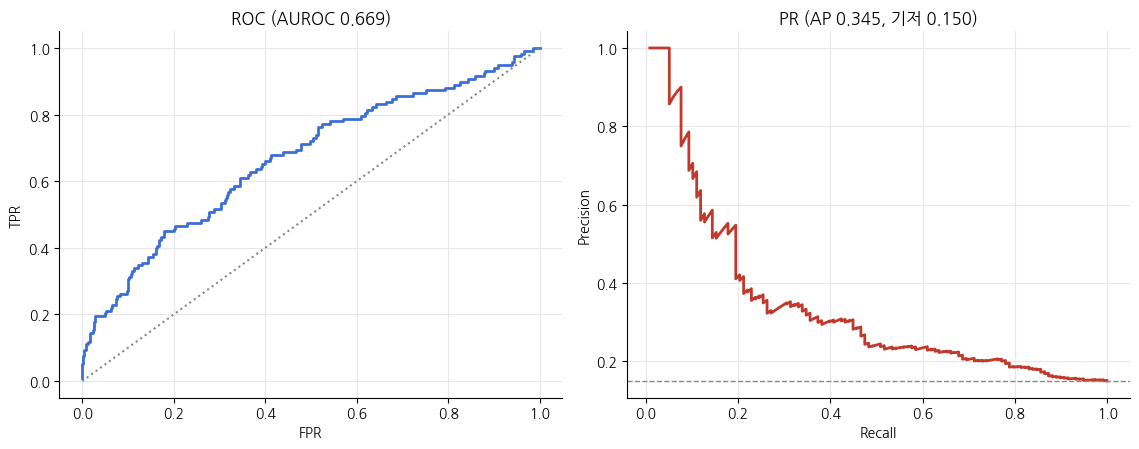

곡선 저장: roc_260731.png


In [35]:
# @title 정답지 채점 (공식 배치)
import csv
import numpy as np

OUT_SCORE_CSV = "정답지_260731_점수.csv"
OUT_ROC_PNG = "roc_260731.png"

assert os.path.exists(ANSWER_CSV), f"정답지 CSV 없음: {ANSWER_CSV}"
assert os.path.isdir(EXT_DIR), f"이미지 폴더 없음: {EXT_DIR}"

def read_answer_csv(path):
    out = {}
    with open(path, encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            name = os.path.basename((row.get("파일") or row.get("파일명") or "").strip())
            if name:
                out[name] = row
    return out

answers = read_answer_csv(ANSWER_CSV)
print(f"정답지 {len(answers)}행 로드  ({ANSWER_CSV})")

ext_paths = sorted(p for p in glob.glob(os.path.join(EXT_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS))
print(f"채점 대상 폴더 {len(ext_paths)}장  ({EXT_DIR})")

ens_models = []
for w in ENS_PATHS:
    m_ = build_mil_resnet().to(DEVICE)
    m_.load_state_dict(torch.load(w, map_location=DEVICE))
    m_.eval()
    ens_models.append(m_)
GRADE_K = BEST_ENS_K if "BEST_ENS_K" in globals() else 1
print(f"앙상블 {len(ens_models)}개로 채점 (k={GRADE_K}, val 기준 선택된 값)")

scores = {}
for i, p in enumerate(ext_paths):
    vs = [die_topvals(mm, p, DEVICE)[:GRADE_K].mean(0)[BIN_IDX].item() for mm in ens_models]
    scores[os.path.basename(p)] = float(np.mean(vs))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(ext_paths)}")

with open(OUT_SCORE_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "불량점수"])
    for name in sorted(scores, key=lambda n: -scores[n]):
        wr.writerow([name, f"{scores[name]:.6f}"])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_SCORE_CSV, "/content/drive/MyDrive/" + OUT_SCORE_CSV)
print(f"\n점수 CSV 저장 완료: {OUT_SCORE_CSV}  ({len(scores)}행)")

matched, unscored, excluded_cnt = [], [], 0
for name, row in answers.items():
    if name not in scores:
        unscored.append(name)
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if target_flag and not target_flag.startswith("예"):
        excluded_cnt += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "불량" in label:
        matched.append((name, scores[name], 1))
    elif "양품" in label:
        matched.append((name, scores[name], 0))
    else:
        excluded_cnt += 1

if unscored:
    print(f"[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 {len(unscored)}건")

n = len(matched)
assert n > 0, "채점 대상과 일치하는 이미지가 없습니다 — 파일명/열 이름 확인"
S_off = np.array([s for _, s, _ in matched])
Y_off = np.array([y for _, _, y in matched])
n_bad_off = int(Y_off.sum())
prev_off = n_bad_off / n
print(f"\n채점 대상 {n}장  (정답지 라벨 기준, 미판정/제외 {excluded_cnt}건)")
print(f"불량 {n_bad_off} / 양품 {n - n_bad_off}  (불량률 {prev_off:.1%})")

order = np.argsort(-S_off)
Ys = Y_off[order]
tp_c = np.cumsum(Ys)
fp_c = np.cumsum(1 - Ys)
P_off, N_off = int(Ys.sum()), n - int(Ys.sum())
tpr_c = tp_c / max(P_off, 1)
fpr_c = fp_c / max(N_off, 1)
auroc = float(np.trapz(tpr_c, fpr_c))

ap_off, tp_r, fp_r = 0.0, 0.0, 0.0
for y in Ys:
    if y:
        tp_r += 1
        ap_off += tp_r / (tp_r + fp_r)
    else:
        fp_r += 1
ap_off /= max(P_off, 1)

def op_top(frac):
    k = max(1, int(round(frac * n)))
    det = int(Ys[:k].sum())
    return k, det / max(P_off, 1), det / k

def op_recall(target_rate):
    ok = np.flatnonzero(tpr_c >= target_rate)
    return (int(ok[0]) + 1, (int(ok[0]) + 1) / n) if len(ok) else None

k10, rec10, prec10 = op_top(0.10)
k25, rec25, prec25 = op_top(0.25)
r90, r95 = op_recall(0.90), op_recall(0.95)
worst_rank = n - int(np.flatnonzero(Ys[::-1])[0]) if P_off else None

print("\n" + "=" * 78)
print(f"[표준 보고표]  정답지_260731 · {n}장 · 불량 {n_bad_off}장 (π={prev_off:.1%})")
print(f"  주지표   AUROC          {auroc:.3f}")
print(f"  보조지표 AP + π         {ap_off:.3f}  (π {prev_off:.3f})")
print(f"  작동점①  상위 10% ({k10}장)   검출률 {rec10:.3f}  정밀도 {prec10:.3f}")
print(f"  작동점②  상위 25% ({k25}장)   검출률 {rec25:.3f}  정밀도 {prec25:.3f}")
print(f"  작동점③  검출률 90%     {r90[0] if r90 else '미달성'}장" +
      (f" ({r90[1]:.1%})" if r90 else ""))
print(f"           검출률 95%     {r95[0] if r95 else '미달성'}장" +
      (f" ({r95[1]:.1%})" if r95 else ""))
print(f"  작동점④  최저 순위(진단) {worst_rank}등 / {n}장")
print(f"  방법     split_seed 42 · 앙상블(k={GRADE_K}) {ENS_PATHS}")
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
ax.plot(fpr_c, tpr_c, color="#3b6fd4", lw=2)
ax.plot([0, 1], [0, 1], ls=":", color="#888")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title(f"ROC (AUROC {auroc:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
prec_c = tp_c / np.maximum(tp_c + fp_c, 1e-9)
ax.plot(tpr_c, prec_c, color="#c0392b", lw=2)
ax.axhline(prev_off, color="#888", ls="--", lw=1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"PR (AP {ap_off:.3f}, 기저 {prev_off:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ROC_PNG, dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_ROC_PNG, "/content/drive/MyDrive/" + OUT_ROC_PNG)
print(f"곡선 저장: {OUT_ROC_PNG}")

정답지 1030행 로드  (/content/drive/MyDrive/정답지_260721.csv)
채점 대상 폴더 347장  (/content/drive/MyDrive/260721)
  200/347

점수 CSV 저장 완료: 정답지_260721_점수.csv  (347행)
[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 683건

채점 대상 347장  (정답지 라벨 기준, 미판정/제외 0건)
불량 106 / 양품 241  (불량률 30.5%)

[표준 보고표]  정답지_260721(347장 기준) · 347장 · 불량 106장 (π=30.5%)
  주지표   AUROC          0.761
  보조지표 AP + π         0.684  (π 0.305)
  ※ 이 배치는 학습에도 쓰였으니 참고용입니다 — 260731 결과와 나란히 적으세요


/tmp/ipykernel_847/1792027002.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc2 = float(np.trapz(tpr2, fpr2))


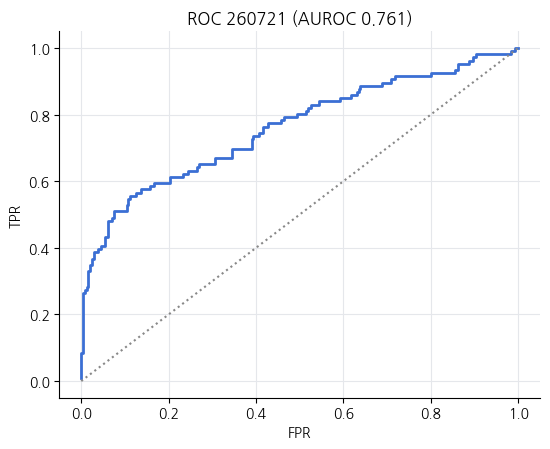

곡선 저장: roc_260721.png


In [36]:
# @title 정답지 채점 (260721 배치)
import csv
import numpy as np

EXT_DIR2 = "/content/drive/MyDrive/260721"
ANSWER_CSV2 = "/content/drive/MyDrive/정답지_260721.csv"
OUT_SCORE_CSV2 = "정답지_260721_점수.csv"
OUT_ROC_PNG2 = "roc_260721.png"

assert os.path.exists(ANSWER_CSV2), f"정답지 CSV 없음: {ANSWER_CSV2}"
assert os.path.isdir(EXT_DIR2), f"이미지 폴더 없음: {EXT_DIR2}"

answers2 = read_answer_csv(ANSWER_CSV2)
print(f"정답지 {len(answers2)}행 로드  ({ANSWER_CSV2})")

ext_paths2 = sorted(p for p in glob.glob(os.path.join(EXT_DIR2, "**", "*"), recursive=True)
                    if p.lower().endswith(IMG_EXTS))
print(f"채점 대상 폴더 {len(ext_paths2)}장  ({EXT_DIR2})")

GRADE_K = BEST_ENS_K if "BEST_ENS_K" in globals() else 1
scores2 = {}
for i, p in enumerate(ext_paths2):
    vs = [die_topvals(mm, p, DEVICE)[:GRADE_K].mean(0)[BIN_IDX].item() for mm in ens_models]
    scores2[os.path.basename(p)] = float(np.mean(vs))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(ext_paths2)}")

with open(OUT_SCORE_CSV2, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "불량점수"])
    for name in sorted(scores2, key=lambda n: -scores2[n]):
        wr.writerow([name, f"{scores2[name]:.6f}"])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_SCORE_CSV2, "/content/drive/MyDrive/" + OUT_SCORE_CSV2)
print(f"\n점수 CSV 저장 완료: {OUT_SCORE_CSV2}  ({len(scores2)}행)")

matched2, unscored2, excluded_cnt2 = [], [], 0
for name, row in answers2.items():
    if name not in scores2:
        unscored2.append(name)
        continue
    target_flag = (row.get("채점대상") or "").strip()
    if target_flag and not target_flag.startswith("예"):
        excluded_cnt2 += 1
        continue
    label = (row.get("라벨") or "").strip()
    if "불량" in label:
        matched2.append((name, scores2[name], 1))
    elif "양품" in label:
        matched2.append((name, scores2[name], 0))
    else:
        excluded_cnt2 += 1

if unscored2:
    print(f"[경고] 정답지에는 있으나 이미지 폴더에 없는 파일 {len(unscored2)}건")

n2 = len(matched2)
assert n2 > 0, "채점 대상과 일치하는 이미지가 없습니다 — 파일명/열 이름 확인"
S2 = np.array([s for _, s, _ in matched2])
Y2 = np.array([y for _, _, y in matched2])
n_bad2 = int(Y2.sum())
prev2 = n_bad2 / n2
print(f"\n채점 대상 {n2}장  (정답지 라벨 기준, 미판정/제외 {excluded_cnt2}건)")
print(f"불량 {n_bad2} / 양품 {n2 - n_bad2}  (불량률 {prev2:.1%})")

order2 = np.argsort(-S2)
Ys2 = Y2[order2]
tp2 = np.cumsum(Ys2)
fp2 = np.cumsum(1 - Ys2)
P2, N2 = int(Ys2.sum()), n2 - int(Ys2.sum())
tpr2 = tp2 / max(P2, 1)
fpr2 = fp2 / max(N2, 1)
auroc2 = float(np.trapz(tpr2, fpr2))

ap2, tpr_, fpr_ = 0.0, 0.0, 0.0
for y in Ys2:
    if y:
        tpr_ += 1
        ap2 += tpr_ / (tpr_ + fpr_)
    else:
        fpr_ += 1
ap2 /= max(P2, 1)

print("\n" + "=" * 78)
print(f"[표준 보고표]  정답지_260721(347장 기준) · {n2}장 · 불량 {n_bad2}장 (π={prev2:.1%})")
print(f"  주지표   AUROC          {auroc2:.3f}")
print(f"  보조지표 AP + π         {ap2:.3f}  (π {prev2:.3f})")
print("  ※ 이 배치는 학습에도 쓰였으니 참고용입니다 — 260731 결과와 나란히 적으세요")
print("=" * 78)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(fpr2, tpr2, color="#3b6fd4", lw=2)
ax.plot([0, 1], [0, 1], ls=":", color="#888")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title(f"ROC 260721 (AUROC {auroc2:.3f})")
ax.grid(color="#e5e7eb")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ROC_PNG2, dpi=130, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_ROC_PNG2, "/content/drive/MyDrive/" + OUT_ROC_PNG2)
print(f"곡선 저장: {OUT_ROC_PNG2}")

In [37]:
# @title [개선 B-0] 개선용 공통 함수 (순위 지표 · 배치 적응 · 이상 탐지 · 융합)
import copy
import time
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import rankdata
from torchvision.models import resnet18, ResNet18_Weights

ADAPT_PATCHES = 384
ADAPT_ALPHA = 1.0
AN_IN = 512
AN_PER_IMG = 96
AN_TOPK = 10
AN_EXCLUDE_TOP = 0.25
AN_BATCH = 8
AN_CHUNK = 16384
FUSE_W_MIL = 0.5
AN_DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32

def auroc_tie(y, s):
    y = np.asarray(y).astype(bool)
    s = np.asarray(s, dtype=np.float64)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))

def tie_blocks(y, s):
    y = np.asarray(y).astype(bool)
    s = np.asarray(s, dtype=np.float64)
    order = np.argsort(-s, kind="mergesort")
    ys, ss = y[order], s[order]
    ends = np.r_[np.flatnonzero(np.diff(ss) != 0), len(ss) - 1]
    return np.cumsum(ys)[ends], ends + 1, ss[ends]

def ap_rank(y, s):
    P = int(np.asarray(y).astype(bool).sum())
    if P == 0:
        return float("nan")
    tp, cnt, _ = tie_blocks(y, s)
    rec = tp / P
    return float(np.sum((rec - np.r_[0.0, rec[:-1]]) * (tp / cnt)))

def rank01(s):
    s = np.asarray(s, dtype=np.float64)
    return (rankdata(s) - 0.5) / len(s)

def robust_z(v):
    v = np.asarray(v, dtype=np.float64)
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826 + 1e-9
    return (v - med) / mad

def fuse_rank(a, b, w=FUSE_W_MIL):
    tie = np.tanh((w * robust_z(a) + (1 - w) * robust_z(b)) / 10.0)
    return w * rank01(a) + (1 - w) * rank01(b) + 1e-6 * tie

def boot_delta_auc(y, s_new, s_old, n=1000, seed=0):
    y = np.asarray(y).astype(bool)
    rs = np.random.RandomState(seed)
    pos, neg = np.flatnonzero(y), np.flatnonzero(~y)
    d = []
    for _ in range(n):
        idx = np.concatenate([rs.choice(pos, len(pos)), rs.choice(neg, len(neg))])
        d.append(auroc_tie(y[idx], np.asarray(s_new)[idx]) - auroc_tie(y[idx], np.asarray(s_old)[idx]))
    d = np.sort(d)
    return float(d[int(0.025 * n)]), float(d[int(0.975 * n) - 1])

def standard_report(title, y, s):
    y = np.asarray(y).astype(int)
    s = np.asarray(s, dtype=np.float64)
    n, P = len(y), int(y.sum())
    ss = np.sort(s)[::-1]
    tp_b, cnt_b, _ = tie_blocks(y, s)
    auc, apv, pi = auroc_tie(y, s), ap_rank(y, s), P / max(n, 1)

    def top(frac):
        cut = ss[max(1, int(round(frac * n))) - 1]
        sel = s >= cut
        k, det = int(sel.sum()), int(y[sel].sum())
        return k, det, P - det, k - det, det / k, min(P, k) / k

    def need(rate):
        ok = np.flatnonzero(tp_b >= rate * P)
        return int(cnt_b[ok[0]]) if len(ok) else None

    worst = int((s >= s[y == 1].min()).sum()) if P else None
    print("=" * 84)
    print(f"[표준 보고표]  {title} · {n}장 · 불량 {P}장 (π={pi:.1%})")
    print(f"  주지표   AUROC           {auc:.3f}")
    print(f"  보조지표 AP + π          {apv:.3f}  (π {pi:.3f})")
    for tag, frac in (("①  상위 10%", 0.10), ("②  상위 25%", 0.25)):
        k, det, miss, fa, prec, pmax = top(frac)
        print(f"  작동점{tag} ({k}장)  검출률 {det / max(P, 1):.3f} ({det}/{P}) · 놓침 {miss}장 · "
              f"오검출 {fa}장 · 정밀도 {prec:.3f} (최대 {pmax:.3f})")
    for tag, rate in (("③  검출률 90%", 0.90), ("   검출률 95%", 0.95)):
        m = need(rate)
        print(f"  작동점{tag}  " + (f"{m}장 ({m / n:.1%})" if m else "미달성"))
    print(f"  작동점④  최저 순위(진단) {worst}등 / {n}장")
    print("=" * 84)
    return {"AUROC": auc, "AP": apv, "pi": pi, "n": n, "P": P}

def patch_pool(paths, n_total, seed=0):
    rng = np.random.RandomState(seed)
    paths = list(paths)
    n_img = min(len(paths), max(16, n_total // 8))
    sel = rng.choice(len(paths), size=n_img, replace=False)
    per = int(np.ceil(n_total / n_img))
    xs = []
    for i in sel:
        img = load_padded(paths[i])
        w, h = img.size
        full = eval_tf(img)
        pos = all_positions(paths[i], w, h)
        for j in rng.choice(len(pos), size=min(per, len(pos)), replace=False):
            x, y = pos[j]
            xs.append(full[:, y:y + PATCH, x:x + PATCH])
    xs = torch.stack(xs)
    if len(xs) > n_total:
        xs = xs[torch.from_numpy(rng.permutation(len(xs))[:n_total])]
    return xs

@torch.no_grad()
def adapt_bn(model, src_x, tgt_x, alpha=ADAPT_ALPHA):
    net = copy.deepcopy(model).to(DEVICE).eval()
    bns = [m for m in net.modules() if isinstance(m, nn.BatchNorm2d)]
    n_s = len(src_x)
    new_stats = {}

    def make_fwd(bn):
        def fwd(x):
            xs, xt = x[:n_s], x[n_s:]
            ms, vs = xs.mean((0, 2, 3)), xs.var((0, 2, 3), unbiased=False)
            mt, vt = xt.mean((0, 2, 3)), xt.var((0, 2, 3), unbiased=False)
            m0, v0 = bn.running_mean, bn.running_var
            ratio = torch.sqrt((vt + bn.eps) / (vs + bn.eps)).clamp(0.2, 5.0)
            nm = m0 + alpha * (mt - ratio * (ms - m0) - m0)
            nv = v0 + alpha * (v0 * ratio ** 2 - v0)
            new_stats[id(bn)] = (nm, nv)
            ys = F.batch_norm(xs, m0, v0, bn.weight, bn.bias, False, 0.0, bn.eps)
            yt = F.batch_norm(xt, nm, nv, bn.weight, bn.bias, False, 0.0, bn.eps)
            return torch.cat([ys, yt], 0)
        return fwd

    for bn in bns:
        bn.forward = make_fwd(bn)
    net(torch.cat([src_x, tgt_x], 0).to(DEVICE))
    for bn in bns:
        del bn.forward
        nm, nv = new_stats[id(bn)]
        bn.running_mean.copy_(nm)
        bn.running_var.copy_(nv)
    return net.eval()

@torch.no_grad()
def mil_scores(models, paths, k=None, tta=False, every=500, tag=""):
    k = k or (GRADE_K if "GRADE_K" in globals() else 1)
    out = np.zeros(len(paths))
    t0 = time.time()
    for i, p in enumerate(paths):
        vs = [die_topvals(mm, p, DEVICE, tta=tta)[:k].mean(0)[BIN_IDX].item() for mm in models]
        out[i] = float(np.mean(vs))
        if every and (i + 1) % every == 0:
            print(f"  {tag} MIL {i + 1}/{len(paths)} ({time.time() - t0:.0f}초)", flush=True)
    return out

an_net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(DEVICE).eval()
for _q in an_net.parameters():
    _q.requires_grad_(False)
AN_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
AN_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

def an_box(w, h):
    return (int(round(w * 0.06)), int(round(h * 0.06)), int(round(w * 0.94)), int(round(h * 0.94)))

def an_load(paths):
    arr = []
    for p in paths:
        with Image.open(p) as im0:
            im = im0.convert("RGB")
        im = im.crop(an_box(*im.size)).resize((AN_IN, AN_IN), Image.BILINEAR)
        arr.append(torch.from_numpy(np.asarray(im, dtype=np.float32) / 255.0).permute(2, 0, 1))
    return (torch.stack(arr).to(DEVICE) - AN_MEAN) / AN_STD

@torch.no_grad()
def an_feats(paths):
    x = an_load(paths)
    x = an_net.maxpool(an_net.relu(an_net.bn1(an_net.conv1(x))))
    f2 = an_net.layer2(an_net.layer1(x))
    f3 = an_net.layer3(f2)
    f2 = F.avg_pool2d(f2, 3, 1, 1)
    f3 = F.interpolate(F.avg_pool2d(f3, 3, 1, 1), size=f2.shape[-2:], mode="bilinear", align_corners=False)
    f = torch.cat([f2, f3], 1)
    b, c, h, w = f.shape
    return F.normalize(f.permute(0, 2, 3, 1).reshape(b, h * w, c), dim=2)

@torch.no_grad()
def an_bank(paths, per_img=AN_PER_IMG, seed=0):
    g = torch.Generator().manual_seed(seed)
    parts = []
    for i in range(0, len(paths), AN_BATCH):
        f = an_feats(paths[i:i + AN_BATCH])
        b, n, c = f.shape
        idx = torch.stack([torch.randperm(n, generator=g)[:per_img] for _ in range(b)]).to(f.device)
        parts.append(torch.gather(f, 1, idx.unsqueeze(-1).expand(-1, -1, c)).reshape(-1, c))
    return torch.cat(parts).to(AN_DTYPE)

@torch.no_grad()
def an_score(paths, bank, topk=AN_TOPK, every=1000, tag=""):
    out = []
    t0 = time.time()
    next_print = every
    for i in range(0, len(paths), AN_BATCH):
        f = an_feats(paths[i:i + AN_BATCH]).to(AN_DTYPE)
        for q in f:
            best = torch.full((q.shape[0],), -2.0, device=q.device)
            for j in range(0, bank.shape[0], AN_CHUNK):
                best = torch.maximum(best, (q @ bank[j:j + AN_CHUNK].T).max(1).values.float())
            d = torch.sqrt(torch.clamp(2 - 2 * best, min=0))
            out.append(float(d.topk(min(topk, len(d))).values.mean()))
        if every and len(out) >= next_print:
            print(f"  {tag} 이상점수 {len(out)}/{len(paths)} ({time.time() - t0:.0f}초)", flush=True)
            next_print += every
    return np.array(out)

def an_transductive(paths, guide=None, exclude=AN_EXCLUDE_TOP, seed=0, tag=""):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(paths))
    folds = [idx[0::2], idx[1::2]]
    out = np.zeros(len(paths))
    for a in range(2):
        fit, tst = folds[1 - a], folds[a]
        if guide is not None and exclude > 0:
            gv = np.asarray(guide)[fit]
            keep = fit[gv <= np.quantile(gv, 1 - exclude)]
        else:
            keep = fit
        bank = an_bank([paths[i] for i in keep], seed=seed + a)
        out[tst] = robust_z(an_score([paths[i] for i in tst], bank, tag=f"{tag} 묶음{a + 1}/2"))
        del bank
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    return out

def train_bank_default(n_img=300, seed=0):
    excl = set(globals().get("ext_paths2", [])) | set(globals().get("add_good", [])) | set(globals().get("add_bad", []))
    good = [p for p, g in tr_items if CLASS_NAMES[g] == "양품" and p not in excl]
    official = [p for p in good if p in globals().get("OFFICIAL_PATHS", set())]
    src = official if len(official) >= n_img else good
    rs_ = np.random.RandomState(seed)
    imgs = [src[i] for i in rs_.choice(len(src), min(n_img, len(src)), replace=False)]
    return an_bank(imgs, seed=seed), imgs, (src is official)

def method_scores(method, paths, tta=False, seed=0, src_x=None, bank=None, tag=""):
    use_adapt, use_mil, use_anom = "적응" in method, "MIL" in method, "이상" in method
    anom_kind = "학습" if "학습" in method else "배치"
    if method.startswith("기존"):
        tta = TTA_EVAL
    comp = {}
    if use_mil or (use_anom and anom_kind == "배치"):
        models = ens_models
        if use_adapt:
            if src_x is None:
                src_x = patch_pool([p for p, _ in tr_items], ADAPT_PATCHES, seed=seed)
            tgt_x = patch_pool(paths, ADAPT_PATCHES, seed=seed + 1)
            models = [adapt_bn(mm, src_x, tgt_x) for mm in ens_models]
        comp["mil"] = mil_scores(models, paths, tta=tta, tag=tag)
        del models
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    if use_anom:
        if anom_kind == "배치":
            comp["anom"] = an_transductive(paths, guide=comp.get("mil"), seed=seed, tag=tag)
        else:
            if bank is None:
                bank = train_bank_default(seed=seed)[0]
            comp["anom"] = an_score(paths, bank, tag=tag)
    if use_mil and use_anom:
        final = fuse_rank(comp["mil"], comp["anom"])
    else:
        final = comp["mil"] if use_mil else comp["anom"]
    return np.asarray(final, dtype=np.float64), comp

print(f"배치 적응 패치 {ADAPT_PATCHES}장×2 · 이상탐지 입력 {AN_IN} · 이미지당 기억 패치 {AN_PER_IMG} · "
      f"상위 {AN_TOPK}칸 평균 · 기억에서 MIL 상위 {AN_EXCLUDE_TOP:.0%} 제외 · 융합 MIL 가중치 {FUSE_W_MIL}")

배치 적응 패치 384장×2 · 이상탐지 입력 512 · 이미지당 기억 패치 96 · 상위 10칸 평균 · 기억에서 MIL 상위 25% 제외 · 융합 MIL 가중치 0.5


In [38]:
# @title [개선 B] 정답지 기준 방법 비교 (260731 · 260721) — MIL · 배치 적응 · 이상 탐지 · 융합
import csv
import time
import numpy as np

CMP_TTA = False
CMP_SEED = 0
CMP_BANK_IMG = 300
CMP_BOOT = 1000
CMP_OUT = "개선_방법비교_260731_260721.csv"
SCORE_OUT_731 = "정답지_260731_점수_개선.csv"
CAND_3609 = ["MIL (TTA 끔)"]

assert "method_scores" in globals(), "[개선 B-0] 셀을 먼저 실행하세요"
assert "ens_models" in globals() and "matched" in globals(), "'정답지 채점 (공식 배치)' 셀을 먼저 실행하세요"
assert "matched2" in globals(), "'정답지 채점 (260721 배치)' 셀을 먼저 실행하세요"

def sheet_of(matched_list, paths_all, base_scores):
    paths_all = sorted(paths_all)
    names_all = [os.path.basename(p) for p in paths_all]
    lab = {n: int(yy) for n, _, yy in matched_list}
    graded = np.array([i for i, n in enumerate(names_all) if n in lab], dtype=int)
    y = np.array([lab[names_all[i]] for i in graded], dtype=int)
    base = np.array([base_scores[n] for n in names_all], dtype=np.float64)
    return names_all, paths_all, graded, y, base

t_all = time.time()
sheets = {"260731": sheet_of(matched, ext_paths, scores),
          "260721": sheet_of(matched2, ext_paths2, scores2)}

SRC_PATCHES = patch_pool([p for p, _ in tr_items], ADAPT_PATCHES, seed=CMP_SEED)
TRAIN_BANK, bank_imgs, bank_official = train_bank_default(CMP_BANK_IMG, seed=CMP_SEED)
print(f"배치 적응 기준 패치 {len(SRC_PATCHES)}장 (학습셋) · 이상탐지 기억 {len(bank_imgs)}장 → 패치 {len(TRAIN_BANK):,}개"
      f" ({'정답지 양품' if bank_official else '학습 양품'}, 260721 이미지는 제외)", flush=True)

results = {}
for tag, (names, paths, graded, y, base) in sheets.items():
    print(f"\n[{tag}] 폴더 {len(paths)}장 전체로 배치 통계 · 채점은 정답지 {len(graded)}장 (불량 {int(y.sum())}장)", flush=True)
    s = {"기존 MIL (셀33·34)": base}
    s["MIL (TTA 끔)"] = mil_scores(ens_models, paths, tta=CMP_TTA, tag=tag)
    tgt = patch_pool(paths, ADAPT_PATCHES, seed=CMP_SEED + 1)
    adapted = [adapt_bn(mm, SRC_PATCHES, tgt) for mm in ens_models]
    s["MIL + 배치적응"] = mil_scores(adapted, paths, tta=CMP_TTA, tag=tag + " 적응")
    del adapted
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    s["이상탐지 (학습 양품)"] = an_score(paths, TRAIN_BANK, tag=tag)
    an_plain = an_transductive(paths, guide=s["MIL (TTA 끔)"], seed=CMP_SEED, tag=tag)
    an_adapt = an_transductive(paths, guide=s["MIL + 배치적응"], seed=CMP_SEED, tag=tag + " 적응")
    s["이상탐지 (배치 자체)"] = an_plain
    s["융합: MIL + 이상(학습)"] = fuse_rank(s["MIL (TTA 끔)"], s["이상탐지 (학습 양품)"])
    s["융합: MIL + 이상(배치)"] = fuse_rank(s["MIL (TTA 끔)"], an_plain)
    s["융합: MIL적응 + 이상(배치)"] = fuse_rank(s["MIL + 배치적응"], an_adapt)
    results[tag] = (names, graded, y, s)
    print(f"  [{tag}] 완료 ({time.time() - t_all:.0f}초 경과)", flush=True)

methods = list(results["260731"][3].keys())
table = {}
for m in methods:
    row = {}
    for tag in ("260731", "260721"):
        _, graded, y, s = results[tag]
        row[tag] = (auroc_tie(y, s[m][graded]), ap_rank(y, s[m][graded]), float(y.mean()))
    table[m] = row
CMP_TABLE = table

base_name = "기존 MIL (셀33·34)"
_, g731, y731, s731 = results["260731"]
BEST_3609 = max(CAND_3609, key=lambda m: (table[m]["260731"][0], table[m]["260721"][0]))
best_all = max(methods, key=lambda m: (table[m]["260731"][0], table[m]["260721"][0]))

print("\n" + "=" * 106)
pi1, pi2 = table[base_name]["260731"][2], table[base_name]["260721"][2]
print(f"{'방법':26s} | {'260731 AUROC':>12s} {'AP(π ' + format(pi1, '.3f') + ')':>13s} {'ΔAUROC 95%CI':>20s}"
      f" | {'260721 AUROC':>12s} {'AP(π ' + format(pi2, '.3f') + ')':>13s}")
print("-" * 106)
for m in methods:
    a1, p1, _ = table[m]["260731"]
    a2, p2, _ = table[m]["260721"]
    if m == base_name:
        ci = "기준"
    else:
        lo, hi = boot_delta_auc(y731, s731[m][g731], s731[base_name][g731], n=CMP_BOOT, seed=CMP_SEED)
        ci = f"{a1 - table[base_name]['260731'][0]:+.3f} [{lo:+.3f},{hi:+.3f}]"
    mark = "  ← 3609 적용" if m == BEST_3609 else ""
    print(f"{m:26s} | {a1:>12.3f} {p1:>13.3f} {ci:>20s} | {a2:>12.3f} {p2:>13.3f}{mark}")
print("=" * 106)
print("· 260721 은 MIL 학습에 쓰인 배치라 MIL 계열 값은 부풀려져 있습니다. 이상탐지는 라벨을 쓰지 않고, "
      "학습 양품 기억에서도 260721 이미지를 뺐습니다.")
print(f"· ΔAUROC 95%CI(불량 {int(y731.sum())}장 부트스트랩)가 0 을 포함하면 기존과 통계적으로 구분되지 않습니다.")
print("· '배치적응' · '이상탐지 (배치 자체)' 는 채점 배치 이미지만으로(라벨 없이) 기준을 잡는 세트 내 보정입니다 — "
      "보고서에 그대로 명시하세요.")
print(f"· 3609 에 적용할 방식: {BEST_3609} — 제출한 가중치(.pt)만으로 그대로 재현되도록, 배치 통계나 이상탐지 없이 "
      f"학습된 앙상블의 예측값만 씁니다.")
if best_all != BEST_3609:
    a_best, a_sel = table[best_all]["260731"][0], table[BEST_3609]["260731"][0]
    print(f"· 정답지 기준 전체 최고는 {best_all} (260731 AUROC {a_best:.3f} vs {BEST_3609} {a_sel:.3f})이지만, "
          f"배치 통계나 이상탐지에 기대는 방식은 제출한 가중치만으로 재현되지 않아 3609엔 쓰지 않습니다.")

std_best = standard_report(f"정답지_260731 · {BEST_3609}", y731, s731[BEST_3609][g731])

with open(CMP_OUT, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["방법", "260731_AUROC", "260731_AP", "260731_pi", "260721_AUROC", "260721_AP", "260721_pi", "3609적용"])
    for m in methods:
        wr.writerow([m] + [f"{v:.4f}" for v in table[m]["260731"]] + [f"{v:.4f}" for v in table[m]["260721"]]
                    + ["예" if m == BEST_3609 else ""])
names731 = results["260731"][0]
best731 = s731[BEST_3609]
with open(SCORE_OUT_731, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["파일명", "불량점수"])
    for i in np.argsort(-best731, kind="mergesort"):
        wr.writerow([names731[i], f"{best731[i]:.6f}"])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(CMP_OUT, "/content/drive/MyDrive/" + CMP_OUT)
    shutil.copy(SCORE_OUT_731, "/content/drive/MyDrive/" + SCORE_OUT_731)
print(f"저장: {CMP_OUT} · {SCORE_OUT_731} ({len(names731)}행)  (총 {time.time() - t_all:.0f}초)")

배치 적응 기준 패치 384장 (학습셋) · 이상탐지 기억 300장 → 패치 28,800개 (학습 양품, 260721 이미지는 제외)

[260731] 폴더 788장 전체로 배치 통계 · 채점은 정답지 788장 (불량 118장)
  260731 MIL 500/788 (76초)
  260731 적응 MIL 500/788 (77초)
  [260731] 완료 (339초 경과)

[260721] 폴더 347장 전체로 배치 통계 · 채점은 정답지 347장 (불량 106장)
  [260721] 완료 (492초 경과)

방법                         | 260731 AUROC   AP(π 0.150)         ΔAUROC 95%CI | 260721 AUROC   AP(π 0.305)
----------------------------------------------------------------------------------------------------------
기존 MIL (셀33·34)            |        0.669         0.345                   기준 |        0.761         0.684
MIL (TTA 끔)                |        0.651         0.358 -0.018 [-0.053,+0.015] |        0.706         0.625
MIL + 배치적응                 |        0.652         0.352 -0.017 [-0.053,+0.018] |        0.702         0.624
이상탐지 (학습 양품)               |        0.772         0.489 +0.103 [+0.034,+0.169] |        0.620         0.521
이상탐지 (배치 자체)               |        0.732         0.514 +0.063 [-0.012

In [39]:
# @title 3609 배치 원본 크롭 (크롭표 기준)
import csv
import unicodedata

def resolve_drive_path(path):
    if os.path.exists(path):
        return path
    parent, name = os.path.split(path)
    if not os.path.isdir(parent):
        return path
    target = unicodedata.normalize("NFC", name)
    for entry in os.listdir(parent):
        if unicodedata.normalize("NFC", entry) == target:
            return os.path.join(parent, entry)
    return path

if not os.path.isdir("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")

CROP_LIST_CSV = resolve_drive_path("/content/drive/MyDrive/3609_크롭표.csv")
RAW_DIR = resolve_drive_path("/content/drive/MyDrive/3609_원본")
CROP_OUT_DIR = "/content/drive/MyDrive/3609"

assert os.path.exists(CROP_LIST_CSV), f"크롭표 없음: {CROP_LIST_CSV}"
assert os.path.isdir(RAW_DIR), f"원본 폴더 없음: {RAW_DIR}"
os.makedirs(CROP_OUT_DIR, exist_ok=True)

raw_index = {}
for p in glob.glob(os.path.join(RAW_DIR, "**", "*"), recursive=True):
    if p.lower().endswith(IMG_EXTS):
        key = unicodedata.normalize("NFC", os.path.splitext(os.path.basename(p))[0])
        raw_index.setdefault(key, p)
print(f"원본 파일 {len(raw_index)}개 인식  ({RAW_DIR})")

rows = list(csv.DictReader(open(CROP_LIST_CSV, encoding="utf-8-sig")))
print(f"크롭표 {len(rows)}행 로드  ({CROP_LIST_CSV})")

crop_name_map = {}
done = skipped = 0
missing_ids = []
for row in rows:
    sid = row["일련번호"].strip()
    key4 = f"{int(sid):04d}"
    names = [unicodedata.normalize("NFC", row.get(k, "").strip())
             for k in ("대표", "동일1", "동일2", "동일3")]
    matched_name = next((n for n in names if n and n in raw_index), None)
    src = raw_index[matched_name] if matched_name else None
    crop_name_map[key4] = matched_name or names[0]
    if src is None:
        skipped += 1
        missing_ids.append(sid)
        continue
    x, y, w, h = (int(row["크롭_x"]), int(row["크롭_y"]),
                  int(row["크롭_w"]), int(row["크롭_h"]))
    out_path = os.path.join(CROP_OUT_DIR, f"{key4}.jpg")
    if os.path.exists(out_path):
        done += 1
        continue
    img = Image.open(src).convert("RGB")
    img.crop((x, y, x + w, y + h)).save(out_path, quality=95)
    done += 1

print(f"크롭 완료 {done}장 | 원본 못 찾음 {skipped}장  ({CROP_OUT_DIR})")
if missing_ids:
    print(f"원본 없는 일련번호 예시: {missing_ids[:10]}{' ...' if len(missing_ids) > 10 else ''}")

원본 파일 3625개 인식  (/content/drive/MyDrive/3609_원본)
크롭표 3609행 로드  (/content/drive/MyDrive/3609_크롭표.csv)
크롭 완료 3609장 | 원본 못 찾음 0장  (/content/drive/MyDrive/3609)


In [40]:
# @title 신규 배치 채점 (라벨 없음 · 상위 25% 선별)
import csv
import numpy as np

BATCH_NAME = "3609"
NEW_BATCH_DIR = "/content/drive/MyDrive/%s" % BATCH_NAME
OUT_SCORE_CSV3 = "%s_점수.csv" % BATCH_NAME
OUT_TOP_CSV = "%s_상위25.csv" % BATCH_NAME
TOP_FRAC = 0.25
TOP_N = 900

assert os.path.isdir(NEW_BATCH_DIR), (
    f"이미지 폴더 없음: {NEW_BATCH_DIR} — 크롭 셀을 먼저 실행하세요")

ext_paths3 = sorted(p for p in glob.glob(os.path.join(NEW_BATCH_DIR, "**", "*"), recursive=True)
                    if p.lower().endswith(IMG_EXTS))
print(f"신규 배치 폴더 {len(ext_paths3)}장  ({NEW_BATCH_DIR})")
assert ext_paths3, "폴더는 있으나 이미지가 없습니다"

def grid_patch_stack(path):
    img = load_padded(path)
    w, h = img.size
    full = eval_tf(img)
    return torch.stack([full[:, y:y + PATCH, x:x + PATCH]
                        for x, y in die_grid(w, h, stride=STRIDE)])

@torch.no_grad()
def grid_patch_probs(model, path, device, batch=256, tta=False):
    xs = grid_patch_stack(path)
    variants = FLIPS if tta else ((),)
    acc = None
    for fl in variants:
        z = torch.flip(xs, list(fl)) if fl else xs
        o = _forward(model, z, device, batch)
        acc = o if acc is None else acc + o
    return acc / len(variants)

@torch.no_grad()
def grid_topvals(model, path, device, kmax=KMAX, batch=256, tta=None):
    use = TTA_EVAL if tta is None else tta
    o = grid_patch_probs(model, path, device, batch, tta=use)
    return o.topk(min(kmax, len(o)), 0).values

GRADE_K = BEST_ENS_K if "BEST_ENS_K" in globals() else 1
print(f"앙상블 {len(ens_models)}개로 채점 (k={GRADE_K}, val 기준 선택된 값) · grid-only 패치 "
      f"(이 배치 크기에 안 맞는 ROI/메사 좌표는 쓰지 않음) · 정답지 없음 — AUROC/ROC/PR은 계산하지 않습니다")

scores3 = {}
for i, p in enumerate(ext_paths3):
    vs = [grid_topvals(mm, p, DEVICE)[:GRADE_K].mean(0)[BIN_IDX].item() for mm in ens_models]
    sid = os.path.splitext(os.path.basename(p))[0]
    scores3[sid] = float(np.mean(vs))
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{len(ext_paths3)}")

order3 = sorted(scores3, key=lambda n: -scores3[n])
n3 = len(order3)
k_top = TOP_N if TOP_N else max(1, int(round(TOP_FRAC * n3)))
tag_top = "상위%d장" % k_top

with open(OUT_SCORE_CSV3, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["일련번호", "불량점수", "순위", tag_top])
    for rank, sid in enumerate(order3, 1):
        wr.writerow([int(sid), f"{scores3[sid]:.6f}", rank, "예" if rank <= k_top else ""])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_SCORE_CSV3, "/content/drive/MyDrive/" + OUT_SCORE_CSV3)
print(f"\n전체 점수 CSV 저장 완료: {OUT_SCORE_CSV3}  ({n3}행)")

with open(OUT_TOP_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["일련번호", "불량점수", "순위"])
    for rank, sid in enumerate(order3[:k_top], 1):
        wr.writerow([int(sid), f"{scores3[sid]:.6f}", rank])
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(OUT_TOP_CSV, "/content/drive/MyDrive/" + OUT_TOP_CSV)

vals3 = np.array(list(scores3.values()))
thr_top = scores3[order3[k_top - 1]]
print(f"{tag_top} 선별 CSV 저장 완료: {OUT_TOP_CSV}  ({k_top}장, 점수 {thr_top:.4f} 이상)")
print(f"점수 분포 — 최소 {vals3.min():.4f} / 중앙값 {np.median(vals3):.4f} / 최대 {vals3.max():.4f}")
print("포셈 판정이 회신되면 그 결과를 정답지_*.csv 형식으로 저장한 뒤, "
      "'정답지 채점' 셀과 같은 방식으로 AUROC/ROC/PR을 계산할 수 있습니다")

신규 배치 폴더 3609장  (/content/drive/MyDrive/3609)
앙상블 3개로 채점 (k=8, val 기준 선택된 값) · grid-only 패치 (이 배치 크기에 안 맞는 ROI/메사 좌표는 쓰지 않음) · 정답지 없음 — AUROC/ROC/PR은 계산하지 않습니다
  200/3609
  400/3609
  600/3609
  800/3609
  1000/3609
  1200/3609
  1400/3609
  1600/3609
  1800/3609
  2000/3609
  2200/3609
  2400/3609
  2600/3609
  2800/3609
  3000/3609
  3200/3609
  3400/3609
  3600/3609

전체 점수 CSV 저장 완료: 3609_점수.csv  (3609행)
상위900장 선별 CSV 저장 완료: 3609_상위25.csv  (900장, 점수 0.1268 이상)
점수 분포 — 최소 0.0852 / 중앙값 0.1108 / 최대 0.2165
포셈 판정이 회신되면 그 결과를 정답지_*.csv 형식으로 저장한 뒤, '정답지 채점' 셀과 같은 방식으로 AUROC/ROC/PR을 계산할 수 있습니다


학습 기준 120장 · 학습끼리 정합 NCC 중앙값 0.934 · 메사 반지름 117.8px → 2.95px/µm (패드 80µm 기준)
3609 크롭 3609장 · 크기 {(339, 450): 200}
정합 후보 상위 (NCC 중앙값):
  등방 · 270°+반전  · 배율 3.921  → 0.628
  등방 · 270°+반전  · 배율 4.247  → 0.592
  등방 · 270°+반전  · 배율 4.081  → 0.572
  등방 · 270°+반전  · 배율 3.692  → 0.569
  등방 · 270°+반전  · 배율 4.000  → 0.442
선택: 270°+반전 · 배율 ×3.921  → 3609 원본 1px = 학습 3.92px · 5µm 결함이 학습 14.7px ↔ 3609 원본 3.8px
색 보정(배치) BGR 평균 3609 [0. 0. 0.] → 학습 [  1.1 104.6 133.8] · 표준편차 [0. 0. 0.] → [ 1.8 64.7 71.1]
  3609 정합 500/3609 (43초)
  3609 정합 1000/3609 (85초)
  3609 정합 1500/3609 (128초)
  3609 정합 2000/3609 (172초)
  3609 정합 2500/3609 (214초)
  3609 정합 3000/3609 (255초)
  3609 정합 3500/3609 (298초)

정합 완료 3609장 → /content/3609_reg
  정합 NCC 중앙값 0.195 (학습끼리 0.934) · 하위 5% 0.114
  [주의] 정합 신뢰도가 낮습니다 — 아래 그림에서 메사(빨강)·ROI(초록)가 제자리인지 확인하고, 틀리면 REG_FORCE = ("등방", 방향번호 0~7, 배율) 로 직접 지정하세요
  정합 후 메사 검출 0/3609장

[3609 정합 후]  항목          중앙값       5%      95%       폭
중심 x      522.0    522.0    522.0     0.0
중심 y      277.0

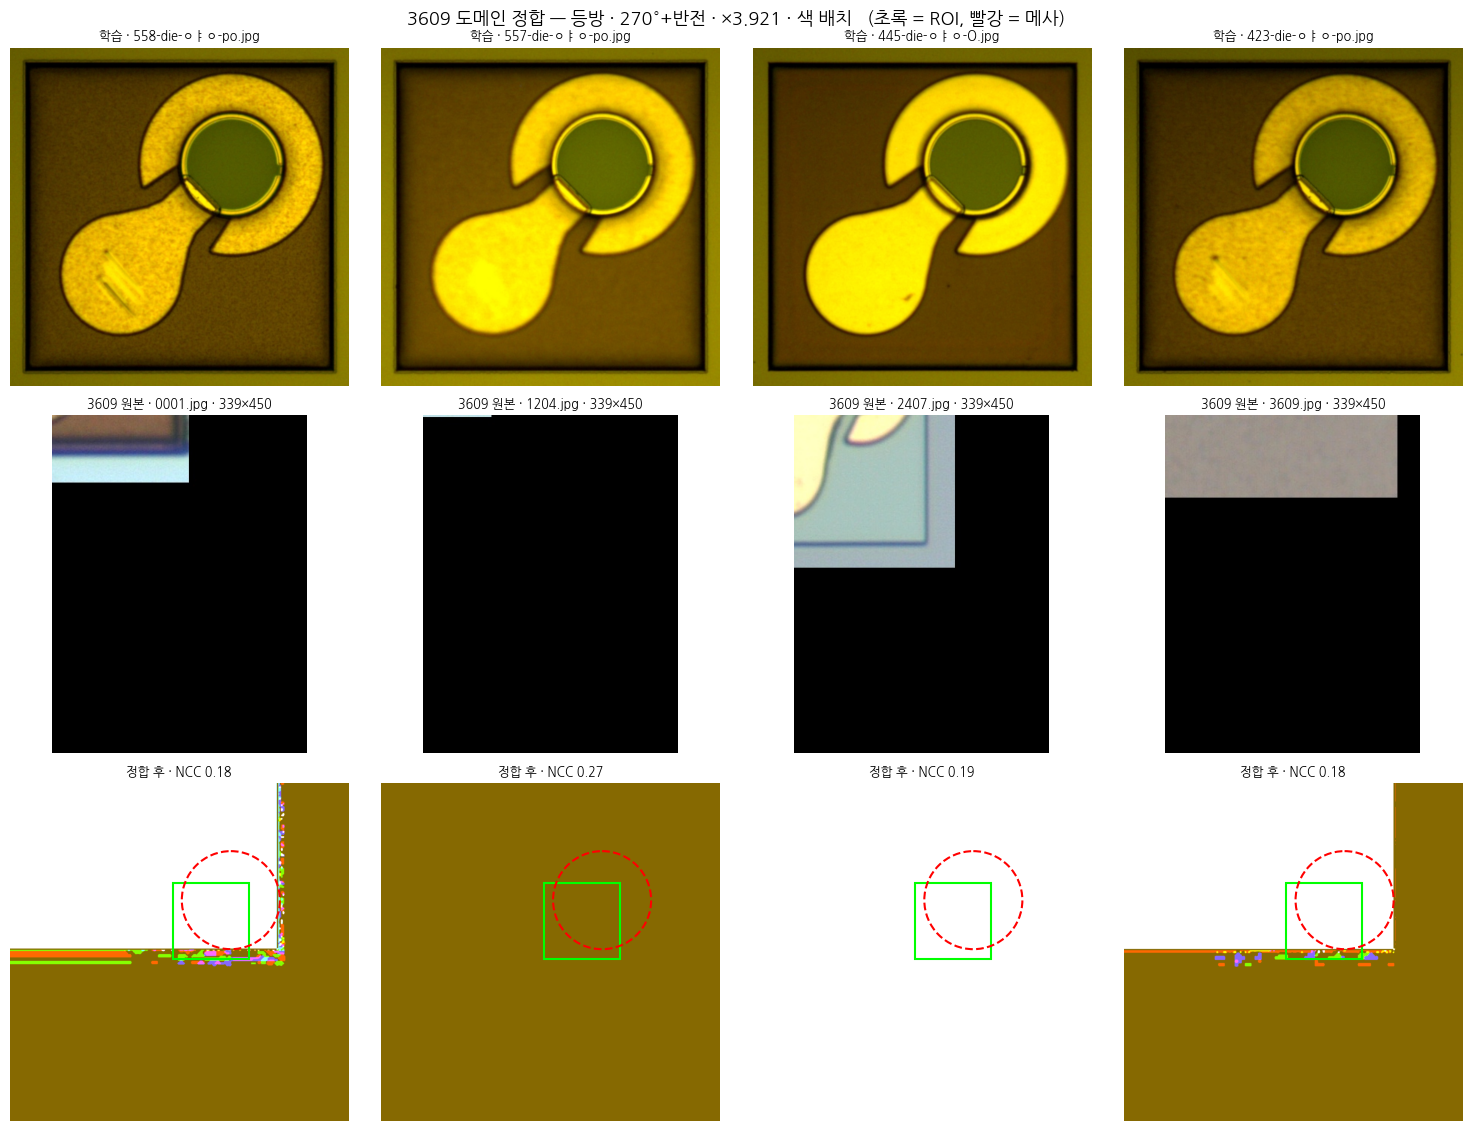


[모의 검증] 260731 확정 이미지를 3609 조건(배율 · 방향 · 크기 · 색)으로 바꿔서 채점
  모의 정합 500/788 (41초)
  모의 원본 MIL 500/788 (77초)
  모의 정합 MIL 500/788 (71초)
  모의 선택방식 MIL 500/788 (71초)
[모의 검증] 260731 788장 · 불량 118장 · TTA 끔
  원본 800×800 · MIL                             AUROC 0.651
  3609식 그대로 (기존 셀36 방식) · MIL                  AUROC 0.500
  3609식 → 정합 후 · MIL                           AUROC 0.500
  3609식 → 정합 후 · 이상탐지 (배치 자체)                  AUROC 0.500
  자동 정합 결과: 등방 · 그대로 · ×0.710   (만든 조건: 270°+반전 · ×3.921/3.921)
(총 949초)


In [41]:
# @title [개선 C] 3609 도메인 정합 (배율 · 방향 · 위치 · 색) + 260731 모의 검증
import cv2
import csv
import json
import time
import numpy as np
import matplotlib.patches as mpatches
from collections import Counter

REG_SRC_DIR = "/content/drive/MyDrive/3609"
REG_DIR = "/content/3609_reg"
REG_PREFIX = "3609_"
REG_FRAME = 800
REG_BOX = (48, 48, 752, 752)
REG_DS = 4
REG_N_REF = 120
REG_N_PROBE = 60
REG_SCALE_MIN, REG_SCALE_MAX, REG_SCALE_N = 0.8, 4.0, 17
REG_PER_IMAGE_SCALE = True
REG_SCALE_SEARCH_FRAC = 0.15
REG_SCALE_SEARCH_N = 5
REG_MIN_NCC_FRAC = 0.5
REG_FORCE = None
COLOR_MODE = "배치"
SIM_CHECK = True
SIM_DIR = "/content/sim_260731"
REG_SEED = 0
REG_FIG = "3609_정합_확인.png"
PAD_UM = 80.0
K_NAMES = ["그대로", "90°", "180°", "270°", "좌우반전", "90°+반전", "180°+반전", "270°+반전"]

assert "method_scores" in globals(), "[개선 B-0] 셀을 먼저 실행하세요"
assert os.path.isdir(REG_SRC_DIR), f"3609 크롭 폴더 없음: {REG_SRC_DIR} — '3609 배치 원본 크롭' 셀을 먼저 실행하세요"

def read_bgr(path):
    im = cv2.imread(path, cv2.IMREAD_COLOR)
    if im is None:
        with Image.open(path) as p0:
            im = cv2.cvtColor(np.asarray(p0.convert("RGB")), cv2.COLOR_RGB2BGR)
    return im

def img_size(path):
    with Image.open(path) as im:
        return im.size

def gray32(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

def grad_norm(g):
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    m = cv2.magnitude(gx, gy)
    return m / (float(m.mean()) + 1e-6)

def dihedral(img, k):
    out = np.rot90(img, k % 4)
    if k >= 4:
        out = out[:, ::-1]
    return np.ascontiguousarray(out)

def inv_dihedral(img, k):
    out = img[:, ::-1] if k >= 4 else img
    return np.ascontiguousarray(np.rot90(out, -(k % 4)))

def build_template(paths):
    acc = None
    for p in paths:
        g = cv2.resize(gray32(read_bgr(p)), (REG_FRAME // REG_DS, REG_FRAME // REG_DS), interpolation=cv2.INTER_AREA)
        gm = grad_norm(g)
        acc = gm if acc is None else acc + gm
    t = acc / len(paths)
    x0, y0, x1, y1 = [v // REG_DS for v in REG_BOX]
    return np.ascontiguousarray(t[y0:y1, x0:x1]).astype(np.float32)

def sub_peak(res, lx, ly):
    fx, fy = float(lx), float(ly)
    if 0 < lx < res.shape[1] - 1:
        a, b, c = res[ly, lx - 1], res[ly, lx], res[ly, lx + 1]
        den = a - 2 * b + c
        if den < 0:
            fx += float(np.clip(0.5 * (a - c) / den, -0.5, 0.5))
    if 0 < ly < res.shape[0] - 1:
        a, b, c = res[ly - 1, lx], res[ly, lx], res[ly + 1, lx]
        den = a - 2 * b + c
        if den < 0:
            fy += float(np.clip(0.5 * (a - c) / den, -0.5, 0.5))
    return fx, fy

def match_die(g, sx, sy, tmpl):
    h, w = g.shape
    nw, nh = max(8, int(round(w * sx / REG_DS))), max(8, int(round(h * sy / REG_DS)))
    interp = cv2.INTER_AREA if max(sx, sy) < REG_DS else cv2.INTER_LINEAR
    gs = grad_norm(cv2.resize(g, (nw, nh), interpolation=interp))
    th, tw = tmpl.shape
    pad = max(th, tw) // 2
    gp = cv2.copyMakeBorder(gs, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)
    res = cv2.matchTemplate(gp, tmpl, cv2.TM_CCOEFF_NORMED)
    _, mx, _, (lx, ly) = cv2.minMaxLoc(res)
    fx, fy = sub_peak(res, lx, ly)
    return float(mx), (fx - pad) * (w / nw), (fy - pad) * (h / nh)

def register_one(bgr, choice, tmpl, refine_scale=None):
    mode, k, s = choice
    refine_scale = REG_PER_IMAGE_SCALE if refine_scale is None else refine_scale
    bt = dihedral(bgr, k)
    g = gray32(bt)
    if mode == "등방" and refine_scale and s:
        cands = s * np.exp(np.linspace(-REG_SCALE_SEARCH_FRAC, REG_SCALE_SEARCH_FRAC, REG_SCALE_SEARCH_N))
        scored = [(match_die(g, cs, cs, tmpl), cs) for cs in cands]
        (mx, x0, y0), s_img = max(scored, key=lambda t: t[0][0])
        sx = sy = s_img
    else:
        sx, sy = (s, s) if mode == "등방" else (REG_FRAME / g.shape[1], REG_FRAME / g.shape[0])
        mx, x0, y0 = match_die(g, sx, sy, tmpl)
    tx, ty = REG_BOX[0] - sx * x0, REG_BOX[1] - sy * y0
    M = np.float32([[sx, 0, tx], [0, sy, ty]])
    out = cv2.warpAffine(bt, M, (REG_FRAME, REG_FRAME), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return out, mx, (sx, sy, tx, ty)

def select_registration(paths, tmpl, seed=REG_SEED, n_probe=REG_N_PROBE):
    rng = np.random.RandomState(seed)
    probe = [paths[i] for i in rng.choice(len(paths), min(n_probe, len(paths)), replace=False)]
    grays = [gray32(read_bgr(p)) for p in probe]
    scales = np.exp(np.linspace(np.log(REG_SCALE_MIN), np.log(REG_SCALE_MAX), REG_SCALE_N))
    table = {}
    for k in range(8):
        gk = [dihedral(g, k) for g in grays]
        for s in scales:
            table[("등방", k, float(s))] = float(np.median([match_die(g, s, s, tmpl)[0] for g in gk]))
        table[("늘림", k, None)] = float(np.median(
            [match_die(g, REG_FRAME / g.shape[1], REG_FRAME / g.shape[0], tmpl)[0] for g in gk]))
    best = max(table, key=table.get)
    if best[0] == "등방":
        gk = [dihedral(g, best[1]) for g in grays]
        fine = {}
        for s in best[2] * np.exp(np.linspace(-0.12, 0.12, 13)):
            fine[("등방", best[1], float(s))] = float(np.median([match_die(g, s, s, tmpl)[0] for g in gk]))
        table.update(fine)
        best = max(fine, key=fine.get)
    return best, table, probe

def color_stats(bgr):
    x0, y0, x1, y1 = REG_BOX
    reg = bgr[y0:y1, x0:x1].reshape(-1, 3).astype(np.float32)
    return reg.mean(0), reg.std(0) + 1e-6

def color_apply(bgr, mu_src, sd_src):
    out = (bgr.astype(np.float32) - mu_src) / sd_src * REF_SD + REF_MU
    return np.clip(out + 0.5, 0, 255).astype(np.uint8)

def batch_color(paths, choice, tmpl):
    st = [color_stats(register_one(read_bgr(p), choice, tmpl)[0]) for p in paths]
    return np.median([a for a, _ in st], 0), np.median([b for _, b in st], 0)

def run_registration(src_paths, out_dir, prefix, choice, tmpl, color_mode, b_mu, b_sd, tag=""):
    os.makedirs(out_dir, exist_ok=True)
    min_ncc = REG_MIN_NCC_FRAC * globals().get("ref_ncc", 1.0)
    sig = json.dumps({"choice": [choice[0], choice[1], None if choice[2] is None else round(choice[2], 5)],
                      "color": color_mode, "b_mu": [round(float(v), 3) for v in b_mu],
                      "b_sd": [round(float(v), 3) for v in b_sd], "n": len(src_paths),
                      "ref": [round(float(v), 3) for v in list(REF_MU) + list(REF_SD)],
                      "per_img": bool(REG_PER_IMAGE_SCALE), "search_frac": REG_SCALE_SEARCH_FRAC,
                      "search_n": REG_SCALE_SEARCH_N}, ensure_ascii=False)
    sig_path, log_path = os.path.join(out_dir, "reg_params.json"), os.path.join(out_dir, "reg_log.csv")
    outs = [os.path.join(out_dir, f"{prefix}{os.path.splitext(os.path.basename(p))[0]}.png") for p in src_paths]
    if (os.path.exists(sig_path) and open(sig_path, encoding="utf-8").read() == sig
            and os.path.exists(log_path) and all(os.path.exists(o) for o in outs)):
        with open(log_path, encoding="utf-8-sig") as f:
            log = {r["이름"]: r for r in csv.DictReader(f)}
        low_conf = sum(1 for r in log.values() if float(r["NCC"]) < min_ncc)
        print(f"  {tag} 같은 설정으로 이미 정합됨 — 재사용 ({len(outs)}장)")
        return outs, log, low_conf
    log, low_conf, t0 = {}, 0, time.time()
    for i, (p, o) in enumerate(zip(src_paths, outs)):
        reg, mx, (sx, sy, tx, ty) = register_one(read_bgr(p), choice, tmpl)
        low_conf += mx < min_ncc
        if color_mode == "배치":
            reg = color_apply(reg, b_mu, b_sd)
        elif color_mode == "개별":
            reg = color_apply(reg, *color_stats(reg))
        cv2.imwrite(o, reg, [cv2.IMWRITE_PNG_COMPRESSION, 1])
        log[os.path.basename(o)] = {"이름": os.path.basename(o), "NCC": f"{mx:.4f}", "sx": f"{sx:.4f}",
                                    "sy": f"{sy:.4f}", "tx": f"{tx:.1f}", "ty": f"{ty:.1f}"}
        if (i + 1) % 500 == 0:
            print(f"  {tag} 정합 {i + 1}/{len(src_paths)} ({time.time() - t0:.0f}초)", flush=True)
    with open(log_path, "w", newline="", encoding="utf-8-sig") as f:
        wr = csv.DictWriter(f, fieldnames=["이름", "NCC", "sx", "sy", "tx", "ty"])
        wr.writeheader()
        for r in log.values():
            wr.writerow(r)
    open(sig_path, "w", encoding="utf-8").write(sig)
    return outs, log, low_conf

def mesa_fill(paths):
    ok = 0
    for p in paths:
        v = detect_mesa(p)
        MESA[os.path.basename(p)] = v if v is not None else MESA_FALLBACK
        ok += v is not None
    return ok

t_all = time.time()
rs = np.random.RandomState(REG_SEED)
train_imgs = [p for p, _ in tr_items]
ref_paths = [train_imgs[i] for i in rs.choice(len(train_imgs), min(REG_N_REF, len(train_imgs)), replace=False)]
REG_TEMPLATE = build_template(ref_paths)
ref_stats = [color_stats(read_bgr(p)) for p in ref_paths]
REF_MU = np.median([a for a, _ in ref_stats], 0)
REF_SD = np.median([b for _, b in ref_stats], 0)
ref_ncc = float(np.median([match_die(gray32(read_bgr(p)), 1.0, 1.0, REG_TEMPLATE)[0] for p in ref_paths[:40]]))
R_TR = float(np.median([MESA[os.path.basename(p)][2] for p in ref_paths if os.path.basename(p) in MESA] or [MESA_FALLBACK[2]]))
PX_PER_UM = 2 * R_TR / PAD_UM
print(f"학습 기준 {len(ref_paths)}장 · 학습끼리 정합 NCC 중앙값 {ref_ncc:.3f} · 메사 반지름 {R_TR:.1f}px "
      f"→ {PX_PER_UM:.2f}px/µm (패드 {PAD_UM:.0f}µm 기준)")

src_3609 = sorted(p for p in glob.glob(os.path.join(REG_SRC_DIR, "*")) if p.lower().endswith(IMG_EXTS))
assert src_3609, f"{REG_SRC_DIR} 에 이미지가 없습니다"
sizes = Counter(img_size(p) for p in src_3609[:200])
print(f"3609 크롭 {len(src_3609)}장 · 크기 {dict(sizes.most_common(3))}")

if REG_FORCE:
    REG_CHOICE = tuple(REG_FORCE)
    reg_table, probe = {}, src_3609[:REG_N_PROBE]
    print(f"정합 방식 직접 지정: {REG_CHOICE}")
else:
    REG_CHOICE, reg_table, probe = select_registration(src_3609, REG_TEMPLATE)
top5 = sorted(reg_table.items(), key=lambda kv: -kv[1])[:5]
print("정합 후보 상위 (NCC 중앙값):")
for (mode, k, s), v in top5:
    print(f"  {mode} · {K_NAMES[k]:8s} · " + (f"배율 {s:.3f}" if s else "800×800 로 늘림") + f"  → {v:.3f}")
mode, k_best, s_best = REG_CHOICE
if mode == "등방":
    print(f"선택: {K_NAMES[k_best]} · 배율 ×{s_best:.3f}  → 3609 원본 1px = 학습 {s_best:.2f}px · "
          f"5µm 결함이 학습 {5 * PX_PER_UM:.1f}px ↔ 3609 원본 {5 * PX_PER_UM / s_best:.1f}px")
else:
    print(f"선택: {K_NAMES[k_best]} · 800×800 비등방 확대")

if COLOR_MODE == "배치":
    B_MU, B_SD = batch_color(probe, REG_CHOICE, REG_TEMPLATE)
else:
    B_MU, B_SD = REF_MU.copy(), REF_SD.copy()
print(f"색 보정({COLOR_MODE}) BGR 평균 3609 {np.round(B_MU, 1)} → 학습 {np.round(REF_MU, 1)} · "
      f"표준편차 {np.round(B_SD, 1)} → {np.round(REF_SD, 1)}")

REG_PATHS, REG_LOG, REG_LOW_CONF = run_registration(src_3609, REG_DIR, REG_PREFIX, REG_CHOICE, REG_TEMPLATE,
                                                    COLOR_MODE, B_MU, B_SD, tag="3609")
REG_SIDS = [os.path.splitext(os.path.basename(p))[0][len(REG_PREFIX):] for p in REG_PATHS]
ok = mesa_fill(REG_PATHS)
nccs = np.array([float(REG_LOG[os.path.basename(p)]["NCC"]) for p in REG_PATHS])
print(f"\n정합 완료 {len(REG_PATHS)}장 → {REG_DIR}")
print(f"  정합 NCC 중앙값 {np.median(nccs):.3f} (학습끼리 {ref_ncc:.3f}) · 하위 5% {np.percentile(nccs, 5):.3f}"
      + (f" · 개별 배율 재탐색 ±{REG_SCALE_SEARCH_FRAC:.0%} ({REG_SCALE_SEARCH_N}단계)" if REG_PER_IMAGE_SCALE else ""))
if REG_LOW_CONF:
    print(f"  낮은 신뢰도(NCC < 학습 대비 {REG_MIN_NCC_FRAC:.0%}) {REG_LOW_CONF}/{len(REG_PATHS)}장 — 개별 배율로도 "
          f"안 맞는 사진입니다. 아래 그림에서 확인하세요")
if np.median(nccs) < 0.5 * ref_ncc:
    print("  [주의] 정합 신뢰도가 낮습니다 — 아래 그림에서 메사(빨강)·ROI(초록)가 제자리인지 확인하고, 틀리면 "
          "REG_FORCE = (\"등방\", 방향번호 0~7, 배율) 로 직접 지정하세요")
print(f"  정합 후 메사 검출 {ok}/{len(REG_PATHS)}장")
report_spread(REG_PATHS, "3609 정합 후")

show_ids = [0, len(REG_PATHS) // 3, 2 * len(REG_PATHS) // 3, len(REG_PATHS) - 1]
fig, axes = plt.subplots(3, 4, figsize=(15, 11.5))
for c, i in enumerate(show_ids):
    tp_ = ref_paths[c % len(ref_paths)]
    axes[0, c].imshow(cv2.cvtColor(read_bgr(tp_), cv2.COLOR_BGR2RGB))
    axes[0, c].set_title(f"학습 · {os.path.basename(tp_)[:22]}", fontsize=9)
    raw = read_bgr(src_3609[i])
    axes[1, c].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    axes[1, c].set_title(f"3609 원본 · {os.path.basename(src_3609[i])} · {raw.shape[1]}×{raw.shape[0]}", fontsize=9)
    reg = read_bgr(REG_PATHS[i])
    axes[2, c].imshow(cv2.cvtColor(reg, cv2.COLOR_BGR2RGB))
    x0, y0, x1, y1 = ROI_C
    axes[2, c].add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, lw=1.5, color="lime"))
    cx, cy, rr = MESA[os.path.basename(REG_PATHS[i])]
    axes[2, c].add_patch(mpatches.Circle((cx, cy), rr, fill=False, lw=1.5, ls="--", color="red"))
    axes[2, c].set_title(f"정합 후 · NCC {nccs[i]:.2f}", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle(f"3609 도메인 정합 — {mode} · {K_NAMES[k_best]}" + (f" · ×{s_best:.3f}" if s_best else "")
             + f" · 색 {COLOR_MODE}   (초록 = ROI, 빨강 = 메사)", fontsize=13)
plt.tight_layout()
plt.savefig(REG_FIG, dpi=110, bbox_inches="tight")
plt.show()
if os.path.isdir("/content/drive/MyDrive"):
    shutil.copy(REG_FIG, "/content/drive/MyDrive/" + REG_FIG)

SIM_RESULT = None
if SIM_CHECK and "matched" in globals() and "ext_paths" in globals() and "grid_topvals" in globals():
    print("\n[모의 검증] 260731 확정 이미지를 3609 조건(배율 · 방향 · 크기 · 색)으로 바꿔서 채점", flush=True)
    name2path = {os.path.basename(p): p for p in ext_paths}
    sim_items = [(n, name2path[n], int(yy)) for n, _, yy in matched if n in name2path]
    sim_y = np.array([c for _, _, c in sim_items])
    raw_dir, reg_dir = os.path.join(SIM_DIR, "raw"), os.path.join(SIM_DIR, "reg")
    w3, h3 = sizes.most_common(1)[0][0]
    sx_t = float(np.median([float(r["sx"]) for r in REG_LOG.values()]))
    sy_t = float(np.median([float(r["sy"]) for r in REG_LOG.values()]))
    tx_t = float(np.median([float(r["tx"]) for r in REG_LOG.values()]))
    ty_t = float(np.median([float(r["ty"]) for r in REG_LOG.values()]))
    wt, ht = (w3, h3) if k_best % 2 == 0 else (h3, w3)
    sim_sig = json.dumps({"k": int(k_best), "s": [round(sx_t, 4), round(sy_t, 4), round(tx_t, 1), round(ty_t, 1)],
                          "wh": [int(w3), int(h3)], "n": len(sim_items),
                          "c": [round(float(v), 2) for v in list(B_MU) + list(B_SD) + list(REF_MU) + list(REF_SD)]})
    sim_sig_path = os.path.join(raw_dir, "sim_params.json")
    if not (os.path.exists(sim_sig_path) and open(sim_sig_path, encoding="utf-8").read() == sim_sig):
        shutil.rmtree(raw_dir, ignore_errors=True)
    os.makedirs(raw_dir, exist_ok=True)
    sim_raw = []
    for n, p, _ in sim_items:
        dst = os.path.join(raw_dir, os.path.splitext(n)[0] + ".jpg")
        if not os.path.exists(dst):
            fr = read_bgr(p)
            small = cv2.resize(fr, (max(8, int(round(REG_FRAME / sx_t))), max(8, int(round(REG_FRAME / sy_t)))),
                               interpolation=cv2.INTER_AREA)
            M = np.float32([[1, 0, -tx_t / sx_t], [0, 1, -ty_t / sy_t]])
            ct = cv2.warpAffine(small, M, (wt, ht), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
            c0 = inv_dihedral(ct, k_best).astype(np.float32)
            c0 = np.clip((c0 - REF_MU) / REF_SD * B_SD + B_MU + 0.5, 0, 255).astype(np.uint8)
            cv2.imwrite(dst, c0, [cv2.IMWRITE_JPEG_QUALITY, 95])
        sim_raw.append(dst)
    open(sim_sig_path, "w", encoding="utf-8").write(sim_sig)
    sim_choice, _, sim_probe = select_registration(sim_raw, REG_TEMPLATE, seed=REG_SEED + 7)
    sb_mu, sb_sd = batch_color(sim_probe, sim_choice, REG_TEMPLATE) if COLOR_MODE == "배치" else (REF_MU, REF_SD)
    sim_reg, _, sim_low_conf = run_registration(sim_raw, reg_dir, "sim_", sim_choice, REG_TEMPLATE, COLOR_MODE,
                                                sb_mu, sb_sd, tag="모의")
    mesa_fill(sim_reg)
    s_orig = mil_scores(ens_models, [p for _, p, _ in sim_items], tag="모의 원본")
    s_naive = np.array([np.mean([grid_topvals(mm, p, DEVICE, tta=False)[:GRADE_K].mean(0)[BIN_IDX].item()
                                 for mm in ens_models]) for p in sim_raw])
    s_reg = mil_scores(ens_models, sim_reg, tag="모의 정합")
    SIM_RESULT = {"원본 800×800 · MIL": auroc_tie(sim_y, s_orig),
                  "3609식 그대로 (기존 셀36 방식) · MIL": auroc_tie(sim_y, s_naive),
                  "3609식 → 정합 후 · MIL": auroc_tie(sim_y, s_reg)}
    sim_method = globals().get("BEST_3609")
    if sim_method and sim_method != "MIL (TTA 끔)":
        s_meth, _ = method_scores(sim_method, sim_reg, seed=REG_SEED, src_x=globals().get("SRC_PATCHES"),
                                  bank=globals().get("TRAIN_BANK"), tag="모의 선택방식")
        SIM_RESULT[f"3609식 → 정합 후 · {sim_method}"] = auroc_tie(sim_y, s_meth)
    print("=" * 72)
    print(f"[모의 검증] 260731 {len(sim_y)}장 · 불량 {int(sim_y.sum())}장 · TTA 끔")
    for kk, vv in SIM_RESULT.items():
        print(f"  {kk:44s} AUROC {vv:.3f}")
    print(f"  자동 정합 결과: {sim_choice[0]} · {K_NAMES[sim_choice[1]]}"
          + (f" · ×{sim_choice[2]:.3f}" if sim_choice[2] else "")
          + f"   (만든 조건: {K_NAMES[k_best]} · ×{sx_t:.3f}/{sy_t:.3f})")
    if sim_low_conf:
        print(f"  모의 정합 낮은 신뢰도 {sim_low_conf}/{len(sim_raw)}장")
    print("=" * 72)
elif SIM_CHECK:
    print("\n[모의 검증] 건너뜀 — '정답지 채점 (공식 배치)' 와 '신규 배치 채점' 셀을 먼저 실행하면 함께 돕니다")
print(f"(총 {time.time() - t_all:.0f}초)")

In [42]:
# @title [개선 D] 3609 개선 채점 · 상위 900 (정합 + 배치 적응 + 이상 탐지 융합) · 다운로드
import csv
import json
import time
import base64
import hashlib
import datetime
import numpy as np
from scipy.stats import spearmanr
from IPython.display import HTML, display

D_METHOD = None
D_TTA = False
D_TOP_N = 900
D_SEED = 0

assert "method_scores" in globals(), "[개선 B-0] 셀을 먼저 실행하세요"
assert "REG_PATHS" in globals() and REG_PATHS, "[개선 C] 셀을 먼저 실행하세요"
assert "ens_models" in globals(), "'정답지 채점 (공식 배치)' 셀을 먼저 실행하세요 (ens_models 필요)"

method = D_METHOD or globals().get("BEST_3609") or "MIL (TTA 끔)"
use_adapt = "적응" in method
use_mil = "MIL" in method
use_anom = "이상" in method
anom_kind = "학습" if "학습" in method else "배치"
d_tta = TTA_EVAL if method.startswith("기존") else D_TTA
print(f"적용 방식: {method}" + ("  (개선 B 비교표 기준 자동 선택)" if not D_METHOD and "BEST_3609" in globals() else ""))

t0 = time.time()
paths, sids = REG_PATHS, REG_SIDS
final, comp = method_scores(method, paths, tta=d_tta, seed=D_SEED, src_x=globals().get("SRC_PATCHES"),
                            bank=globals().get("TRAIN_BANK"), tag="3609")
final = np.asarray(final, dtype=np.float64)
pct = rank01(final) * 100
print(f"채점 완료 {len(paths)}장 ({time.time() - t0:.0f}초)")

order = np.argsort(-final, kind="mergesort")
rank_of = {sids[i]: r for r, i in enumerate(order, 1)}
top_n = min(D_TOP_N, len(order))
new_top = [sids[i] for i in order[:top_n]]
old = globals().get("scores3", {})
old_rank = {sid: r for r, sid in enumerate(sorted(old, key=lambda n: -old[n]), 1)} if old else {}
overlap = len(set(new_top) & {sid for sid, r in old_rank.items() if r <= top_n}) if old_rank else None
sid_idx = {s: i for i, s in enumerate(sids)}
common = [s for s in sids if s in old]
rho = float(spearmanr([old[s] for s in common], [final[sid_idx[s]] for s in common])[0]) if len(common) > 2 else None
names_map = globals().get("crop_name_map", {})

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
FULL_CSV = f"3609_개선_전체순위_{ts}.csv"
TOP_CSV = f"3609_개선_상위{top_n}_{ts}.csv"
HTML_OUT = f"3609_개선_순위표_{ts}.html"
META_OUT = f"3609_개선_설정_{ts}.json"

mil_v = comp.get("mil")
an_v = comp.get("anom")
rows = []
for r, i in enumerate(order, 1):
    sid = sids[i]
    rows.append({"순위": r, "일련번호": int(sid), "원본_사진명": names_map.get(sid, ""),
                 "종합점수(100점)": round(float(pct[i]), 1),
                 "MIL_불량확률(%)": "" if mil_v is None else round(float(mil_v[i]) * 100, 1),
                 "이상점수": "" if an_v is None else round(float(an_v[i]), 3),
                 "기존_순위(셀36)": old_rank.get(sid, ""),
                 f"상위{top_n}": "예" if r <= top_n else ""})

with open(FULL_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    wr.writeheader()
    wr.writerows(rows)
with open(TOP_CSV, "w", newline="", encoding="utf-8-sig") as f:
    wr = csv.writer(f)
    wr.writerow(["순위", "일련번호", "종합점수(100점)"])
    for row in rows[:top_n]:
        wr.writerow([row["순위"], row["일련번호"], row["종합점수(100점)"]])

def sha16(path):
    return hashlib.sha256(open(path, "rb").read()).hexdigest()[:16] if os.path.exists(path) else None

meta = {
    "배치": "3609", "생성시각": datetime.datetime.now().isoformat(timespec="seconds"),
    "방식": method, "상위N": top_n,
    "앙상블": [{"파일": w, "sha256_16": sha16(w)} for w in ENS_PATHS],
    "GRADE_K": GRADE_K, "TTA": bool(d_tta),
    "패치": {"PATCH": PATCH, "STRIDE": STRIDE, "ROI_C": list(ROI_C), "DIE_PAD": DIE_PAD,
            "N_RING_EVAL": N_RING_EVAL, "메사_기본값": list(MESA_FALLBACK)},
    "정합": {"모드": REG_CHOICE[0], "방향": K_NAMES[REG_CHOICE[1]], "배율": REG_CHOICE[2],
            "기준틀": [REG_FRAME, REG_FRAME], "다이영역": list(REG_BOX), "색보정": COLOR_MODE,
            "학습색_BGR평균": [round(float(v), 2) for v in REF_MU], "학습색_BGR표준편차": [round(float(v), 2) for v in REF_SD],
            "3609색_BGR평균": [round(float(v), 2) for v in B_MU], "3609색_BGR표준편차": [round(float(v), 2) for v in B_SD]},
    "배치적응": {"사용": use_adapt, "패치수": ADAPT_PATCHES, "alpha": ADAPT_ALPHA, "방식": "원본 도메인 대비 상대 BN 통계 보정"},
    "이상탐지": {"사용": use_anom, "기억": anom_kind, "백본": "resnet18 ImageNet layer2+layer3 (3x3 평균)",
             "입력": AN_IN, "이미지당패치": AN_PER_IMG, "상위칸평균": AN_TOPK, "기억제외_MIL상위": AN_EXCLUDE_TOP},
    "융합": {"방식": "순위 평균", "MIL가중치": FUSE_W_MIL} if (use_mil and use_anom) else None,
    "학습데이터": globals().get("LABEL_SOURCE", "기존"),
    "채점배치_라벨사용": False,
    "채점배치_자체통계": {"정합_배율·방향(표본 중앙값)": REG_FORCE is None, "색보정": COLOR_MODE == "배치",
                    "배치적응": use_adapt, "이상탐지_기억": bool(use_anom and anom_kind == "배치")},
    "기존대비": {"상위N_겹침": overlap, "스피어만": rho},
    "모의검증_260731": globals().get("SIM_RESULT"),
    "비교표": {m: {t: [round(float(x), 4) for x in v] for t, v in r.items()}
             for m, r in globals().get("CMP_TABLE", {}).items()},
}
json.dump(meta, open(META_OUT, "w", encoding="utf-8"), ensure_ascii=False, indent=2)

bar_max = max(float(pct.max()), 1e-9)
tr_html = []
for row in rows:
    hi = ' class="top"' if row[f"상위{top_n}"] else ""
    w = row["종합점수(100점)"] / bar_max * 100
    tr_html.append(
        f'<tr{hi}><td>{row["순위"]}</td><td>{row["일련번호"]}</td><td>{row["원본_사진명"]}</td>'
        f'<td><div class="bar-track"><div class="bar-fill" style="width:{w:.1f}%"></div>'
        f'<span class="bar-label">{row["종합점수(100점)"]:.1f}</span></div></td>'
        f'<td>{row["MIL_불량확률(%)"]}</td><td>{row["이상점수"]}</td><td>{row["기존_순위(셀36)"]}</td></tr>')
summary = (f"방식 {method} · 총 {len(rows)}장 · 상위 {top_n}장 강조"
           + (f" · 기존(셀36) 상위 {top_n}장과 겹침 {overlap}장" if overlap is not None else "")
           + (f" · 기존 점수와 순위상관 {rho:.2f}" if rho is not None else ""))
html_doc = f"""<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>3609 개선 순위표</title>
<style>
body {{ font-family: 'Segoe UI', 'Malgun Gothic', sans-serif; background:#f4f6f8; margin:0; padding:24px; color:#1f2937; }}
h1 {{ font-size:20px; margin-bottom:4px; }}
p.meta {{ color:#6b7280; margin-top:0; margin-bottom:20px; font-size:13px; }}
table {{ width:100%; border-collapse:collapse; background:#fff; border-radius:8px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,0.08); }}
thead th {{ position:sticky; top:0; background:#1a73e8; color:#fff; padding:10px 12px; text-align:left; font-size:13px; }}
tbody td {{ padding:7px 12px; border-bottom:1px solid #e5e7eb; font-size:13px; }}
tbody tr.top {{ background:#fff7ed; }}
tbody tr:hover {{ background:#eef4ff; }}
.bar-track {{ position:relative; background:#e5e7eb; border-radius:4px; height:18px; width:200px; }}
.bar-fill {{ position:absolute; top:0; left:0; height:100%; border-radius:4px; background:linear-gradient(90deg,#f59e0b,#dc2626); }}
.bar-label {{ position:absolute; left:6px; top:0; font-size:11px; line-height:18px; color:#111827; font-weight:600; }}
</style>
</head>
<body>
<h1>3609 배치 불량 의심 순위표 (개선판)</h1>
<p class="meta">생성 {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')} · {summary}</p>
<table>
<thead><tr><th>순위</th><th>일련번호</th><th>원본 사진명</th><th>종합점수(100점)</th><th>MIL 불량확률(%)</th><th>이상점수</th><th>기존 순위</th></tr></thead>
<tbody>
{chr(10).join(tr_html)}
</tbody>
</table>
</body>
</html>"""
with open(HTML_OUT, "w", encoding="utf-8") as f:
    f.write(html_doc)

if os.path.isdir("/content/drive/MyDrive"):
    for p_ in (FULL_CSV, TOP_CSV, HTML_OUT, META_OUT):
        shutil.copy(p_, "/content/drive/MyDrive/" + p_)

def dl_button(path, label, color):
    mime = {"csv": "text/csv", "html": "text/html", "json": "application/json"}[path.rsplit(".", 1)[1]]
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return (f'<a download="{path}" href="data:{mime};base64,{b64}" style="display:inline-block;margin:6px 8px 6px 0;'
            f'padding:10px 16px;background:{color};color:white;border-radius:6px;text-decoration:none;'
            f'font-weight:bold;font-family:sans-serif;">⬇ {label}</a>')

display(HTML(dl_button(TOP_CSV, f"제출용 상위 {top_n} (CSV)", "#dc2626")
             + dl_button(FULL_CSV, "전체 순위 (CSV)", "#1a73e8")
             + dl_button(HTML_OUT, "순위표 보기 (HTML)", "#0f9d58")
             + dl_button(META_OUT, "모델·파라미터 설정 (JSON)", "#6b7280")))

scores3_v4 = {sids[i]: float(final[i]) for i in range(len(sids))}
print("=" * 78)
print(f"[3609 개선 채점]  {method}")
print(f"  상위 {top_n}장 커트 종합점수 {rows[top_n - 1]['종합점수(100점)']:.1f}")
if overlap is not None:
    print(f"  기존(셀36) 상위 {top_n}장과 겹침 {overlap}장 ({overlap / top_n:.0%}) · 순위상관 {rho:.2f}")
if globals().get("SIM_RESULT"):
    sr = SIM_RESULT
    print("  모의 검증(260731, AUROC): " + " / ".join(f"{k} {v:.3f}" for k, v in sr.items()))
print(f"  제출 파일 {TOP_CSV} (1번 = 가장 불량 의심) · 설정 {META_OUT} · 드라이브에도 저장")
print("=" * 78)

적용 방식: 이상탐지 (배치 자체)  (개선 B 비교표 기준 자동 선택)
  3609 MIL 500/3609 (72초)
  3609 MIL 1000/3609 (144초)
  3609 MIL 1500/3609 (217초)
  3609 MIL 2000/3609 (289초)
  3609 MIL 2500/3609 (361초)
  3609 MIL 3000/3609 (432초)
  3609 MIL 3500/3609 (504초)
  3609 묶음1/2 이상점수 1000/1805 (50초)
  3609 묶음2/2 이상점수 1000/1804 (50초)
채점 완료 3609장 (757초)


[3609 개선 채점]  이상탐지 (배치 자체)
  상위 900장 커트 종합점수 75.1
  기존(셀36) 상위 900장과 겹침 110장 (12%) · 순위상관 -0.16
  모의 검증(260731, AUROC): 원본 800×800 · MIL 0.651 / 3609식 그대로 (기존 셀36 방식) · MIL 0.500 / 3609식 → 정합 후 · MIL 0.500 / 3609식 → 정합 후 · 이상탐지 (배치 자체) 0.500
  제출 파일 3609_개선_상위900_20260927_135906.csv (1번 = 가장 불량 의심) · 설정 3609_개선_설정_20260927_135906.json · 드라이브에도 저장


In [44]:
# @title 이상 탐지 + MIL 앙상블
import numpy as np

mil_va = S_va[:, BIN_IDX].numpy()
mil_te = S[:, BIN_IDX].numpy()
lab_va = (Y_va[:, BIN_IDX] > 0).numpy()
lab_te = (Y[:, BIN_IDX] > 0).numpy()

def zfit(v):
    return float(v.mean()), float(v.std() + 1e-9)

m_mu, m_sd = zfit(mil_va)
a_mu, a_sd = zfit(ANOM_VA)
zm_va, zm_te = (mil_va - m_mu) / m_sd, (mil_te - m_mu) / m_sd
za_va, za_te = (ANOM_VA - a_mu) / a_sd, (ANOM_TE - a_mu) / a_sd

rows = []
for w in np.arange(0.0, 1.01, 0.05):
    cv = w * zm_va + (1 - w) * za_va
    ct = w * zm_te + (1 - w) * za_te
    t = best_t(cv, lab_va)
    pr = ct >= t
    tp_ = int((pr & lab_te).sum())
    fn_ = int((~pr & lab_te).sum())
    fp_ = int((pr & ~lab_te).sum())
    tn_ = int((~pr & ~lab_te).sum())
    rows.append((float(w), acc_at(cv, lab_va, t), t, acc_at(ct, lab_te, t),
                 ap_of(ct, lab_te), tp_ / max(tp_ + fn_, 1),
                 tp_ / max(tp_ + fp_, 1), fn_, fp_))

print("=" * 84)
print("w = MIL 가중치 (w=1 은 MIL만, w=0 은 이상 탐지만)")
print("%5s %9s %8s %11s %8s %8s %10s %7s %6s"
      % ("w", "val정확도", "thr", "test정확도", "test AP", "recall", "precision",
         "미검출", "과검"))
best_row = max(rows, key=lambda r: r[1])
for r in rows:
    mark = "  <- val 기준 선택" if r is best_row else ""
    print("%5.2f %9.3f %8.3f %11.3f %8.3f %8.3f %10.3f %7d %6d%s"
          % (r[0], r[1], r[2], r[3], r[4], r[5], r[6], r[7], r[8], mark))
print("-" * 84)
print("선택 w %.2f  ->  test 정확도 %.3f / AP %.3f / 미검출 %d장 / 과검 %d장"
      % (best_row[0], best_row[3], best_row[4], best_row[7], best_row[8]))
need = int(np.ceil(0.9 * len(lab_te))) - int(round(best_row[3] * len(lab_te)))
print("정확도 0.9까지 %d장 부족" % max(need, 0))
print("=" * 84)

w = MIL 가중치 (w=1 은 MIL만, w=0 은 이상 탐지만)
    w    val정확도      thr     test정확도  test AP   recall  precision     미검출     과검
 0.00     0.899    1.547       0.909    0.566    0.484      0.732      32     11
 0.05     0.903    1.423       0.914    0.584    0.516      0.744      30     11
 0.10     0.907    1.251       0.909    0.604    0.516      0.711      30     13
 0.15     0.912    1.329       0.914    0.622    0.516      0.744      30     11
 0.20     0.912    1.275       0.912    0.644    0.516      0.727      30     12
 0.25     0.914    1.352       0.912    0.663    0.516      0.727      30     12
 0.30     0.916    1.429       0.916    0.689    0.516      0.762      30     10
 0.35     0.922    1.506       0.914    0.708    0.484      0.769      32      9
 0.40     0.922    1.572       0.918    0.722    0.484      0.811      32      7
 0.45     0.920    1.660       0.920    0.737    0.468      0.853      33      5
 0.50     0.926    1.737       0.922    0.748    0.452      0.903     

In [45]:
# @title 판정 결과별 사진 분류 (확정 불량 / 애매 / 확정 정상)
import os
import glob
import shutil
import numpy as np

SPLIT_MIN_ACC = 0.90

candidates = [(tag, b, tc) for tag, b, tc in picks if tc[1] >= SPLIT_MIN_ACC]
if candidates:
    tag, b, tc = max(candidates, key=lambda x: x[2][0])
else:
    tag, b, tc = max(picks, key=lambda x: x[2][1])
lo, hi = b[3], b[4]

SRC_DIR = EXT_DIR
DST_ROOT = SRC_DIR.rstrip("/") + "_분류결과"
DIR_BAD = os.path.join(DST_ROOT, "확정_불량")
DIR_GOOD = os.path.join(DST_ROOT, "확정_정상")
DIR_AMBIG = os.path.join(DST_ROOT, "애매_육안확인")
os.makedirs(DIR_BAD, exist_ok=True)
os.makedirs(DIR_GOOD, exist_ok=True)
os.makedirs(DIR_AMBIG, exist_ok=True)

if SRC_DIR == EXT_DIR and "scores" in globals():
    src_scores = scores
    path_map = {os.path.basename(p): p for p in ext_paths}
else:
    src_paths = [p for p in glob.glob(os.path.join(SRC_DIR, "**", "*"), recursive=True) if os.path.splitext(p)[1].lower() in IMG_EXTS]
    path_map = {os.path.basename(p): p for p in src_paths}
    src_scores = {}
    for p in src_paths:
        vals = [die_topvals(mm, p, DEVICE)[:GRADE_K].mean(0)[BIN_IDX].item() for mm in ens_models]
        src_scores[os.path.basename(p)] = float(np.mean(vals))

n_bad = n_good = n_ambig = 0
for fname, sc in src_scores.items():
    src_path = path_map.get(fname)
    if src_path is None or not os.path.isfile(src_path):
        continue
    if sc >= hi:
        dst = DIR_BAD
        n_bad += 1
    elif sc <= lo:
        dst = DIR_GOOD
        n_good += 1
    else:
        dst = DIR_AMBIG
        n_ambig += 1
    shutil.copy2(src_path, os.path.join(dst, fname))

print(f"사용 기준: {tag}  lo={lo:.4f}  hi={hi:.4f}  (val 커버리지 {b[0]*100:.1f}%, test 정확도 {tc[1]*100:.1f}%)")
print(f"확정 불량: {n_bad}장 -> {DIR_BAD}")
print(f"확정 정상: {n_good}장 -> {DIR_GOOD}")
print(f"애매 (육안확인): {n_ambig}장 -> {DIR_AMBIG}")

KeyboardInterrupt: 

In [47]:
# @title 제출용 zip 만들기 (모델 노트북 + 모델 파라미터 .pt 1개 + 상위 900 일련번호 CSV) · 다운로드 버튼
import os
import re
import csv
import glob
import json
import shutil
import hashlib
import zipfile
import datetime
import torchvision
from google.colab import files as colab_files, output as colab_output
from IPython.display import HTML, display

RESULT_CSV = None
NB_NAME = "Phosem_ver3_33.ipynb"
EXPECT_N = 900
MYDRIVE_DIR = "/content/drive/MyDrive"

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
PACK_DIR = f"/content/제출_{ts}"
ZIP_NAME = f"PhoSem_3609_제출_{ts}.zip"
os.makedirs(PACK_DIR, exist_ok=True)

def find_file(p):
    if not p:
        return None
    for c in (p, os.path.join(MYDRIVE_DIR, os.path.basename(p))):
        if os.path.isfile(c):
            return c
    return None

def latest_file(pattern):
    c = [p for p in glob.glob(pattern) + glob.glob(os.path.join(MYDRIVE_DIR, pattern)) if os.path.isfile(p)]
    return max(c, key=os.path.getmtime) if c else None

def sha16_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(1 << 20), b""):
            h.update(b)
    return h.hexdigest()[:16]

def load_phosem_ensemble(path, device=DEVICE):
    blob_ = torch.load(path, map_location="cpu", weights_only=False)
    models_ = []
    for sd in blob_["state_dicts"]:
        m_ = build_mil_resnet(n_out=blob_["구조"]["n_out"]).to(device)
        m_.load_state_dict(sd)
        models_.append(m_.eval())
    return models_, blob_

ens_list = list(globals().get("ENS_PATHS") or [f"ens{s}.pth" for s in (0, 1, 2)])
seeds = list(globals().get("SEEDS") or range(len(ens_list)))
members, state_dicts, ens_src = [], [], []
for s_, w in zip(seeds, ens_list):
    src = find_file(w)
    assert src, f"가중치 파일 없음: {w} — '앙상블 학습 (seed 3개)' 셀을 먼저 실행하세요"
    ens_src.append(src)
    state_dicts.append(torch.load(src, map_location="cpu"))
    members.append({"seed": int(s_), "원본파일": os.path.basename(w), "sha256_16": sha16_file(src)})

if RESULT_CSV:
    result_path = find_file(RESULT_CSV)
else:
    result_path = (find_file(globals().get("TOP_CSV")) or latest_file("3609_개선_상위*_*.csv")
                   or find_file(globals().get("OUT_TOP_CSV") or "3609_상위25.csv"))
assert result_path, "상위 900 CSV 없음 — '[개선 D]' 셀(또는 '신규 배치 채점' 셀)을 먼저 실행하세요"
with open(result_path, encoding="utf-8-sig") as f:
    serials = [str(r.get("일련번호", "")).strip() for r in csv.DictReader(f)]
n_rows, n_dup = len(serials), len(serials) - len(set(serials))
assert n_rows and all(serials), f"일련번호 열이 비어 있습니다: {result_path}"

r_name = os.path.basename(result_path)
m_ts = re.search(r"(\d{8}_\d{6})\.csv$", r_name)
new_style = r_name.startswith("3609_개선")
meta_path = find_file(f"3609_개선_설정_{m_ts.group(1)}.json") if (new_style and m_ts) else None
if meta_path:
    settings = json.load(open(meta_path, encoding="utf-8"))
elif new_style:
    settings = {"방식": "[개선 D] 개선 채점 (설정 JSON 을 찾지 못함)"}
else:
    settings = {"방식": "기존 MIL 앙상블 · grid 패치만 사용 ('신규 배치 채점' 셀)",
                "GRADE_K": globals().get("GRADE_K"), "TTA": bool(TTA_EVAL)}
k_grade = int(settings.get("GRADE_K") or globals().get("GRADE_K") or globals().get("BEST_ENS_K") or 1)

NB_ARC = f"1_모델_{NB_NAME}"
PT_ARC = f"2_모델파라미터_phosem_{ts}.pt"
CSV_ARC = f"3_일련번호_상위{n_rows}_{ts}.csv"

blob = {
    "형식": "phosem_mil_ensemble_v1",
    "구조": {"만드는_함수": "build_mil_resnet() — 노트북 '사전학습 백본 MIL 모델' 셀",
             "백본": "torchvision resnet18 + ImageNetNorm, fc 교체",
             "n_out": len(LETTERS) + 1, "지표": LETTERS, "불량_출력_인덱스": BIN_IDX,
             "FREEZE_UNTIL": FREEZE_UNTIL},
    "앙상블": members,
    "state_dicts": state_dicts,
    "채점": {"집계": f"모델별 패치 불량확률 상위 {k_grade}개 평균 → 모델 {len(members)}개 평균",
             "GRADE_K": k_grade, "PATCH": PATCH, "STRIDE": STRIDE, "ROI_C": list(ROI_C),
             "DIE_PAD": DIE_PAD, "N_RING_EVAL": N_RING_EVAL, "KMAX": KMAX,
             "메사_기본값": list(MESA_FALLBACK)},
    "3609_설정": settings,
    "결과파일": {"zip내_이름": CSV_ARC, "원본_이름": r_name, "행수": n_rows,
                 "sha256_16": sha16_file(result_path)},
    "불러오는_법": ("blob = torch.load(경로, map_location='cpu') → 노트북의 build_mil_resnet() 으로 모델을 만들고 "
                   "blob['state_dicts'][i] 를 load_state_dict (3개 모두 같은 방식)"),
    "생성": {"시각": datetime.datetime.now().isoformat(timespec="seconds"),
             "torch": str(torch.__version__), "torchvision": str(torchvision.__version__)},
}
pt_path = os.path.join(PACK_DIR, PT_ARC)
torch.save(blob, pt_path)
shutil.copy(result_path, os.path.join(PACK_DIR, CSV_ARC))

check_models, _ = load_phosem_ensemble(pt_path)
ref_models = list(globals().get("ens_models") or [])
if not ref_models:
    for src in ens_src:
        m_ = build_mil_resnet().to(DEVICE)
        m_.load_state_dict(torch.load(src, map_location=DEVICE))
        ref_models.append(m_.eval())
assert len(ref_models) == len(check_models), "앙상블 개수가 다릅니다"
probe_src = (globals().get("REG_PATHS") or globals().get("ext_paths3") or globals().get("ext_paths")
             or [p for p, _ in globals().get("te_items", [])])
probe = list(probe_src)[:3]
diff = 0.0
with torch.no_grad():
    for p in probe:
        a = torch.stack([die_topvals(mm, p, DEVICE, tta=False) for mm in ref_models])
        b = torch.stack([die_topvals(mm, p, DEVICE, tta=False) for mm in check_models])
        diff = max(diff, float((a - b).abs().max()))
del check_models
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

nb_bytes, nb_from, nb_err = None, None, None
try:
    from google.colab import _message
    snap = _message.blocking_request("get_ipynb", timeout_sec=180)
    if snap and snap.get("ipynb", {}).get("cells"):
        nb_bytes = json.dumps(snap["ipynb"], ensure_ascii=False, indent=1).encode("utf-8")
        nb_from = "지금 열려 있는 노트북 (실행 결과 포함)"
except Exception as e:
    nb_err = f"{type(e).__name__}: {e}"
if nb_bytes is None:
    cands = [p for d in (os.path.join(MYDRIVE_DIR, "Colab Notebooks"), MYDRIVE_DIR)
             for p in glob.glob(os.path.join(d, "*.ipynb")) if "phosem" in os.path.basename(p).lower()]
    if cands:
        src_nb = max(cands, key=os.path.getmtime)
        nb_bytes = open(src_nb, "rb").read()
        nb_from = f"드라이브 저장본 {src_nb}"
if nb_bytes is not None:
    with open(os.path.join(PACK_DIR, NB_ARC), "wb") as f:
        f.write(nb_bytes)

zip_path = os.path.join("/content", ZIP_NAME)
arcs = [a for a in (NB_ARC, PT_ARC, CSV_ARC) if os.path.exists(os.path.join(PACK_DIR, a))]
with zipfile.ZipFile(zip_path, "w") as zf:
    for a in arcs:
        zf.write(os.path.join(PACK_DIR, a), a,
                 compress_type=zipfile.ZIP_STORED if a.endswith(".pt") else zipfile.ZIP_DEFLATED)
with zipfile.ZipFile(zip_path) as zf:
    zip_bad = zf.testzip()
    zip_info = [(i.filename, i.file_size) for i in zf.infolist()]
assert zip_bad is None, f"zip 손상: {zip_bad}"
zip_size = os.path.getsize(zip_path)
zip_sha = sha16_file(zip_path)
drive_zip = None
if os.path.isdir(MYDRIVE_DIR):
    drive_zip = os.path.join(MYDRIVE_DIR, ZIP_NAME)
    shutil.copy(zip_path, drive_zip)

CB_NAME = f"phosem_download_{ts}"

def phosem_trigger_download(path=zip_path):
    colab_files.download(path)

colab_output.register_callback(CB_NAME, phosem_trigger_download)

fallback_txt = (f"드라이브 {drive_zip}" if drive_zip else f"왼쪽 파일 패널 {zip_path}") + " 에서 받으세요"
btn_id = f"phosem_zip_{ts}"
btn_html = f"""
<div style="font-family:'Segoe UI','Malgun Gothic',sans-serif;margin:8px 0">
<button id="{btn_id}" style="padding:12px 20px;background:#dc2626;color:#fff;border:0;border-radius:6px;font-weight:bold;font-size:14px;cursor:pointer">⬇ 제출 zip 다운로드 ({zip_size / 1048576:.0f} MB)</button>
<span id="{btn_id}_s" style="margin-left:12px;font-size:13px;color:#374151"></span>
<div style="margin-top:6px;font-size:12px;color:#6b7280">{ZIP_NAME} · {' · '.join(a for a, _ in zip_info)}</div>
</div>
<script>
document.getElementById("{btn_id}").onclick = async function () {{
  const btn = this, st = document.getElementById("{btn_id}_s");
  btn.disabled = true;
  st.textContent = "다운로드 준비 중… (용량이 커서 시간이 걸릴 수 있습니다)";
  try {{
    await google.colab.kernel.invokeFunction({json.dumps(CB_NAME)}, [], {{}});
    st.textContent = "브라우저 다운로드를 확인하세요";
  }} catch (e) {{
    st.textContent = "실패(" + e.message + ") — " + {json.dumps(fallback_txt)};
  }}
  btn.disabled = false;
}};
</script>
"""
display(HTML(btn_html))

desc = {NB_ARC: nb_from or "",
        PT_ARC: f"앙상블 {len(members)}개 (seed {', '.join(str(m_['seed']) for m_ in members)}) + 채점·3609 설정",
        CSV_ARC: f"{r_name} · {n_rows}행 · 일련번호 중복 {n_dup}"}
print("=" * 78)
print(f"[제출 zip] {ZIP_NAME}  ({zip_size / 1048576:.1f} MB · sha256 {zip_sha})")
for name_, size_ in zip_info:
    print(f"  {name_}  {size_ / 1048576:.1f} MB  ← {desc.get(name_, '')}")
print(f"  3609 채점 방식: {settings.get('방식')}")
print(f"  파라미터 다시 불러와 점수 비교 {len(probe)}장 — 최대 차이 {diff:.1e} "
      + ("(동일)" if diff < 1e-6 else "(확인 필요)"))
print(f"  드라이브 사본: {drive_zip}" if drive_zip else f"  드라이브 미연결 — 왼쪽 파일 패널에서 받으세요: {zip_path}")
if nb_bytes is None:
    print(f"  ※ 노트북을 자동으로 넣지 못했습니다 ({nb_err}) — 파일 > 다운로드 > .ipynb 로 받아 함께 제출하세요")
if n_rows != EXPECT_N:
    print(f"  ※ 일련번호가 {n_rows}개입니다 (요구 {EXPECT_N}개) — [개선 D] 셀의 D_TOP_N 을 확인하세요")
if n_dup:
    print(f"  ※ 일련번호 중복 {n_dup}개")
print("=" * 78)

[제출 zip] PhoSem_3609_제출_20260927_141037.zip  (134.6 MB · sha256 b98f83b4fac79117)
  1_모델_Phosem_ver3_33.ipynb  9.8 MB  ← 지금 열려 있는 노트북 (실행 결과 포함)
  2_모델파라미터_phosem_20260927_141037.pt  128.2 MB  ← 앙상블 3개 (seed 0, 1, 2) + 채점·3609 설정
  3_일련번호_상위900_20260927_141037.csv  0.0 MB  ← 3609_개선_상위900_20260927_135906.csv · 900행 · 일련번호 중복 0
  3609 채점 방식: 이상탐지 (배치 자체)
  파라미터 다시 불러와 점수 비교 3장 — 최대 차이 0.0e+00 (동일)
  드라이브 사본: /content/drive/MyDrive/PhoSem_3609_제출_20260927_141037.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>